# Basket expansion, explained
### From shopping history to useful product discovery

Recommend products a household has **not purchased on an earlier day**, then test whether the list recovers products that appear in its next observed basket. This is a first-time-product recommendation workflow—not a reorder engine.

> **Business boundary:** recovering historical purchases and their recorded sales does not demonstrate that recommendations caused extra purchases. Incremental revenue requires an exposure-based experiment.

<table style="width:100%;border-collapse:separate;border-spacing:8px;color:#243746">
<tr>
<td style="background:#eef5fb;padding:16px;border-radius:8px"><b>1 · Understand</b><br>Clean shopping data<br>See the opportunity</td>
<td style="background:#eef8f3;padding:16px;border-radius:8px"><b>2 · Discover</b><br>Build a broad candidate pool<br>Exclude prior purchases</td>
<td style="background:#fff6e9;padding:16px;border-radius:8px"><b>3 · Compare</b><br>Fit and compare models<br>Select on validation only</td>
<td style="background:#f5eff8;padding:16px;border-radius:8px"><b>4 · Explain</b><br>Report future-basket recovery<br>Show diversity and examples</td>
</tr></table>

## Reading routes

- **Business readers:** focus on question headings, chart captions, the held-out scorecards, and the example recommendation list.
- **Analysts:** run all cells in order; inspect the temporal assumptions, registry, metric definitions, and assertions.

| Stage | Question | Main output |
|---|---|---|
| 1. Setup | What must be available? | Dependencies and configuration |
| 2. Data | Can the transaction data be trusted? | Cleaning funnel and basket profile |
| 3. Time | What did we know before each visit? | Chronological splits and frozen statistics |
| 4. Candidates | Can we find the relevant products at all? | Four retrieval channels |
| 5. Models | Which scoring approach works best? | Shared feature contract and active model catalog |
| 6. Validation | How should relevance, value and discovery be balanced? | Comparisons and frozen blend weights |
| 7. Test | Does the frozen workflow generalize? | Every-model plots, diversity ablation and uncertainty |
| 8. Explanation | Why did this product appear? | Model signals and an example slate |
| 9. Safeguards | Is the run complete and deployable? | Coverage checks and experiment requirements |

**Delivery status:** this refactor contains no stale executed results. Source compilation and model/scoring smoke tests were checked; the complete workflow must be run with the original transaction and product CSVs. Those CSVs were not included with the uploaded notebook.

## 1. Setup and configuration

### Run instructions

1. Attach `transaction_data.csv` and `product.csv` from the original dataset.
2. Install the core dependencies if they are not already in the notebook environment.
3. Set `RECO_INPUT_ROOT` before running configuration if the files are not under `/kaggle/input`.
4. Use **Restart kernel → Run All**. Start with smaller basket budgets for a quick rehearsal, then restore the full budgets for reporting.

```python
# Run separately once if required; dependency installation is not forced by Run All.
%pip install "polars>=1.30,<2" "pandas>=2" "numpy>=1.24" "matplotlib>=3.7" "scikit-learn>=1.2" pyarrow
# Optional stronger ranking backends:
%pip install lightgbm catboost
# Optional advanced explanation support:
%pip install shap
```

The main ranking backend prefers LightGBM, then CatBoost, then scikit-learn. The active backend is printed and model names describe roles, not an assumed algorithm. `RECO_CATBOOST_CHALLENGER=1` enables an additional CatBoost competitor; `RECO_RUN_SHAP=1` enables optional SHAP. Neither option is forced.

All models share the same candidates and training feature allowlist. Adding a model to the registry automatically wires it to scoring, evaluation and all-model performance plots.

In [1]:
from pathlib import Path
import os
import warnings
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, StrMethodFormatter
from matplotlib.colors import TwoSlopeNorm

try:
    import polars as pl
except ImportError as exc:
    raise ImportError("Install the core dependencies in the setup cell, then restart and Run All.") from exc
from IPython.display import display, Markdown, HTML
from html import escape

from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.dummy import DummyRegressor, DummyClassifier

try:
    from lightgbm import LGBMRanker
    HAS_LIGHTGBM = True
except Exception:
    LGBMRanker = None
    HAS_LIGHTGBM = False

try:
    from catboost import CatBoostRanker
    HAS_CATBOOST = True
except Exception:
    CatBoostRanker = None
    HAS_CATBOOST = False

try:
    import shap
    HAS_SHAP = True
except Exception:
    shap = None
    HAS_SHAP = False
    
RUN_CATBOOST_CHALLENGER = os.environ.get("RECO_CATBOOST_CHALLENGER", "0") == "1"
RUN_SHAP = os.environ.get("RECO_RUN_SHAP", "0") == "1"
SEED = 42
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)

# In Kaggle this is /kaggle/input. For local smoke-testing, set RECO_INPUT_ROOT.
INPUT_ROOT = Path(os.environ.get("RECO_INPUT_ROOT", "/kaggle/input"))
DATASET_HINT = os.environ.get("RECO_DATASET_HINT", "dunnhumby")

# Historical split: snapshot is always strictly before the prediction window.
FIT_CUTOFF = 300
VALID_CUTOFF = 497
TEST_CUTOFF = 604

MAX_TRAIN_BASKETS = 5000
MAX_VALID_BASKETS = 2500
MAX_TEST_BASKETS = 2500

# Retrieval budgets
NEW_CATEGORY_K = 12
FAMILIAR_CATEGORY_K = 10
COMPLEMENT_CATEGORY_K = 12
POPULAR_SKUS_PER_CATEGORY = 12
VALUE_SKUS_PER_CATEGORY = 8

# Peer discovery
PEER_NEIGHBORS = 16
PEER_SKUS_PER_HOUSEHOLD = 50

# Candidate pool
RETRIEVAL_CAP_PER_BASKET = 600
MMR_POOL_K = 50
MAX_PER_CATEGORY = 2

# Association rules
MIN_PAIR_SUPPORT = 15
PAIR_ALPHA = 0.5

# Negative sampling
NEGATIVE_MOD = 5

TOP_K = (5, 10, 20)

# Validation blend grid: final selection is constrained, not simply "maximize recall".
BLENDS = [
    (0.55, 0.20, 0.10, 0.10, 0.05),
    (0.50, 0.25, 0.10, 0.10, 0.05),
    (0.45, 0.30, 0.10, 0.10, 0.05),
    (0.45, 0.25, 0.15, 0.10, 0.05),
    (0.40, 0.25, 0.15, 0.10, 0.10),
    (0.40, 0.20, 0.15, 0.15, 0.10),
]

# A small exploration constraint prevents the validation selector from collapsing
# into popularity/value only. It is a design constraint, not an uplift claim.
MIN_NEW_CATEGORY_RECO_RATE = 0.10

BLOCK_DEPARTMENTS = {"CHARITABLE CONT"}
BLOCK_COMMODITIES = {"(CORP USE ONLY)", "COUPON", "COUPON/MISC ITEMS"}

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
    "axes.titlepad": 12,
    "axes.axisbelow": True,
    "font.size": 10,
    "legend.frameon": False,
    "savefig.bbox": "tight",
    "axes.prop_cycle": plt.cycler(color=[
        "#0072B2", "#E69F00", "#009E73", "#CC79A7",
        "#D55E00", "#56B4E9", "#555555",
    ]),
})


print(
    f"Polars={pl.__version__} | LightGBM={HAS_LIGHTGBM} | CatBoost={HAS_CATBOOST} | SHAP={HAS_SHAP}"
)
print(f"Input root: {INPUT_ROOT}")


Polars=1.35.2 | LightGBM=True | CatBoost=True | SHAP=True
Input root: /kaggle/input


### Shared chart language
The helpers below keep colors, percentage labels and model coverage consistent. Each performance figure is followed by a plain-language interpretation. All charts are generated from the current run, never from copied screenshots.

In [2]:
# Shared visual language: one question per figure, consistent model colors.
def as_pandas(frame):
    return frame.to_pandas() if hasattr(frame, "to_pandas") else frame.copy()

def explain(text):
    display(HTML('<div style="border-left:4px solid #0072B2;padding:10px 14px;'
                 'background:#f2f7fb;margin:12px 0;color:#243746">'
                 + escape(text) + '</div>'))

def kpi_cards(cards):
    parts = ['<div style="display:flex;flex-wrap:wrap;gap:12px;margin:16px 0">']
    for title, value, note in cards:
        parts.append('<div style="flex:1;min-width:180px;border:1px solid #dbe4ec;'
                     'border-radius:8px;padding:14px;background:#f7fafc;color:#243746">'
                     f'<div style="font-size:13px">{escape(title)}</div>'
                     f'<div style="font-size:28px;font-weight:600">{escape(value)}</div>'
                     f'<div style="font-size:12px">{escape(note)}</div></div>')
    display(HTML(''.join(parts) + '</div>'))

def model_color(name):
    return MODEL_REGISTRY.get(name, {}).get("color", "#0072B2")

METRIC_LABELS = {"recall":"First-time products recovered", "basket_hit_rate":"Baskets with a match",
    "recorded_sales_capture":"Observed purchase value recovered", "ndcg":"Ordering quality (0–1)"}
SEGMENT_LABELS = {"all novel SKUs":"All first-time products", "new category":"New to the category",
    "familiar category":"Known category, new product", "high-value novel SKU":"Higher-value first purchases"}

def plot_model_scoreboard(metrics, title, k=10):
    data = as_pandas(metrics)
    data = data[(data["segment"] == "all novel SKUs") & (data["k"] == k)].copy()
    if data.empty:
        explain("No matching evaluation rows are available.")
        return
    data = data.sort_values("recall", ascending=True)
    fig, axes = plt.subplots(1, 3, figsize=(16, max(4.5, len(data)*0.42)), sharey=True)
    for ax, metric in zip(axes, ["recall", "basket_hit_rate", "recorded_sales_capture"]):
        values = data[metric].fillna(0)
        bars = ax.barh(data["model"], values, color=[model_color(n) for n in data["model"]])
        ax.bar_label(bars, labels=[f"{v:.1%}" for v in values], padding=4, fontsize=9)
        ax.set_xlim(0, max(values.max()*1.25, 0.01))
        ax.set_title(METRIC_LABELS[metric], fontsize=11)
        ax.xaxis.set_major_formatter(PercentFormatter(1))
        ax.grid(axis="x", alpha=0.18)
    fig.suptitle(f"{title} | up to {k} recommendations", fontsize=14)
    fig.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()
    explain("Longer bars are better. Recovery includes products missed by retrieval in the denominator. "
            "A basket match means at least one observed first-time purchase was recommended. "
            "Value recovery is historical sales associated with matches—not additional revenue caused by recommendations.")

def plot_model_curves(metrics):
    data = as_pandas(metrics)
    data = data[data["segment"] == "all novel SKUs"]
    names = [n for n in MODEL_REGISTRY if n in set(data["model"])]
    if not names:
        return
    rows = math.ceil(len(names)/3)
    fig, axes = plt.subplots(rows, 3, figsize=(15, 3.3*rows), squeeze=False, sharex=True, sharey=True)
    for ax, name in zip(axes.flat, names):
        model_data = data[data["model"] == name].sort_values("k")
        baseline = data[data["model"] == "Popular products"].sort_values("k")
        ax.plot(model_data["k"], model_data["recall"], "o-", color=model_color(name), label="Product recovery")
        ax.plot(model_data["k"], model_data["recorded_sales_capture"], "s--", color="#555555", label="Value recovery")
        if name != "Popular products" and not baseline.empty:
            ax.plot(baseline["k"], baseline["recall"], ":", color="#999999", label="Popularity recovery")
        ax.set_title(name, fontsize=11)
        ax.set_xticks(TOP_K); ax.yaxis.set_major_formatter(PercentFormatter(1))
        ax.set_xlabel("Recommendations per basket"); ax.set_ylabel("Share recovered")
        ax.grid(alpha=0.18); ax.legend(fontsize=8)
    for ax in list(axes.flat)[len(names):]:
        ax.set_visible(False)
    fig.suptitle("Every model: what changes when the recommendation list gets longer?", fontsize=15)
    fig.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()
    explain("Each panel uses the same scale. More recommendations can recover more purchases, "
            "but a longer list also takes more screen space. The dotted line is the shared popularity benchmark.")

def plot_segment_heatmap(metrics, title, k=10):
    data = as_pandas(metrics)
    data = data[(data["k"] == k) & (data["target_products"] > 0)]
    if data.empty:
        explain("There are no observed purchases in these evaluation segments.")
        return
    wide = data.pivot(index="model", columns="segment", values="recall")
    names = [n for n in MODEL_REGISTRY if n in wide.index]
    segments = [s for s in SEGMENT_LABELS if s in wide.columns]
    wide = wide.reindex(index=names, columns=segments)
    fig, ax = plt.subplots(figsize=(11, max(4.5, len(names)*0.45)))
    vmax = max(float(np.nanmax(wide.values)), 0.01)
    cmap = plt.get_cmap("Blues").copy(); cmap.set_bad("#eeeeee")
    image = ax.imshow(np.ma.masked_invalid(wide.values), aspect="auto", cmap=cmap, vmin=0, vmax=vmax)
    for r in range(len(names)):
        for c in range(len(segments)):
            v = wide.iloc[r, c]
            ax.text(c, r, "No data" if pd.isna(v) else f"{v:.1%}", ha="center", va="center",
                    color="white" if pd.notna(v) and v > vmax*0.6 else "#243746", fontsize=9)
    ax.set_xticks(range(len(segments)), [SEGMENT_LABELS[s] for s in segments], rotation=15, ha="right")
    ax.set_yticks(range(len(names)), names)
    ax.set_title(f"{title} | top {k}")
    fig.colorbar(image, ax=ax, label="First-time product recovery", format=PercentFormatter(1))
    fig.tight_layout(); plt.show()
    explain("Darker cells mean more observed products recovered within that segment. "
            "A new product in a familiar category is different from entering an entirely new category. "
            "Higher-value is defined using training purchases only; it overlaps the other segments.")


## 2. Data and shopping patterns

**Question:** can we trust the purchase log, and what does a typical basket look like?

Load the product master and transaction file, standardize category labels, then audit before aggregation. The input is explicit; missing files stop the workflow rather than quietly substituting sample data.

In [3]:
def find_csv(filename, hint=DATASET_HINT):
    matches = list(INPUT_ROOT.rglob(filename))
    if not matches:
        raise FileNotFoundError(
            f"Could not find {filename} under {INPUT_ROOT}. "
            "Attach the Dunnhumby Complete Journey dataset to Kaggle."
        )
    if len(matches) == 1:
        return matches[0]
    hinted = [p for p in matches if hint.lower() in str(p).lower()]
    return hinted[0] if hinted else sorted(matches, key=lambda p: len(str(p)))[0]

def norm_columns(cols):
    out = [str(c).strip().lower() for c in cols]
    if len(out) != len(set(out)):
        raise ValueError("Column collision after lower-case normalization.")
    return out

def scan_csv(path):
    return pl.scan_csv(
        path,
        with_column_names=norm_columns,
        infer_schema_length=20_000,
        ignore_errors=False,
    )

def show(frame, title=None, pct_cols=(), max_rows=30):
    if title:
        display(Markdown(f"**{title}**"))
    if isinstance(frame, pl.LazyFrame):
        frame = frame.collect(engine="streaming")
    data = pd.DataFrame(frame.to_dicts()) if isinstance(frame, pl.DataFrame) else frame.copy()
    if isinstance(data, pd.DataFrame):
        styler = data.head(max_rows).style
        fmt = {c: "{:.2%}" for c in pct_cols if c in data.columns}
        styler = styler.format(fmt, na_rep="—")
        display(styler)
    else:
        display(data)

tx_path = find_csv("transaction_data.csv")
prod_path = find_csv("product.csv")

print("Transaction:", tx_path)
print("Product:", prod_path)

prod = (
    scan_csv(prod_path)
    .select(
        "product_id",
        "manufacturer",
        "department",
        "commodity_desc",
        "sub_commodity_desc",
        "brand",
        "curr_size_of_product",
    )
    .with_columns(
        [
            pl.col(c).cast(pl.String).str.strip_chars()
            for c in [
                "department",
                "commodity_desc",
                "sub_commodity_desc",
                "brand",
            ]
        ]
    )
    .with_columns(
        [
            pl.col("department").str.to_uppercase(),
            pl.col("commodity_desc").str.to_uppercase(),
            pl.col("sub_commodity_desc").str.to_uppercase(),
            pl.col("brand").str.to_uppercase(),
        ]
    )
    .with_columns(
        pl.when(
            pl.col("department").is_null()
            | pl.col("commodity_desc").is_null()
            | (pl.col("department") == "")
            | (pl.col("commodity_desc") == "")
        )
        .then(None)
        .otherwise(
            pl.concat_str(
                "department", "commodity_desc", separator=" :: "
            )
        )
        .alias("category_id"),
        pl.when(
            pl.col("brand").is_null() | (pl.col("brand") == "")
        )
        .then(pl.lit("UNKNOWN"))
        .otherwise(pl.col("brand"))
        .alias("brand"),
    )
    .collect(engine="streaming")
)

assert prod["product_id"].n_unique() == prod.height, "Product master has duplicate product_id keys."

tx = scan_csv(tx_path)

required_tx = {
    "household_key", "basket_id", "day", "week_no", "store_id", "product_id",
    "quantity", "sales_value", "retail_disc", "coupon_disc", "coupon_match_disc"
}
missing_tx = sorted(required_tx - set(tx.collect_schema().names()))
assert not missing_tx, f"Transaction file missing columns: {missing_tx}"

print(f"Product master rows: {prod.height:,}")


Transaction: /kaggle/input/datasets/frtgnn/dunnhumby-the-complete-journey/transaction_data.csv
Product: /kaggle/input/datasets/frtgnn/dunnhumby-the-complete-journey/product.csv
Product master rows: 92,353


### Clean once, preserve meaning

Purchase membership requires positive quantity, a usable household/basket/product/day key, finite recorded sales and a merchandise category. Returns and administrative merchandise are excluded from the purchase task. Repeated lines are aggregated without losing total units or sales; negative sales on positive-quantity lines remain visible but are clipped to zero only for value targets and evaluation.

The raw audit checks can overlap. The cleaning funnel is sequential, and its final reduction also includes duplicate-line collapse. Basket identity is checked before and after aggregation.

In [4]:
# Keep product_id as the join key. The separate marker distinguishes
# "unknown product" from "known product with missing category".
prod_join = prod.select(
    "product_id",
    pl.col("product_id").alias("_master_product_id"),
    "manufacturer",
    "department",
    "commodity_desc",
    "sub_commodity_desc",
    "brand",
    "curr_size_of_product",
    "category_id",
)

receipt = (
    tx.select(
        "household_key",
        "basket_id",
        "day",
        "week_no",
        "store_id",
        "product_id",
        "quantity",
        "sales_value",
        "retail_disc",
        "coupon_disc",
        "coupon_match_disc",
    )
    .join(prod_join.lazy(), on="product_id", how="left")
    .collect(engine="streaming")
)

raw_count = receipt.height

audit_counts = {
    "raw receipt lines": raw_count,
    "missing household": receipt["household_key"].is_null().sum(),
    "missing basket_id": receipt["basket_id"].is_null().sum(),
    "missing product_id": receipt["product_id"].is_null().sum(),
    "unmatched product master": receipt["_master_product_id"].is_null().sum(),
    "zero quantity": receipt.filter(pl.col("quantity") == 0).height,
    "negative quantity": receipt.filter(pl.col("quantity") < 0).height,
    "positive quantity": receipt.filter(pl.col("quantity") > 0).height,
    "positive quantity + missing category": receipt.filter(
        (pl.col("quantity") > 0) & pl.col("category_id").is_null()
    ).height,
    "positive quantity + blocked department": receipt.filter(
        (pl.col("quantity") > 0)
        & pl.col("department").is_in(BLOCK_DEPARTMENTS)
    ).height,
    "positive quantity + blocked commodity": receipt.filter(
        (pl.col("quantity") > 0)
        & pl.col("commodity_desc").is_in(BLOCK_COMMODITIES)
    ).height,
    "positive quantity + negative sales": receipt.filter(
        (pl.col("quantity") > 0) & (pl.col("sales_value") < 0)
    ).height,
}

audit_table = pl.DataFrame({
    "check": list(audit_counts.keys()),
    "count": list(audit_counts.values()),
    "share_of_raw": [
        v / max(raw_count, 1) for v in audit_counts.values()
    ],
})

show(audit_table, "Raw data quality audit", pct_cols=("share_of_raw",))

# Defensible cleaning decisions:
# 1) Keep only positive-quantity lines because the task is purchase prediction.
# 2) Require a usable category.
# 3) Remove explicitly administrative/coupon merchandise.
# 4) Retain negative sales values for audit visibility, but do not let them
#    redefine purchase membership. Value models use non-negative sales for
#    conservative commercial-value scoring.
eligible = receipt.filter(
    (pl.col("quantity") > 0)
    & pl.all_horizontal(pl.col(c).is_not_null() for c in ["household_key", "basket_id", "product_id", "day", "sales_value"])
    & pl.col("sales_value").is_finite()
    & pl.col("category_id").is_not_null()
    & ~pl.col("department").is_in(BLOCK_DEPARTMENTS)
    & ~pl.col("commodity_desc").is_in(BLOCK_COMMODITIES)
)

raw_basket_integrity = eligible.group_by("basket_id").agg(
    pl.col("household_key").n_unique().alias("households"),
    pl.col("day").n_unique().alias("days"))
assert raw_basket_integrity.filter((pl.col("households") != 1) | (pl.col("days") != 1)).height == 0,     "Ambiguous basket IDs in source data; aggregation would hide conflicting visits."

# Collapse repeated household × basket × SKU lines rather than asserting that
# the source has already been canonicalized. This preserves total units/value
# while making basket membership one row per SKU.
items = (
    eligible
    .group_by(
        "household_key",
        "basket_id",
        "product_id",
        maintain_order=True,
    )
    .agg(
        pl.col("day").first().alias("day"),
        pl.col("week_no").first().alias("week_no"),
        pl.col("store_id").first().alias("store_id"),
        pl.col("quantity").sum().alias("quantity"),
        pl.col("sales_value").sum().alias("sales_value"),
        pl.col("retail_disc").sum().alias("retail_disc"),
        pl.col("coupon_disc").sum().alias("coupon_disc"),
        pl.col("coupon_match_disc").sum().alias("coupon_match_disc"),
        pl.col("manufacturer").first().alias("manufacturer"),
        pl.col("department").first().alias("department"),
        pl.col("commodity_desc").first().alias("commodity_desc"),
        pl.col("sub_commodity_desc").first().alias("sub_commodity_desc"),
        pl.col("brand").first().alias("brand"),
        pl.col("curr_size_of_product").first().alias("curr_size_of_product"),
        pl.col("category_id").first().alias("category_id"),
    )
)

collapsed_lines = eligible.height - items.height

cleaning_funnel = pl.DataFrame({
    "stage": [
        "raw receipt lines",
        "positive quantity",
        "usable product/category",
        "valid keys, finite sales and merchandise",
        "after SKU-line collapse",
    ],
    "lines": [
        raw_count,
        receipt.filter(pl.col("quantity") > 0).height,
        receipt.filter(
            (pl.col("quantity") > 0)
            & pl.col("category_id").is_not_null()
        ).height,
        eligible.height,
        items.height,
    ],
}).with_columns(
    (pl.col("lines") / max(raw_count, 1)).alias("share_of_raw")
)

show(cleaning_funnel, "Cleaning funnel", pct_cols=("share_of_raw",))

print(
    f"Repeated household × basket × SKU lines collapsed: "
    f"{collapsed_lines:,}"
)

# Basket integrity checks after cleaning.
basket_integrity = (
    items.group_by("basket_id")
    .agg(
        pl.col("household_key").n_unique().alias("n_households"),
        pl.col("day").n_unique().alias("n_days"),
    )
)
integrity_violations = basket_integrity.filter(
    (pl.col("n_households") != 1)
    | (pl.col("n_days") != 1)
)
print(
    f"Basket integrity violations: {integrity_violations.height:,} "
    "(should be 0 for the Complete Journey basket key)"
)

assert items.height > 0, "No eligible purchase lines remain after cleaning."
assert integrity_violations.height == 0, "Basket IDs must identify exactly one household and day."

# Cleaning verdict table.
negative_sales_count = audit_counts["positive quantity + negative sales"]
verdict = pl.DataFrame({
    "issue": [
        "Zero / negative quantity",
        "Missing category / unmatched product",
        "Administrative or coupon merchandise",
        "Repeated SKU lines inside a basket",
        "Negative sales with positive quantity",
    ],
    "treatment": [
        "Excluded from purchase-membership modeling",
        "Excluded from category/SKU recommendation modeling",
        "Excluded from merchandise recommendation modeling",
        "Aggregated by household × basket × SKU",
        "Retained in raw audit; commercial value is conservatively "
        "clipped at 0 only where a value target/proxy is required",
    ],
    "why": [
        "They do not represent a positive purchase event for this task.",
        "Candidate generation requires a stable merchandise/category identity.",
        "These rows are not consumer merchandise opportunities.",
        "Basket membership should be unique per SKU while quantity/value "
        "remain additive.",
        "Returns/credits should not create artificial positive commercial value.",
    ],
})
show(verdict, "Data-cleaning decision log")

display(Markdown(
    "Global statistics are frozen at each split cutoff. Household novelty filters and "
    "the preceding shopping day update strictly before each target day. This is a "
    "rolling next-visit simulation, not a single forecast made at the cutoff."
))


**Raw data quality audit**

,check,count,share_of_raw
0,raw receipt lines,2595732,100.00%
1,missing household,0,0.00%
2,missing basket_id,0,0.00%
3,missing product_id,0,0.00%
4,unmatched product master,0,0.00%
5,zero quantity,14466,0.56%
6,negative quantity,0,0.00%
7,positive quantity,2581266,99.44%
8,positive quantity + missing category,0,0.00%
9,positive quantity + blocked department,2,0.00%


**Cleaning funnel**

,stage,lines,share_of_raw
0,raw receipt lines,2595732,100.00%
1,positive quantity,2581266,99.44%
2,usable product/category,2581266,99.44%
3,"valid keys, finite sales and merchandise",2553426,98.37%
4,after SKU-line collapse,2553426,98.37%


Repeated household × basket × SKU lines collapsed: 0
Basket integrity violations: 0 (should be 0 for the Complete Journey basket key)


**Data-cleaning decision log**

,issue,treatment,why
0,Zero / negative quantity,Excluded from purchase-membership modeling,They do not represent a positive purchase event for this task.
1,Missing category / unmatched product,Excluded from category/SKU recommendation modeling,Candidate generation requires a stable merchandise/category identity.
2,Administrative or coupon merchandise,Excluded from merchandise recommendation modeling,These rows are not consumer merchandise opportunities.
3,Repeated SKU lines inside a basket,Aggregated by household × basket × SKU,Basket membership should be unique per SKU while quantity/value remain additive.
4,Negative sales with positive quantity,Retained in raw audit; commercial value is conservatively clipped at 0 only where a value target/proxy is required,Returns/credits should not create artificial positive commercial value.


Global statistics are frozen at each split cutoff. Household novelty filters and the preceding shopping day update strictly before each target day. This is a rolling next-visit simulation, not a single forecast made at the cutoff.

### What does shopping look like?

The profile dashboard answers three questions: how large baskets are, which categories dominate, and how activity changes over time. Display caps make long-tailed distributions readable without changing model data.

**Basket profile**

,baskets,households,median_skus,p90_skus,max_skus,median_sales,p90_sales,max_sales,median_categories,median_brands
0,253078,2500,5.000000,26.000000,168,15.730000,73.980000,681.580000,4.000000,2.000000


**Top categories**

,category_id,baskets,basket_share,category_rank,cum_baskets,cum_category_occurrence_share
0,GROCERY :: SOFT DRINKS,71546,28.27%,1,71546,3.81%
1,GROCERY :: FLUID MILK PRODUCTS,69204,27.34%,2,140750,7.50%
2,GROCERY :: BAKED BREAD/BUNS/ROLLS,60263,23.81%,3,201013,10.71%
3,GROCERY :: CHEESE,46856,18.51%,4,247869,13.20%
4,GROCERY :: BAG SNACKS,41977,16.59%,5,289846,15.44%
5,MEAT :: BEEF,36702,14.50%,6,326548,17.39%
6,PRODUCE :: TROPICAL FRUIT,32469,12.83%,7,359017,19.12%
7,GROCERY :: EGGS,27817,10.99%,8,386834,20.60%
8,GROCERY :: REFRGRATD JUICES/DRNKS,25920,10.24%,9,412754,21.98%
9,GROCERY :: COLD CEREAL,25128,9.93%,10,437882,23.32%


**Most active households**

,household_key,baskets,avg_skus,avg_categories,avg_sales
0,1510,1227,3.817441,3.059495,7.995428
1,2337,1200,4.556667,3.616667,9.684583
2,1795,1123,4.113980,2.699911,8.372725
3,900,1117,3.533572,2.921218,11.952757
4,2459,865,7.484393,5.302890,22.482705
5,762,855,3.188304,2.567251,9.493345
6,1901,826,4.802663,3.746973,13.458886
7,1467,822,1.895377,1.613139,3.066253
8,1453,754,8.637931,6.159151,28.300676
9,1707,741,3.198381,2.603239,8.799447


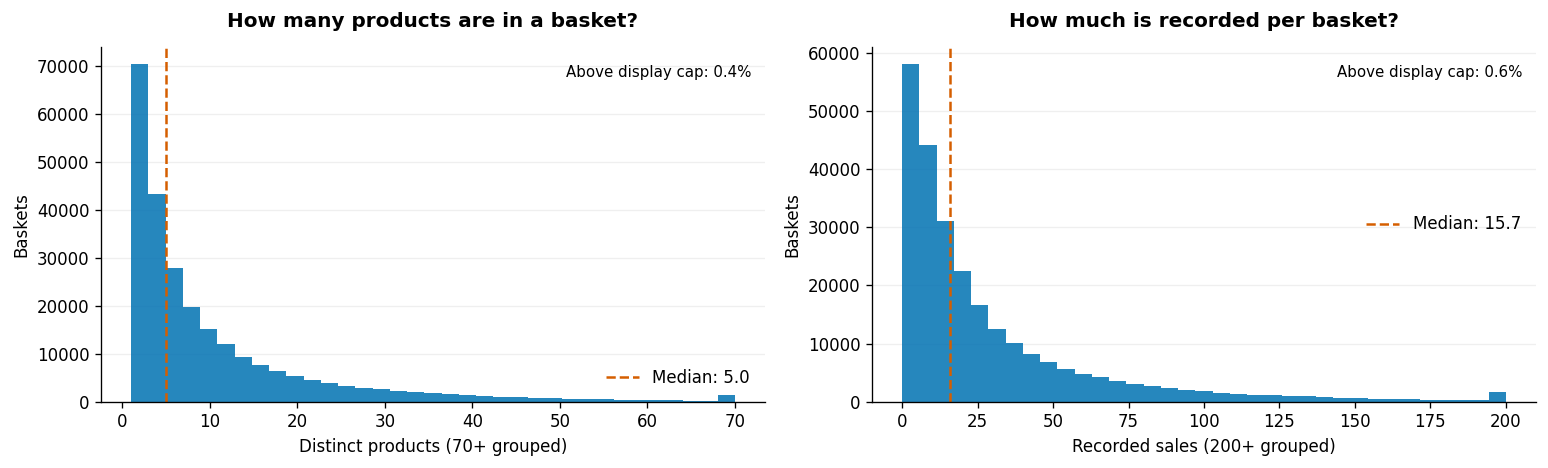

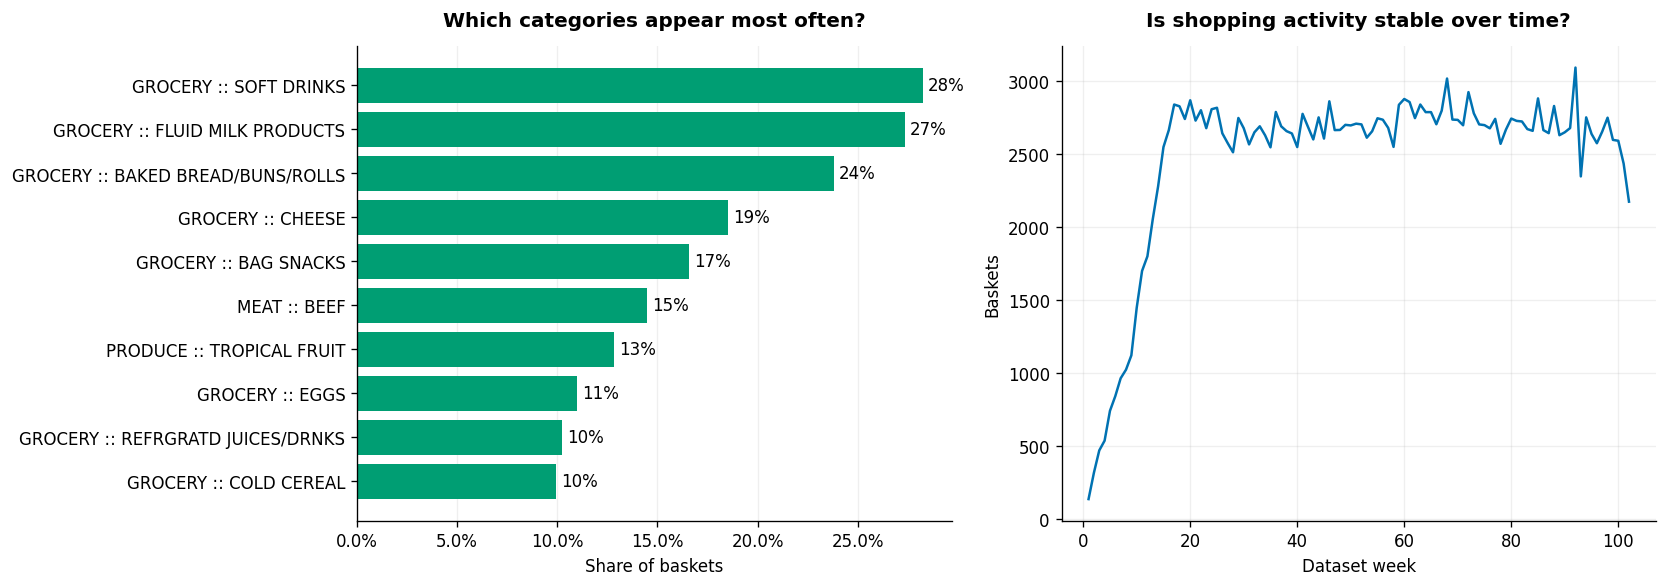

In [5]:
baskets = (
    items.group_by("household_key", "basket_id")
    .agg(
        pl.col("day").first().alias("day"),
        pl.col("week_no").first().alias("week_no"),
        pl.col("store_id").first().alias("store_id"),
        pl.col("product_id").n_unique().alias("n_skus"),
        pl.col("category_id").n_unique().alias("n_categories"),
        pl.col("brand").n_unique().alias("n_brands"),
        pl.col("sales_value").sum().alias("recorded_sales"),
        pl.col("sales_value")
        .clip(lower_bound=0)
        .sum()
        .alias("nonnegative_sales"),
    )
)

eda_summary = baskets.select(
    pl.len().alias("baskets"),
    pl.col("household_key").n_unique().alias("households"),
    pl.col("n_skus").median().alias("median_skus"),
    pl.col("n_skus").quantile(0.90).alias("p90_skus"),
    pl.col("n_skus").max().alias("max_skus"),
    pl.col("recorded_sales").median().alias("median_sales"),
    pl.col("recorded_sales").quantile(0.90).alias("p90_sales"),
    pl.col("recorded_sales").max().alias("max_sales"),
    pl.col("n_categories").median().alias("median_categories"),
    pl.col("n_brands").median().alias("median_brands"),
)
show(eda_summary, "Basket profile")

category_baskets = (
    items.select("basket_id", "category_id")
    .unique()
    .group_by("category_id")
    .agg(pl.len().alias("baskets"))
    .sort("baskets", "category_id", descending=[True, False])
    .with_columns(
        (pl.col("baskets") / max(baskets.height, 1)).alias("basket_share"),
        pl.col("category_id").cum_count().alias("category_rank"),
        pl.col("baskets").cum_sum().alias("cum_baskets"),
    )
    .with_columns(
        (
            pl.col("cum_baskets")
            / pl.col("baskets").sum()
        ).alias("cum_category_occurrence_share")
    )
)
show(
    category_baskets.head(20),
    "Top categories",
    pct_cols=("basket_share", "cum_category_occurrence_share"),
)

household_summary = (
    baskets.group_by("household_key")
    .agg(
        pl.len().alias("baskets"),
        pl.col("n_skus").mean().alias("avg_skus"),
        pl.col("n_categories").mean().alias("avg_categories"),
        pl.col("recorded_sales").mean().alias("avg_sales"),
    )
    .sort("baskets", descending=True)
)
show(household_summary.head(20), "Most active households")

profile = eda_summary.row(0, named=True)
kpi_cards([("Households", f"{profile['households']:,}", "Distinct shoppers in eligible data"),
           ("Shopping baskets", f"{profile['baskets']:,}", "Distinct shopping visits"),
           ("Typical basket size", f"{profile['median_skus']:.0f} products", "Median distinct products"),
           ("Typical basket value", f"{profile['median_sales']:.2f}", "Recorded sales, dataset units")])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, column, cap, title, label in [
    (axes[0], "n_skus", 70, "How many products are in a basket?", "Distinct products (70+ grouped)"),
    (axes[1], "recorded_sales", 200, "How much is recorded per basket?", "Recorded sales (200+ grouped)")]:
    values = baskets[column].to_numpy()
    values = values[np.isfinite(values)]
    ax.hist(np.minimum(values, cap), bins=35, color="#0072B2", alpha=0.85)
    ax.axvline(np.median(values), color="#D55E00", linestyle="--", label=f"Median: {np.median(values):.1f}")
    ax.set(title=title, xlabel=label, ylabel="Baskets"); ax.legend()
    ax.text(0.98, 0.95, f"Above display cap: {(values > cap).mean():.1%}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9)
    ax.grid(axis="y", alpha=0.2)
plt.tight_layout(); plt.show()
explain("The final histogram bin includes all larger values; no transactions are dropped by the display cap. "
        "Recorded sales are not gross margin.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top = category_baskets.head(10).sort("basket_share")
bars = axes[0].barh(top["category_id"].to_list(), top["basket_share"].to_list(), color="#009E73")
axes[0].bar_label(bars, labels=[f"{v:.0%}" for v in top["basket_share"]], padding=3)
axes[0].set(title="Which categories appear most often?", xlabel="Share of baskets")
axes[0].xaxis.set_major_formatter(PercentFormatter(1)); axes[0].grid(axis="x", alpha=0.2)
weekly_profile = baskets.group_by("week_no").agg(pl.len().alias("baskets")).sort("week_no")
axes[1].plot(weekly_profile["week_no"].to_numpy(), weekly_profile["baskets"].to_numpy(), color="#0072B2")
axes[1].set(title="Is shopping activity stable over time?", xlabel="Dataset week", ylabel="Baskets")
axes[1].grid(alpha=0.2)
plt.tight_layout(); plt.show()
explain("Category shares can sum above 100% because one basket can contain several categories. "
        "This full-log view is descriptive; model statistics below use past-only snapshots.")


## 3. Time and target definition

**Question:** what information was available when recommending for this visit?

The split cutoffs freeze population statistics, product popularity, prices, co-purchase rules and peer signals. Within each window, household novelty status and the preceding shopping day update using only days strictly before the target day. This is a rolling next-visit simulation with periodically refreshed global statistics, not a single forecast made at the split cutoff.

- Training targets occur after `FIT_CUTOFF` and through `VALID_CUTOFF`.
- Validation targets occur after `VALID_CUTOFF` and through `TEST_CUTOFF`.
- Held-out targets occur after `TEST_CUTOFF`.
- The target visit day is assumed known; this notebook does not predict when the next visit will happen.
- Novelty is **day-level**. Multiple baskets on a household's first purchase day can all contain first-time products. No within-day event ordering is assumed.
- “First-time” means first observed in this dataset, not necessarily first purchased in the shopper's lifetime.

Full-history first-observation dates are used only for labels and past-status comparisons. Future dates do not enter predictive numeric features. All other features are explicitly allowlisted.

The `history_baskets` feature counts preceding distinct shopping days, not necessarily individual baskets; its name is retained for compatibility with the original pipeline.

**Chronological evaluation windows**

,split,target_baskets,day_start,day_end
0,train,5000,301,497
1,validation,2500,498,604
2,test,2500,605,711


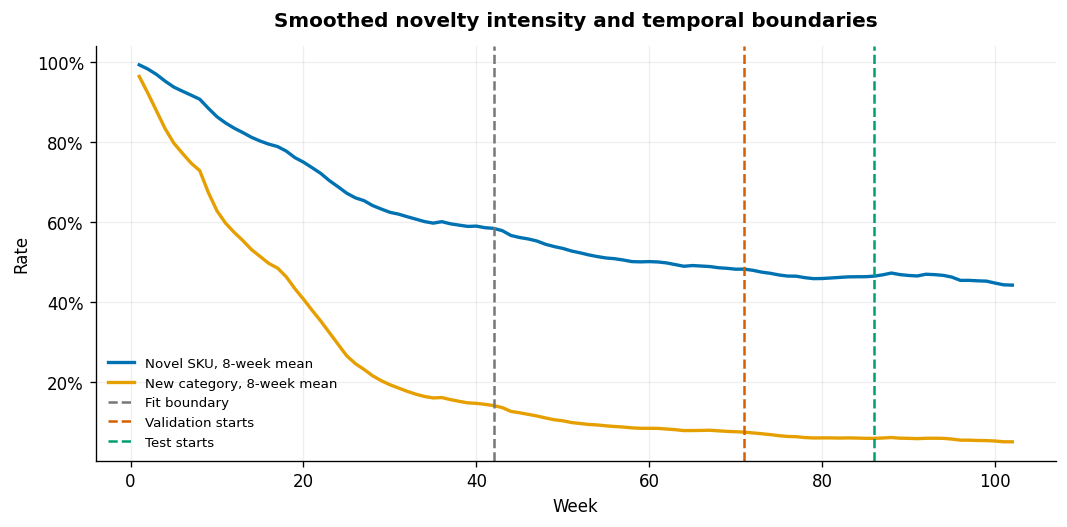

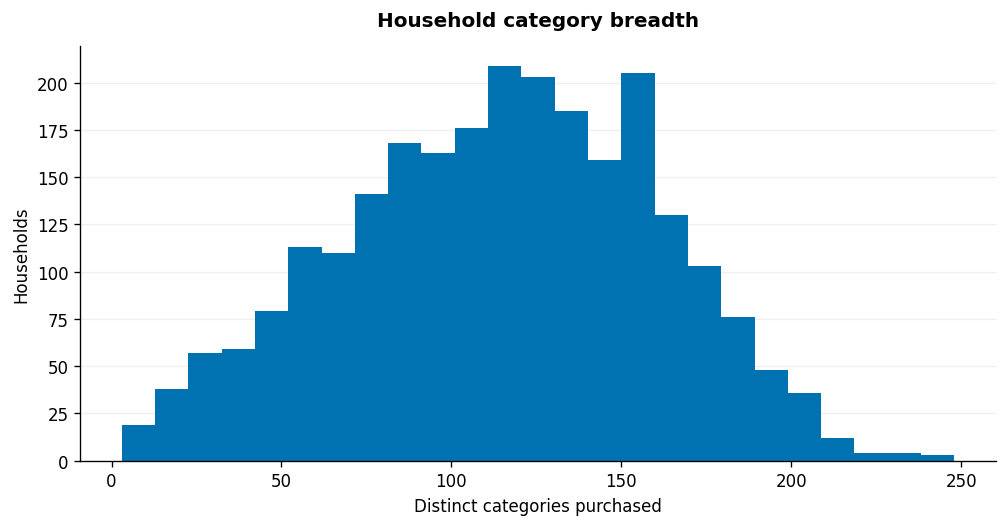

Novelty is defined at the household × SKU level: a target SKU is novel when its `first_item_day` equals the target basket day. New-category status is defined analogously.

In [6]:
shopping_days = (
    baskets.select("household_key", "day")
    .unique()
    .sort("household_key", "day")
    .with_columns(
        pl.col("day").shift(1).over("household_key").alias("previous_day"),
        pl.col("day").cum_count().over("household_key").alias("shopping_sequence"),
    )
)

contexts = (
    baskets.join(
        shopping_days,
        on=["household_key", "day"],
        how="left",
    )
    .filter(pl.col("previous_day").is_not_null())
    .select(
        "household_key",
        pl.col("basket_id").alias("target_basket_id"),
        pl.col("day").alias("target_day"),
        "previous_day",
        "shopping_sequence",
        "n_skus",
        "n_categories",
        "recorded_sales",
    )
    .with_columns(
        (pl.col("target_day") - pl.col("previous_day")).alias("days_since_previous"),
        (pl.col("shopping_sequence") - 1).alias("history_baskets"),
        (pl.col("target_day") % 7).cast(pl.Int8).alias("weekday"),
    )
)

def pick_contexts(frame, low, high, budget):
    x = frame.filter(
        (pl.col("target_day") > low) & (pl.col("target_day") <= high)
    )
    return x.sample(
        n=min(x.height, budget),
        seed=SEED,
        shuffle=True,
    )

train_ctx = pick_contexts(contexts, FIT_CUTOFF, VALID_CUTOFF, MAX_TRAIN_BASKETS)
valid_ctx = pick_contexts(contexts, VALID_CUTOFF, TEST_CUTOFF, MAX_VALID_BASKETS)
test_ctx = pick_contexts(
    contexts,
    TEST_CUTOFF,
    int(baskets["day"].max()),
    MAX_TEST_BASKETS,
)

for split_name, ctx, cutoff in [("train", train_ctx, FIT_CUTOFF),
                                ("validation", valid_ctx, VALID_CUTOFF),
                                ("test", test_ctx, TEST_CUTOFF)]:
    assert ctx.height > 0, f"No {split_name} contexts. Adjust cutoffs to the data range."
    assert ctx["target_day"].min() > cutoff
    assert ctx.filter(pl.col("previous_day") >= pl.col("target_day")).height == 0
    assert ctx["target_basket_id"].n_unique() == ctx.height

# Stable first-observation dates. These are used only through boolean comparison
# against target_day when determining "new as of this target".
first_item_day = (
    items.group_by("household_key", "product_id")
    .agg(pl.col("day").min().alias("first_item_day"))
)

first_cat_day = (
    items.group_by("household_key", "category_id")
    .agg(pl.col("day").min().alias("first_cat_day"))
)

split_table = pl.DataFrame({
    "split": ["train", "validation", "test"],
    "target_baskets": [train_ctx.height, valid_ctx.height, test_ctx.height],
    "day_start": [
        train_ctx["target_day"].min(),
        valid_ctx["target_day"].min(),
        test_ctx["target_day"].min(),
    ],
    "day_end": [
        train_ctx["target_day"].max(),
        valid_ctx["target_day"].max(),
        test_ctx["target_day"].max(),
    ],
})
show(split_table, "Chronological evaluation windows")

# EDA — first-time purchase opportunity over time
# Novel-SKU opportunity rate over time (descriptive EDA, uses full log only here)
novel_flags = (
    items
    .with_columns(
        pl.col("day").min().over(["household_key", "product_id"]).alias("_first_day"),
        pl.col("day").min().over(["household_key", "category_id"]).alias("_first_cat_day"),
    )
    .with_columns(
        (pl.col("_first_day") == pl.col("day")).cast(pl.Int8).alias("novel_sku"),
        (pl.col("_first_cat_day") == pl.col("day")).cast(pl.Int8).alias("novel_category"),
    )
)

novel_weekly = (
    novel_flags.group_by("week_no")
    .agg(
        pl.len().alias("positive_lines"),
        pl.col("novel_sku").sum().alias("novel_sku_lines"),
        pl.col("novel_category").sum().alias("new_category_lines"),
    )
    .sort("week_no")
    .with_columns(
        (pl.col("novel_sku_lines") / pl.col("positive_lines").clip(lower_bound=1)).alias("novel_sku_rate"),
        (pl.col("new_category_lines") / pl.col("positive_lines").clip(lower_bound=1)).alias("new_category_rate"),
    )
)

# Visual — rolling novelty intensity by dataset period
novel_plot = novel_weekly.to_pandas().sort_values("week_no")
if len(novel_plot):
    for col in ["novel_sku_rate", "new_category_rate"]:
        novel_plot[f"{col}_rolling"] = novel_plot[col].rolling(8, min_periods=1).mean()
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(novel_plot["week_no"], novel_plot["novel_sku_rate_rolling"], label="Novel SKU, 8-week mean", linewidth=2)
    ax.plot(novel_plot["week_no"], novel_plot["new_category_rate_rolling"], label="New category, 8-week mean", linewidth=2)
    ax.axvline(FIT_CUTOFF // 7, color="#777777", linestyle="--", label="Fit boundary")
    ax.axvline(VALID_CUTOFF // 7, color="#D55E00", linestyle="--", label="Validation starts")
    ax.axvline(TEST_CUTOFF // 7, color="#009E73", linestyle="--", label="Test starts")
    ax.set(title="Smoothed novelty intensity and temporal boundaries", xlabel="Week", ylabel="Rate")
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

# Category diversity per household
hh_diversity = (
    items.select("household_key", "basket_id", "category_id").unique()
    .group_by("household_key")
    .agg(
        pl.col("category_id").n_unique().alias("distinct_categories"),
        pl.col("basket_id").n_unique().alias("baskets"),
    )
)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.hist(hh_diversity["distinct_categories"].to_numpy(), bins=25)
ax.set_title("Household category breadth")
ax.set_xlabel("Distinct categories purchased")
ax.set_ylabel("Households")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

display(Markdown(
    "Novelty is defined at the household × SKU level: a target SKU is novel when its "
    "`first_item_day` equals the target basket day. New-category status is defined analogously."
))


### Freeze population statistics

Build one snapshot for each split. Popularity, household aggregate preferences, historical value proxies and category associations use transactions no later than that split's cutoff. These snapshots can age within a window; daily household novelty filtering remains current.

In [7]:
def build_snapshot(cutoff):
    history = items.filter(pl.col("day") <= cutoff)
    total_baskets = history["basket_id"].n_unique()

    # Global category popularity
    cat = (
        history.select("basket_id", "category_id").unique()
        .group_by("category_id")
        .agg(pl.len().alias("category_baskets"))
        .with_columns(
            (pl.col("category_baskets") / max(total_baskets, 1)).alias("category_share")
        )
        .sort("category_baskets", "category_id", descending=[True, False])
        .with_columns(
            pl.col("category_id").cum_count().alias("global_category_rank")
        )
    )

    # SKU statistics with recency and category-relative value.
    sku = (
        history.group_by("category_id", "product_id")
        .agg(
            pl.col("basket_id").n_unique().alias("sku_baskets"),
            pl.col("quantity").sum().alias("sku_units"),
            pl.col("sales_value").sum().alias("sku_recorded_sales"),
            pl.col("day").max().alias("sku_last_day"),
            pl.col("day").n_unique().alias("sku_active_days"),
        )
        .with_columns(
            (
                pl.col("sku_recorded_sales").clip(lower_bound=0)
                / pl.col("sku_units").clip(lower_bound=1)
            ).alias("recorded_unit_value")
        )
        .join(
            cat.select("category_id", "category_baskets"),
            on="category_id",
            how="left",
        )
        .with_columns(
            (
                pl.col("sku_baskets")
                / pl.col("category_baskets").clip(lower_bound=1)
            ).alias("sku_category_share"),
            (pl.lit(cutoff) - pl.col("sku_last_day")).cast(pl.Float64).alias("sku_recency_days"),
            (pl.col("sku_last_day") >= cutoff - 60).cast(pl.Int8).alias("sku_recent_flag"),
        )
    )

    cat_value = (
        sku.group_by("category_id")
        .agg(
            pl.col("recorded_unit_value").median().alias("category_median_unit_value")
        )
    )

    sku = (
        sku.join(cat_value, on="category_id", how="left")
        .with_columns(
            (
                pl.col("recorded_unit_value")
                / pl.col("category_median_unit_value").clip(lower_bound=0.01)
            ).clip(lower_bound=0, upper_bound=10).alias("category_relative_unit_value"),
            (
                pl.col("sku_baskets").cast(pl.Float64).log1p()
                * (-pl.col("sku_recency_days") / 90).exp()
            ).alias("time_decayed_sku_popularity"),
        )
        .sort(
            "category_id",
            "sku_baskets",
            "product_id",
            descending=[False, True, False],
        )
        .with_columns(
            pl.col("product_id").cum_count().over("category_id").alias("sku_pop_rank")
        )
        .sort(
            "category_id",
            "recorded_unit_value",
            "product_id",
            descending=[False, True, False],
        )
        .with_columns(
            pl.col("product_id").cum_count().over("category_id").alias("sku_value_rank")
        )
    )

    # Household × category affinity, including recency.
    hhcat = (
        history.select("household_key", "basket_id", "category_id", "day").unique()
        .group_by("household_key", "category_id")
        .agg(
            pl.len().alias("hh_category_baskets"),
            pl.col("day").max().alias("hh_category_last_day"),
        )
    )

    hh_baskets = (
        history.group_by("household_key")
        .agg(
            pl.col("basket_id").n_unique().alias("hh_total_baskets"),
            pl.col("sales_value").clip(lower_bound=0).sum().alias("hh_recorded_sales"),
        )
    )

    hhcat = (
        hhcat.join(hh_baskets, on="household_key", how="left")
        .with_columns(
            (
                pl.col("hh_category_baskets")
                / pl.col("hh_total_baskets").clip(lower_bound=1)
            ).alias("hh_category_share"),
            (pl.lit(cutoff) - pl.col("hh_category_last_day")).cast(pl.Float64).alias("hh_category_recency_days"),
        )
    )

    # Household × brand affinity
    hhbrand = (
        history.select("household_key", "basket_id", "brand", "day")
        .filter(pl.col("brand").is_not_null() & (pl.col("brand") != ""))
        .unique()
        .group_by("household_key", "brand")
        .agg(
            pl.len().alias("hh_brand_baskets"),
            pl.col("day").max().alias("hh_brand_last_day"),
        )
        .with_columns(
            (pl.lit(cutoff) - pl.col("hh_brand_last_day")).cast(pl.Float64).alias("hh_brand_recency_days")
        )
    )

    # Category × weekday rate
    cat_weekday = (
        history.select(
            "basket_id",
            "category_id",
            (pl.col("day") % 7).cast(pl.Int8).alias("weekday"),
        ).unique()
        .group_by("category_id", "weekday")
        .agg(pl.len().alias("cat_weekday_baskets"))
        .join(cat.select("category_id", "category_baskets"), on="category_id", how="left")
        .with_columns(
            (
                pl.col("cat_weekday_baskets")
                / pl.col("category_baskets").clip(lower_bound=1)
            ).alias("category_weekday_rate")
        )
    )

    # Category-pair complement evidence
    bc = history.select("basket_id", "category_id").unique()

    cat_pairs = (
        bc.join(bc, on="basket_id", suffix="_b")
        .filter(pl.col("category_id") < pl.col("category_id_b"))
        .group_by("category_id", "category_id_b")
        .agg(pl.len().alias("pair_baskets"))
        .filter(pl.col("pair_baskets") >= MIN_PAIR_SUPPORT)
        .join(
            cat.select(
                pl.col("category_id").alias("category_id"),
                pl.col("category_baskets").alias("anchor_baskets"),
            ),
            on="category_id",
            how="left",
        )
        .join(
            cat.select(
                pl.col("category_id").alias("category_id_b"),
                pl.col("category_baskets").alias("candidate_baskets"),
            ),
            on="category_id_b",
            how="left",
        )
        .with_columns(
            (
                (pl.col("pair_baskets") + PAIR_ALPHA)
                / (pl.col("anchor_baskets") + 2 * PAIR_ALPHA)
            ).alias("confidence"),
            (
                (
                    (pl.col("pair_baskets") + PAIR_ALPHA)
                    / (total_baskets + 2 * PAIR_ALPHA)
                )
                /
                (
                    (
                        (pl.col("anchor_baskets") + PAIR_ALPHA)
                        / (total_baskets + 2 * PAIR_ALPHA)
                    )
                    *
                    (
                        (pl.col("candidate_baskets") + PAIR_ALPHA)
                        / (total_baskets + 2 * PAIR_ALPHA)
                    )
                )
            ).alias("lift"),
        )
        .with_columns(
            pl.col("lift").clip(lower_bound=1e-6).log().alias("log_lift"),
            (
                pl.col("pair_baskets")
                / (
                    pl.col("anchor_baskets")
                    + pl.col("candidate_baskets")
                    - pl.col("pair_baskets")
                ).clip(lower_bound=1)
            ).alias("jaccard"),
        )
    )

    pair = pl.concat(
        [
            cat_pairs.select(
                pl.col("category_id").alias("anchor_category"),
                pl.col("category_id_b").alias("candidate_category"),
                "pair_baskets", "confidence", "lift", "log_lift", "jaccard",
            ),
            cat_pairs.select(
                pl.col("category_id_b").alias("anchor_category"),
                pl.col("category_id").alias("candidate_category"),
                "pair_baskets",
                (
                    (pl.col("pair_baskets") + PAIR_ALPHA)
                    / (pl.col("candidate_baskets") + 2 * PAIR_ALPHA)
                ).alias("confidence"),
                "lift", "log_lift", "jaccard",
            ),
        ],
        how="vertical",
    )

    return {
        "cutoff": cutoff,
        "total_baskets": total_baskets,
        "category": cat,
        "sku": sku,
        "hhcat": hhcat,
        "hhbrand": hhbrand,
        "cat_weekday": cat_weekday,
        "pair": pair,
    }


In [8]:
snap_train = build_snapshot(FIT_CUTOFF)
snap_valid = build_snapshot(VALID_CUTOFF)
snap_test = build_snapshot(TEST_CUTOFF)

show(
    pl.DataFrame({
        "cutoff": [s["cutoff"] for s in (snap_train, snap_valid, snap_test)],
        "categories": [s["category"].height for s in (snap_train, snap_valid, snap_test)],
        "skus": [s["sku"].height for s in (snap_train, snap_valid, snap_test)],
        "pair_rules": [s["pair"].height for s in (snap_train, snap_valid, snap_test)],
    }),
    "Snapshot sizes",
)


**Snapshot sizes**

,cutoff,categories,skus,pair_rules
0,300,326,58242,41778
1,497,336,75754,49850
2,604,342,84019,52414


## 4. Find candidate products

**Question:** can the engine surface future first purchases before any model ranks them?

| Retrieval channel | Plain-language purpose |
|---|---|
| New category | Discover popular categories the household has not previously bought |
| Known category | Explore an unpurchased product in a familiar category |
| Basket complement | Find categories historically bought with the preceding shopping day's basket |
| Similar shoppers | Find products supported by households with similar category histories |

Channels overlap; candidate rows are deduplicated. Both category and peer candidates exclude every product purchased on an earlier day. Historical prices are recorded-value proxies, not live price, inventory or margin signals.

In [9]:
def build_peer_products(snapshot):
    hhcat = snapshot["hhcat"].select(
        "household_key", "category_id", "hh_category_baskets"
    )

    households = hhcat["household_key"].unique().sort().to_list()
    categories = hhcat["category_id"].unique().sort().to_list()

    if len(households) < 2 or len(categories) == 0:
        return pl.DataFrame(schema={
            "household_key": snapshot["hhcat"].schema["household_key"],
            "product_id": snapshot["sku"].schema["product_id"],
            "peer_score": pl.Float64,
            "peer_max_similarity": pl.Float64,
            "supporting_peer_households": pl.UInt32,
        })

    hh_index = {h: i for i, h in enumerate(households)}
    cat_index = {c: i for i, c in enumerate(categories)}

    row = np.array([hh_index[h] for h in hhcat["household_key"].to_list()], dtype=np.int32)
    col = np.array([cat_index[c] for c in hhcat["category_id"].to_list()], dtype=np.int32)
    data = hhcat["hh_category_baskets"].cast(pl.Float32).to_numpy()

    from scipy.sparse import csr_matrix

    X = csr_matrix(
        (data, (row, col)),
        shape=(len(households), len(categories)),
        dtype=np.float32,
    )

    n_neighbors = min(PEER_NEIGHBORS + 1, len(households))

    nn = NearestNeighbors(
        n_neighbors=n_neighbors,
        metric="cosine",
        algorithm="brute",
    )
    nn.fit(X)

    distances, indices = nn.kneighbors(X)

    hh_array = np.asarray(households)
    peer = pl.DataFrame({
        "household_key": np.repeat(hh_array, indices.shape[1]),
        "peer_household": hh_array[indices.ravel()],
        "similarity": (1.0 - distances.ravel()).astype("float32"),
    }).filter(
        (pl.col("household_key") != pl.col("peer_household"))
        & (pl.col("similarity") > 0)
    )

    history = items.filter(pl.col("day") <= snapshot["cutoff"])

    peer_skus = (
        history.group_by("household_key", "product_id")
        .agg(
            pl.col("basket_id").n_unique().alias("peer_sku_baskets"),
            pl.col("day").max().alias("peer_sku_last_day"),
        )
        .sort(
            "household_key",
            "peer_sku_baskets",
            "product_id",
            descending=[False, True, False],
        )
        .with_columns(
            pl.col("product_id").cum_count().over("household_key").alias("peer_sku_rank")
        )
        .filter(pl.col("peer_sku_rank") <= PEER_SKUS_PER_HOUSEHOLD)
    )

    peer_products = (
        peer.rename({"household_key": "target_household"})
        .join(
            peer_skus.rename({"household_key": "peer_household"}),
            on="peer_household",
            how="inner",
        )
        .with_columns(
            (
                pl.col("similarity")
                * (1 + pl.col("peer_sku_baskets").cast(pl.Float64)).log()
            ).alias("peer_score")
        )
        .group_by("target_household", "product_id")
        .agg(
            pl.col("peer_score").sum().alias("peer_score"),
            pl.col("similarity").max().alias("peer_max_similarity"),
            pl.col("peer_household").n_unique().alias("supporting_peer_households"),
        )
        .sort(
            "target_household",
            "peer_score",
            "product_id",
            descending=[False, True, False],
        )
        .with_columns(
            pl.col("product_id").cum_count().over("target_household").alias("peer_rank")
        )
        .filter(pl.col("peer_rank") <= PEER_SKUS_PER_HOUSEHOLD)
        .rename({"target_household": "household_key"})
        .select(
            "household_key",
            "product_id",
            "peer_score",
            "peer_max_similarity",
            "supporting_peer_households",
        )
    )

    return peer_products


In [10]:
peer_train = build_peer_products(snap_train)
peer_valid = build_peer_products(snap_valid)
peer_test = build_peer_products(snap_test)

show(
    pl.DataFrame({
        "split": ["train", "validation", "test"],
        "peer_rows": [peer_train.height, peer_valid.height, peer_test.height],
        "households": [
            peer_train["household_key"].n_unique() if peer_train.height else 0,
            peer_valid["household_key"].n_unique() if peer_valid.height else 0,
            peer_test["household_key"].n_unique() if peer_test.height else 0,
        ],
    }),
    "Peer discovery channel",
)


**Peer discovery channel**

,split,peer_rows,households
0,train,124607,2495
1,validation,124850,2497
2,test,124850,2497


### Combine the retrieval channels

Category nominations identify where to explore. Product expansion selects historical popular/value products in those categories, merges the peer channel, then applies one bounded candidate budget per basket. A stable product-ID tie break makes capped candidate selection reproducible.

In [11]:
CANDIDATE_DTYPES = {
    "channel_category": pl.Int8,
    "channel_peer": pl.Int8,
    "channel_discovery": pl.Int8,
    "channel_familiar": pl.Int8,
    "channel_complement": pl.Int8,
    "discovery_rank": pl.Int64,
    "familiar_rank": pl.Int64,
    "complement_rank": pl.Int64,
    "complement_max_log_lift": pl.Float64,
    "complement_confidence": pl.Float64,
    "complement_jaccard": pl.Float64,
    "complement_score": pl.Float64,
    "n_supporting_anchors": pl.Int64,
    "peer_score": pl.Float64,
    "peer_max_similarity": pl.Float64,
    "supporting_peer_households": pl.Int64,
    "sku_baskets": pl.Int64,
    "sku_category_share": pl.Float64,
    "recorded_unit_value": pl.Float64,
    "category_relative_unit_value": pl.Float64,
    "time_decayed_sku_popularity": pl.Float64,
    "sku_pop_rank": pl.Int64,
    "sku_value_rank": pl.Int64,
    "sku_recent_flag": pl.Int8,
}

CANDIDATE_COLUMNS = [
    "target_basket_id",
    "product_id",
    "category_id",
    *CANDIDATE_DTYPES,
]


def _normalize_candidate_schema(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns(
        *[
            pl.col(c).cast(dtype, strict=False).alias(c)
            for c, dtype in CANDIDATE_DTYPES.items()
        ]
    )


def nominate_categories(ctx, snapshot):
    part = ctx.select(
        "target_basket_id",
        "household_key",
        "target_day",
        "weekday",
    )

    # A. Global new-category discovery
    new_cats = (
        part.join(snapshot["category"], how="cross")
        .join(first_cat_day, on=["household_key", "category_id"], how="left")
        .filter(
            pl.col("first_cat_day").is_null()
            | (pl.col("first_cat_day") >= pl.col("target_day"))
        )
        .sort("target_basket_id", "global_category_rank")
        .with_columns(
            pl.col("category_id")
            .cum_count()
            .over("target_basket_id")
            .alias("discovery_rank")
        )
        .filter(pl.col("discovery_rank") <= NEW_CATEGORY_K)
        .select("target_basket_id", "category_id", "discovery_rank")
        .unique()
    )

    # B. Familiar-category exploration
    fam_snapshot = (
        part.select("target_basket_id", "household_key")
        .join(
            snapshot["hhcat"].select(
                "household_key",
                "category_id",
                "hh_category_baskets",
            ),
            on="household_key",
            how="inner",
        )
        .select(
            "target_basket_id",
            "category_id",
            pl.col("hh_category_baskets")
            .cast(pl.Int64)
            .alias("hh_category_baskets"),
        )
    )

    # Retain the target basket ID so familiarity is evaluated per context.
    fam_dynamic = (
        part.select("target_basket_id", "household_key", "target_day")
        .join(first_cat_day, on="household_key", how="inner")
        .filter(pl.col("first_cat_day") < pl.col("target_day"))
        .select(
            "target_basket_id",
            "category_id",
        )
        .with_columns(
            pl.lit(1).cast(pl.Int64).alias("hh_category_baskets")
        )
    )

    fam_base = (
        pl.concat([fam_snapshot, fam_dynamic], how="vertical")
        .group_by("target_basket_id", "category_id")
        .agg(pl.col("hh_category_baskets").max())
        .join(
            snapshot["category"].select(
                "category_id",
                "global_category_rank",
            ),
            on="category_id",
            how="left",
        )
        .sort(
            "target_basket_id",
            "hh_category_baskets",
            "global_category_rank",
            "category_id",
            descending=[False, True, False, False],
        )
        .with_columns(
            pl.col("category_id")
            .cum_count()
            .over("target_basket_id")
            .alias("familiar_rank")
        )
        .filter(pl.col("familiar_rank") <= FAMILIAR_CATEGORY_K)
    )

    familiar = fam_base.select(
        "target_basket_id",
        "category_id",
        "familiar_rank",
    )

    # C. Complement categories from the immediately prior shopping day
    anchors = (
        ctx.select("target_basket_id", "household_key", "previous_day")
        .join(
            items.select(
                "household_key",
                pl.col("day").alias("previous_day"),
                "category_id",
            ).unique(),
            on=["household_key", "previous_day"],
            how="inner",
        )
        .select("target_basket_id", "category_id")
        .rename({"category_id": "anchor_category"})
        .unique()
    )

    complement = (
        anchors.join(snapshot["pair"], on="anchor_category", how="inner")
        .filter(pl.col("candidate_category") != pl.col("anchor_category"))
        .group_by("target_basket_id", "candidate_category")
        .agg(
            pl.col("log_lift")
            .filter(pl.col("log_lift") > 0)
            .max()
            .fill_null(0)
            .alias("complement_max_log_lift"),
            pl.col("confidence")
            .max()
            .fill_null(0)
            .alias("complement_confidence"),
            pl.col("jaccard")
            .max()
            .fill_null(0)
            .alias("complement_jaccard"),
            pl.col("candidate_category")
            .count()
            .alias("n_supporting_anchors"),
            (
                (
                    pl.col("log_lift").clip(lower_bound=0) + 1
                )
                * pl.col("confidence")
            )
            .sum()
            .alias("complement_score"),
        )
        .sort(
            "target_basket_id",
            "complement_score",
            "candidate_category",
            descending=[False, True, False],
        )
        .with_columns(
            pl.col("candidate_category")
            .cum_count()
            .over("target_basket_id")
            .alias("complement_rank")
        )
        .filter(pl.col("complement_rank") <= COMPLEMENT_CATEGORY_K)
        .rename({"candidate_category": "category_id"})
    )

    cats = pl.concat(
        [
            new_cats.with_columns(
                pl.lit(1).cast(pl.Int8).alias("channel_discovery")
            ),
            familiar.with_columns(
                pl.lit(1).cast(pl.Int8).alias("channel_familiar")
            ),
            complement.select(
                "target_basket_id",
                "category_id",
                "complement_rank",
                "complement_max_log_lift",
                "complement_confidence",
                "complement_jaccard",
                "complement_score",
                "n_supporting_anchors",
            ).with_columns(
                pl.lit(1).cast(pl.Int8).alias("channel_complement")
            ),
        ],
        how="diagonal_relaxed",
    )

    cat_fill = [
        "channel_discovery",
        "channel_familiar",
        "channel_complement",
        "complement_max_log_lift",
        "complement_confidence",
        "complement_jaccard",
        "complement_score",
        "n_supporting_anchors",
    ]
    cats = cats.with_columns(
        *[pl.col(c).fill_null(0) for c in cat_fill]
    )

    return cats.group_by("target_basket_id", "category_id").agg(
        *[
            pl.col(c).max().alias(c)
            for c in cats.columns
            if c not in ("target_basket_id", "category_id")
        ]
    )


In [12]:
def category_sku_candidates(ctx, cats, snapshot):
    sku = snapshot["sku"].filter(
        (pl.col("sku_pop_rank") <= POPULAR_SKUS_PER_CATEGORY)
        | (pl.col("sku_value_rank") <= VALUE_SKUS_PER_CATEGORY)
    )

    return (
        cats.join(
            ctx.select(
                "target_basket_id",
                "household_key",
                "target_day",
            ),
            on="target_basket_id",
            how="left",
        )
        .join(
            sku.select(
                "category_id",
                "product_id",
                "sku_baskets",
                "sku_category_share",
                "recorded_unit_value",
                "category_relative_unit_value",
                "time_decayed_sku_popularity",
                "sku_pop_rank",
                "sku_value_rank",
                "sku_recent_flag",
            ),
            on="category_id",
            how="inner",
        )
        .join(
            first_item_day,
            on=["household_key", "product_id"],
            how="left",
        )
        .filter(
            pl.col("first_item_day").is_null()
            | (pl.col("first_item_day") >= pl.col("target_day"))
        )
    )


def peer_candidates(ctx, peer_products, snapshot):
    # Use the same join path even when peer_products is empty. This preserves
    # the actual product/category key dtypes for the later concatenation.
    return (
        ctx.select("target_basket_id", "household_key", "target_day")
        .join(peer_products, on="household_key", how="inner")
        .join(
            snapshot["sku"].select(
                "product_id",
                "category_id",
                "sku_baskets",
                "sku_category_share",
                "recorded_unit_value",
                "category_relative_unit_value",
                "time_decayed_sku_popularity",
                "sku_pop_rank",
                "sku_value_rank",
                "sku_recent_flag",
            ),
            on="product_id",
            how="left",
        )
        .join(
            first_item_day,
            on=["household_key", "product_id"],
            how="left",
        )
        .filter(
            pl.col("first_item_day").is_null()
            | (pl.col("first_item_day") >= pl.col("target_day"))
        )
        .with_columns(
            pl.lit(1).cast(pl.Int8).alias("channel_peer")
        )
        .select(
            "target_basket_id",
            "product_id",
            "category_id",
            "peer_score",
            "peer_max_similarity",
            "supporting_peer_households",
            "channel_peer",
            "sku_baskets",
            "sku_category_share",
            "recorded_unit_value",
            "category_relative_unit_value",
            "time_decayed_sku_popularity",
            "sku_pop_rank",
            "sku_value_rank",
            "sku_recent_flag",
        )
    )


def assemble_candidates(ctx, cats, peer_products, snapshot):
    common = ["target_basket_id", "product_id", "category_id"]

    cc = (
        category_sku_candidates(ctx, cats, snapshot)
        .with_columns(
            pl.lit(1).cast(pl.Int8).alias("channel_category"),
            pl.lit(0).cast(pl.Int8).alias("channel_peer"),
            pl.col("channel_discovery").fill_null(0).cast(pl.Int8),
            pl.col("channel_familiar").fill_null(0).cast(pl.Int8),
            pl.col("channel_complement").fill_null(0).cast(pl.Int8),
            pl.col("n_supporting_anchors").fill_null(0).cast(pl.Int64),
            pl.lit(None).cast(pl.Float64).alias("peer_score"),
            pl.lit(None).cast(pl.Float64).alias("peer_max_similarity"),
            pl.lit(None)
            .cast(pl.Int64)
            .alias("supporting_peer_households"),
        )
        .select(*CANDIDATE_COLUMNS)
    )

    pc = (
        peer_candidates(ctx, peer_products, snapshot)
        .with_columns(
            pl.lit(0).cast(pl.Int8).alias("channel_category"),
            pl.lit(0).cast(pl.Int8).alias("channel_discovery"),
            pl.lit(0).cast(pl.Int8).alias("channel_familiar"),
            pl.lit(0).cast(pl.Int8).alias("channel_complement"),
            pl.lit(None).cast(pl.Int64).alias("discovery_rank"),
            pl.lit(None).cast(pl.Int64).alias("familiar_rank"),
            pl.lit(None).cast(pl.Int64).alias("complement_rank"),
            pl.lit(0.0)
            .cast(pl.Float64)
            .alias("complement_max_log_lift"),
            pl.lit(0.0)
            .cast(pl.Float64)
            .alias("complement_confidence"),
            pl.lit(0.0)
            .cast(pl.Float64)
            .alias("complement_jaccard"),
            pl.lit(0.0)
            .cast(pl.Float64)
            .alias("complement_score"),
            pl.lit(0).cast(pl.Int64).alias("n_supporting_anchors"),
        )
        .select(*CANDIDATE_COLUMNS)
    )

    cc = _normalize_candidate_schema(cc)
    pc = _normalize_candidate_schema(pc)

    unioned = pl.concat(
        [cc, pc],
        how="diagonal_relaxed",
        rechunk=False,
    )

    out = (
        unioned.group_by(common)
        .agg(
            *[
                pl.col(c).max().alias(c)
                for c in CANDIDATE_DTYPES
            ]
        )
        .with_columns(
            pl.sum_horizontal(
                "channel_category",
                "channel_peer",
                "channel_discovery",
                "channel_familiar",
                "channel_complement",
            )
            .cast(pl.Int8)
            .alias("n_retrieval_channels"),
            (
                pl.col("channel_category").cast(pl.Int8)
                + pl.col("channel_peer").cast(pl.Int8)
            )
            .cast(pl.Int8)
            .alias("n_source_families"),
        )
        .sort(
            "target_basket_id",
            "n_retrieval_channels",
            "complement_score",
            "peer_score",
            "sku_baskets",
            "product_id",
            descending=[False, True, True, True, True, False],
        )
        .with_columns(
            pl.col("product_id")
            .cum_count()
            .over("target_basket_id")
            .alias("retrieval_rank")
        )
        .filter(
            pl.col("retrieval_rank") <= RETRIEVAL_CAP_PER_BASKET
        )
    )
    return out


In [13]:
train_cats = nominate_categories(train_ctx, snap_train)
valid_cats = nominate_categories(valid_ctx, snap_valid)
test_cats = nominate_categories(test_ctx, snap_test)

train_retrieved = assemble_candidates(
    train_ctx, train_cats, peer_train, snap_train
)
valid_retrieved = assemble_candidates(
    valid_ctx, valid_cats, peer_valid, snap_valid
)
test_retrieved = assemble_candidates(
    test_ctx, test_cats, peer_test, snap_test
)

show(
    pl.DataFrame({
        "split": ["train", "validation", "test"],
        "candidates": [
            train_retrieved.height,
            valid_retrieved.height,
            test_retrieved.height,
        ],
        "median_per_basket": [
            train_retrieved
            .group_by("target_basket_id")
            .len()["len"]
            .median(),
            valid_retrieved
            .group_by("target_basket_id")
            .len()["len"]
            .median(),
            test_retrieved
            .group_by("target_basket_id")
            .len()["len"]
            .median(),
        ],
    }),
    "Retrieved candidates",
)


**Retrieved candidates**

,split,candidates,median_per_basket
0,train,2638000,528.000000
1,validation,1302434,522.000000
2,test,1297960,520.000000


### Which categories go together?

This descriptive association heatmap uses the validation snapshot only. Red/blue show stronger/weaker than expected co-occurrence; gray means no retained rule, not evidence of no relationship. Association does not establish causal complementarity.

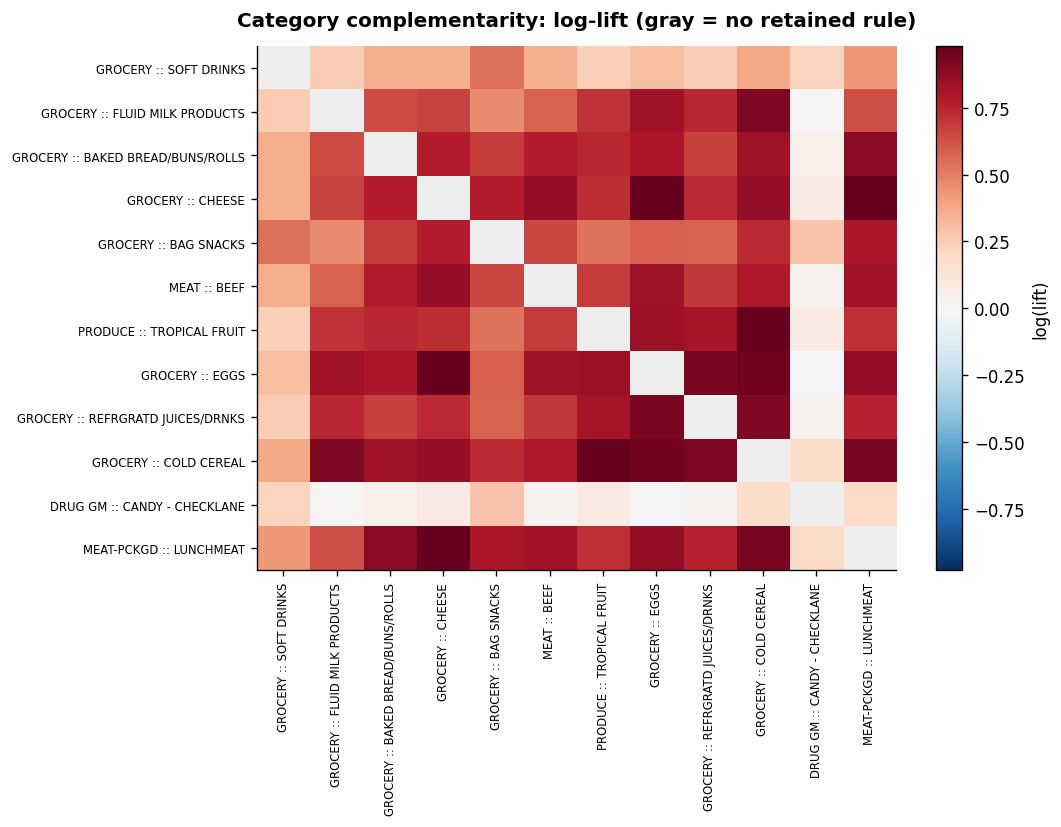

In [14]:
top_categories = snap_valid["category"].head(12)["category_id"].to_list()

pair_small = (
    snap_valid["pair"]
    .filter(
        pl.col("anchor_category").is_in(top_categories)
        & pl.col("candidate_category").is_in(top_categories)
    )
    .select("anchor_category", "candidate_category", "log_lift")
    .to_pandas()
)

heat = pd.DataFrame(
    np.full((len(top_categories), len(top_categories)), np.nan),
    index=top_categories,
    columns=top_categories,
)

for row in pair_small.itertuples(index=False):
    heat.loc[row.anchor_category, row.candidate_category] = row.log_lift

fig, ax = plt.subplots(figsize=(9, 7))
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("#EEEEEE")
finite_lift = heat.values[np.isfinite(heat.values)]
limit = max(float(np.max(np.abs(finite_lift))) if len(finite_lift) else 0.0, 1e-6)
im = ax.imshow(np.ma.masked_invalid(heat.values), aspect="auto", cmap=cmap,
               norm=TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit))
ax.set_xticks(range(len(top_categories)))
ax.set_yticks(range(len(top_categories)))
ax.set_xticklabels(top_categories, rotation=90, fontsize=7)
ax.set_yticklabels(top_categories, fontsize=7)
ax.set_title("Category complementarity: log-lift (gray = no retained rule)")
fig.colorbar(im, ax=ax, label="log(lift)")
plt.tight_layout()
plt.show()


## 5. Features and models

**Question:** how do simple rules and learned scoring methods compare?

The model ladder starts with popularity, basket complements and similar shoppers. Three main models learn purchase relevance, value relevance and new-category value. Linear, boosted-tree and randomized-tree competitors test different ways of combining the same shopping signals. CatBoost is an optional additional competitor.

Training keeps all retrieved positives and a deterministic sample of negatives, then retains baskets with a retrieved positive. This conditions training on a recoverable opportunity and changes the class mix; classifier outputs therefore serve as **ranking scores**, not calibrated probabilities. Evaluation uses full candidate pools and all sampled contexts, including retrieval failures.

Higher-value purchase grades are defined from training data only. The new-category target adds a grade bonus for purchases in a category unfamiliar to the household; it is not an uplift or causal target.

In [15]:
def add_candidate_features(ctx, retrieved, snapshot):
    cutoff = snapshot["cutoff"]

    # Snapshot-wide household features.
    hist = items.filter(pl.col("day") <= cutoff)

    hh_context = (
        hist.group_by("household_key")
        .agg(
            pl.col("basket_id").n_unique().alias("hh_total_baskets"),
            pl.col("sales_value")
            .clip(lower_bound=0)
            .sum()
            .alias("hh_recorded_sales"),
        )
        .with_columns(
            (
                pl.col("hh_recorded_sales")
                / pl.col("hh_total_baskets").clip(lower_bound=1)
            ).alias("hh_avg_basket_sales")
        )
    )

    prev_basket = (
        ctx.select("target_basket_id", "household_key", "previous_day")
        .join(
            items.select(
                "household_key",
                pl.col("day").alias("previous_day"),
                "basket_id",
                "product_id",
                "category_id",
                "brand",
            ),
            on=["household_key", "previous_day"],
            how="left",
        )
    )

    prev_context = (
        prev_basket.group_by("target_basket_id")
        .agg(
            pl.col("product_id").drop_nulls().n_unique().alias("prev_basket_skus"),
            pl.col("category_id").drop_nulls().n_unique().alias("prev_basket_categories"),
            pl.col("brand").drop_nulls().n_unique().alias("prev_basket_brands"),
        )
    )

    # Category-relative unit value is more stable than comparing prices
    # across fundamentally different category economics.
    hhcat_stats = snapshot["hhcat"].select(
        "household_key",
        "category_id",
        "hh_category_baskets",
        "hh_category_share",
    )

    hhbrand_stats = snapshot["hhbrand"].select(
        "household_key",
        "brand",
        "hh_brand_baskets",
    )

    feat = (
        retrieved
        .join(
            ctx.select(
                "target_basket_id",
                "household_key",
                "target_day",
                "days_since_previous",
                "history_baskets",
                "weekday",
            ),
            on="target_basket_id",
            how="left",
        )
        .join(
            snapshot["category"].select(
                "category_id",
                "category_baskets",
                "category_share",
                "global_category_rank",
            ),
            on="category_id",
            how="left",
        )
        .join(
            hhcat_stats,
            on=["household_key", "category_id"],
            how="left",
        )
        .join(hh_context, on="household_key", how="left")
        .join(prev_context, on="target_basket_id", how="left")
        .join(
            prod.select(
                "product_id",
                "department",
                "commodity_desc",
                "sub_commodity_desc",
                "brand",
                "curr_size_of_product",
            ),
            on="product_id",
            how="left",
        )
        .join(
            hhbrand_stats,
            on=["household_key", "brand"],
            how="left",
        )
        .join(
            snapshot["cat_weekday"].select(
                "category_id",
                "weekday",
                "category_weekday_rate",
            ),
            on=["category_id", "weekday"],
            how="left",
        )
        .join(
            items.select(
                pl.col("basket_id").alias("target_basket_id"),
                "product_id",
                pl.col("sales_value").alias("target_recorded_sales"),
                pl.lit(1, dtype=pl.Int8).alias("_target_membership"),
            ),
            on=["target_basket_id", "product_id"],
            how="left",
        )
        .join(
            first_cat_day,
            on=["household_key", "category_id"],
            how="left",
        )
        .with_columns(
            pl.col("_target_membership")
            .is_not_null()
            .cast(pl.Int8)
            .alias("label"),
            (
                (pl.col("hh_category_baskets").fill_null(0) + 0.25)
                /
                (
                    pl.col("hh_total_baskets").fill_null(1)
                    + 0.25 * snapshot["category"].height
                )
            ).alias("hh_category_share_smoothed"),
            (
                (pl.col("category_baskets").fill_null(0) + 0.25)
                /
                (
                    snapshot["total_baskets"]
                    + 0.25 * snapshot["category"].height
                )
            ).alias("global_category_share_smoothed"),
        )
        # Create preference_lift before referencing it in unexpectedness.
        .with_columns(
            (
                pl.col("hh_category_share_smoothed")
                / pl.col("global_category_share_smoothed")
                .clip(lower_bound=1e-6)
            ).alias("preference_lift"),
            pl.col("category_relative_unit_value")
            .fill_null(1.0)
            .clip(lower_bound=0, upper_bound=10)
            .alias("relative_unit_value"),
            (
                pl.col("hh_category_baskets").fill_null(0) > 0
            )
            .cast(pl.Int8)
            .alias("familiar_category_flag"),
        )
        .with_columns(
            (
                -pl.col("preference_lift")
                .clip(lower_bound=1e-6)
                .log(base=2)
            )
            .clip(lower_bound=0, upper_bound=4)
            .truediv(4)
            .alias("unexpectedness"),
            (
                pl.col("first_cat_day").is_null()
                | (pl.col("first_cat_day") >= pl.col("target_day"))
            )
            .cast(pl.Int8)
            .alias("new_category_flag"),
            (
                pl.when(
                    pl.col("first_cat_day").is_not_null()
                    & (pl.col("first_cat_day") < pl.col("target_day"))
                )
                .then(
                    (
                        pl.col("target_day") - pl.col("first_cat_day")
                    ).cast(pl.Float64)
                )
                .otherwise(0.0)
            ).alias("category_age_days"),
            pl.col("target_recorded_sales")
            .fill_null(0)
            .clip(lower_bound=0)
            .log1p()
            .alias("target_log_sales"),
        )
        .with_columns(
            (
                pl.col("new_category_flag")
                * pl.col("target_log_sales")
            ).alias("novel_value_label")
        )
    )

    feat = feat.with_columns((1 - pl.col("new_category_flag")).alias("familiar_category_flag"))

    fill_zero = [
        "hh_category_baskets",
        "hh_category_share",
        "hh_brand_baskets",
        "complement_max_log_lift",
        "complement_confidence",
        "complement_jaccard",
        "complement_score",
        "n_supporting_anchors",
        "peer_score",
        "peer_max_similarity",
        "supporting_peer_households",
        "category_weekday_rate",
        "n_retrieval_channels",
        "n_source_families",
    ]

    feat = feat.with_columns(
        *[
            pl.col(c).fill_null(0)
            for c in fill_zero
            if c in feat.columns
        ]
    )

    # Commercial-value potential proxy uses only pre-cutoff values.
    feat = feat.with_columns(
        # Recency and repetition signals: all values are snapshot-safe.
        pl.col("hh_category_recency_days")
        .fill_null(9999)
        .cast(pl.Float64)
        .alias("hh_category_recency_days_filled"),
        pl.col("hh_brand_recency_days")
        .fill_null(9999)
        .cast(pl.Float64)
        .alias("hh_brand_recency_days_filled"),
        (
            pl.col("hh_category_baskets").fill_null(0).cast(pl.Float64)
            / pl.col("history_baskets").fill_null(0).cast(pl.Float64).clip(lower_bound=1)
        ).alias("hh_category_repeat_rate"),
        (
            pl.col("category_weekday_rate").fill_null(0)
            * pl.col("hh_category_baskets").fill_null(0).cast(pl.Float64)
        ).alias("household_weekday_category_affinity"),
        (
            pl.col("n_retrieval_channels").fill_null(0).cast(pl.Float64)
            + 0.5 * pl.col("n_supporting_anchors").fill_null(0).cast(pl.Float64)
            + 0.5 * pl.col("supporting_peer_households").fill_null(0).cast(pl.Float64)
        ).alias("retrieval_support_strength"),
        (
            pl.col("time_decayed_sku_popularity").fill_null(0)
            * (1 + pl.col("sku_recent_flag").fill_null(0).cast(pl.Float64))
        ).alias("recent_popularity_interaction"),
        (
            pl.col("sku_category_share").fill_null(0)
            * pl.col("category_relative_unit_value").fill_null(1.0)
        ).alias("share_value_interaction"),
        (
            pl.col("days_since_previous").fill_null(0).cast(pl.Float64)
            / (1 + pl.col("history_baskets").fill_null(0).cast(pl.Float64))
        ).alias("interpurchase_gap_normalized"),
    ).with_columns(
        (
            pl.col("relative_unit_value")
            .fill_null(1.0)
            .clip(lower_bound=0, upper_bound=10)
            * (
                1
                + pl.col("sku_baskets")
                .fill_null(0)
                .cast(pl.Float64)
                .log1p()
            )
        ).alias("value_potential_proxy"),
        (
            pl.col("complement_score").fill_null(0)
            * (
                1
                + pl.col("n_supporting_anchors")
                .fill_null(0)
                .cast(pl.Float64)
            )
        ).alias("multi_anchor_complement"),
    )

    return feat.drop("_target_membership")


### Assemble the feature contract

Candidate labels are joined for supervised learning, but only the explicit `FEATURES` allowlist enters estimators. Missing recency uses a large “not seen” value, not zero days. Familiar/new-category flags refer to the same pre-target history and cannot contradict each other.

In [16]:
def add_candidate_features(ctx, retrieved, snapshot):
    """Attach past-only candidate features and next-basket training labels."""
    cutoff = snapshot["cutoff"]

    # Household statistics from the frozen split snapshot.
    history = items.filter(pl.col("day") <= cutoff)

    hh_context = (
        history.group_by("household_key")
        .agg(
            pl.col("basket_id").n_unique().alias("hh_total_baskets"),
            pl.col("sales_value")
            .clip(lower_bound=0)
            .sum()
            .alias("hh_recorded_sales"),
        )
        .with_columns(
            (
                pl.col("hh_recorded_sales")
                / pl.col("hh_total_baskets").clip(lower_bound=1)
            ).alias("hh_avg_basket_sales")
        )
    )

    # Context from the shopping day immediately before the target day.
    prev_context = (
        ctx.select("target_basket_id", "household_key", "previous_day")
        .join(
            items.select(
                "household_key",
                pl.col("day").alias("previous_day"),
                "product_id",
                "category_id",
                "brand",
            ),
            on=["household_key", "previous_day"],
            how="left",
        )
        .group_by("target_basket_id")
        .agg(
            pl.col("product_id")
            .drop_nulls()
            .n_unique()
            .alias("prev_basket_skus"),
            pl.col("category_id")
            .drop_nulls()
            .n_unique()
            .alias("prev_basket_categories"),
            pl.col("brand")
            .drop_nulls()
            .n_unique()
            .alias("prev_basket_brands"),
        )
    )

    # Preserve the expected join keys even if a snapshot omits a recency field.
    hhcat_stats = snapshot["hhcat"]
    if "hh_category_recency_days" not in hhcat_stats.columns:
        hhcat_stats = hhcat_stats.with_columns(
            pl.lit(None, dtype=pl.Float64)
            .alias("hh_category_recency_days")
        )
    hhcat_stats = hhcat_stats.select(
        "household_key",
        "category_id",
        "hh_category_baskets",
        "hh_category_share",
        "hh_category_recency_days",
    )

    hhbrand_stats = snapshot["hhbrand"]
    if "hh_brand_recency_days" not in hhbrand_stats.columns:
        hhbrand_stats = hhbrand_stats.with_columns(
            pl.lit(None, dtype=pl.Float64)
            .alias("hh_brand_recency_days")
        )
    hhbrand_stats = hhbrand_stats.select(
        "household_key",
        "brand",
        "hh_brand_baskets",
        "hh_brand_recency_days",
    )

    # One target row per basket/product, even if the source contains
    # more than one transaction line for that product.
    target_membership = (
        items.group_by("basket_id", "product_id")
        .agg(
            pl.col("sales_value")
            .sum()
            .alias("target_recorded_sales")
        )
        .rename({"basket_id": "target_basket_id"})
        .with_columns(
            pl.lit(1, dtype=pl.Int8).alias("_target_membership")
        )
    )

    feat = (
        retrieved
        .join(
            ctx.select(
                "target_basket_id",
                "household_key",
                "target_day",
                "days_since_previous",
                "history_baskets",
                "weekday",
            ),
            on="target_basket_id",
            how="left",
        )
        .join(
            snapshot["category"].select(
                "category_id",
                "category_baskets",
                "category_share",
                "global_category_rank",
            ),
            on="category_id",
            how="left",
        )
        .join(
            hhcat_stats,
            on=["household_key", "category_id"],
            how="left",
        )
        .join(hh_context, on="household_key", how="left")
        .join(prev_context, on="target_basket_id", how="left")
        .join(
            prod.select(
                "product_id",
                "department",
                "commodity_desc",
                "sub_commodity_desc",
                "brand",
                "curr_size_of_product",
            ),
            on="product_id",
            how="left",
        )
        .join(
            hhbrand_stats,
            on=["household_key", "brand"],
            how="left",
        )
        .join(
            snapshot["cat_weekday"].select(
                "category_id",
                "weekday",
                "category_weekday_rate",
            ),
            on=["category_id", "weekday"],
            how="left",
        )
        .join(
            target_membership,
            on=["target_basket_id", "product_id"],
            how="left",
        )
        .join(
            first_cat_day,
            on=["household_key", "category_id"],
            how="left",
        )
    )

    # Check the source fields at the point where the traceback occurred.
    assert "hh_category_recency_days" in feat.columns
    assert "hh_brand_recency_days" in feat.columns

    n_categories = max(snapshot["category"].height, 1)
    n_historical_baskets = max(snapshot["total_baskets"], 1)

    feat = feat.with_columns(
        pl.col("_target_membership")
        .is_not_null()
        .cast(pl.Int8)
        .alias("label"),

        (
            (pl.col("hh_category_baskets").fill_null(0) + 0.25)
            / (
                pl.col("hh_total_baskets").fill_null(1)
                + 0.25 * n_categories
            )
        ).alias("hh_category_share_smoothed"),

        (
            (pl.col("category_baskets").fill_null(0) + 0.25)
            / (n_historical_baskets + 0.25 * n_categories)
        ).alias("global_category_share_smoothed"),

        pl.col("category_relative_unit_value")
        .fill_null(1.0)
        .clip(lower_bound=0, upper_bound=10)
        .alias("relative_unit_value"),

        (
            pl.col("first_cat_day").is_null()
            | (pl.col("first_cat_day") >= pl.col("target_day"))
        )
        .cast(pl.Int8)
        .alias("new_category_flag"),

        pl.col("target_recorded_sales")
        .fill_null(0)
        .clip(lower_bound=0)
        .log1p()
        .alias("target_log_sales"),
    )

    feat = feat.with_columns(
        (
            pl.col("hh_category_share_smoothed")
            / pl.col("global_category_share_smoothed")
            .clip(lower_bound=1e-6)
        ).alias("preference_lift"),

        (1 - pl.col("new_category_flag"))
        .cast(pl.Int8)
        .alias("familiar_category_flag"),

        pl.when(
            pl.col("first_cat_day").is_not_null()
            & (pl.col("first_cat_day") < pl.col("target_day"))
        )
        .then(
            (pl.col("target_day") - pl.col("first_cat_day"))
            .cast(pl.Float64)
        )
        .otherwise(0.0)
        .alias("category_age_days"),

        # Null means no usable historical recency, not "seen today".
        pl.col("hh_category_recency_days")
        .cast(pl.Float64)
        .fill_null(9999.0)
        .alias("hh_category_recency_days_filled"),

        pl.col("hh_brand_recency_days")
        .cast(pl.Float64)
        .fill_null(9999.0)
        .alias("hh_brand_recency_days_filled"),
    )

    feat = feat.with_columns(
        (
            -pl.col("preference_lift")
            .clip(lower_bound=1e-6)
            .log(base=2)
        )
        .clip(lower_bound=0, upper_bound=4)
        .truediv(4)
        .alias("unexpectedness"),

        (
            pl.col("new_category_flag")
            * pl.col("target_log_sales")
        ).alias("novel_value_label"),
    )

    # Zero means no observed count, channel support or prior-basket count.
    # Do NOT zero-fill either raw recency column.
    zero_fill = [
        "hh_category_baskets",
        "hh_category_share",
        "hh_brand_baskets",
        "complement_max_log_lift",
        "complement_confidence",
        "complement_jaccard",
        "complement_score",
        "n_supporting_anchors",
        "peer_score",
        "peer_max_similarity",
        "supporting_peer_households",
        "category_weekday_rate",
        "n_retrieval_channels",
        "n_source_families",
        "prev_basket_skus",
        "prev_basket_categories",
        "prev_basket_brands",
    ]
    feat = feat.with_columns(
        [
            pl.col(column).fill_null(0)
            for column in zero_fill
            if column in feat.columns
        ]
    )

    feat = feat.with_columns(
        (
            pl.col("hh_category_baskets").cast(pl.Float64)
            / pl.col("history_baskets")
            .fill_null(0)
            .cast(pl.Float64)
            .clip(lower_bound=1)
        ).alias("hh_category_repeat_rate"),

        (
            pl.col("category_weekday_rate")
            * pl.col("hh_category_baskets").cast(pl.Float64)
        ).alias("household_weekday_category_affinity"),

        (
            pl.col("n_retrieval_channels").cast(pl.Float64)
            + 0.5 * pl.col("n_supporting_anchors").cast(pl.Float64)
            + 0.5 * pl.col("supporting_peer_households").cast(pl.Float64)
        ).alias("retrieval_support_strength"),

        (
            pl.col("time_decayed_sku_popularity").fill_null(0)
            * (
                1
                + pl.col("sku_recent_flag")
                .fill_null(0)
                .cast(pl.Float64)
            )
        ).alias("recent_popularity_interaction"),

        (
            pl.col("sku_category_share").fill_null(0)
            * pl.col("category_relative_unit_value").fill_null(1.0)
        ).alias("share_value_interaction"),

        (
            pl.col("days_since_previous")
            .fill_null(0)
            .cast(pl.Float64)
            / (
                1
                + pl.col("history_baskets")
                .fill_null(0)
                .cast(pl.Float64)
            )
        ).alias("interpurchase_gap_normalized"),
    )

    feat = feat.with_columns(
        (
            pl.col("relative_unit_value")
            * (
                1
                + pl.col("sku_baskets")
                .fill_null(0)
                .cast(pl.Float64)
                .log1p()
            )
        ).alias("value_potential_proxy"),

        (
            pl.col("complement_score")
            * (
                1
                + pl.col("n_supporting_anchors").cast(pl.Float64)
            )
        ).alias("multi_anchor_complement"),
    )

    return feat.drop("_target_membership")


train_pool = add_candidate_features(
    train_ctx, train_retrieved, snap_train
)
valid_pool = add_candidate_features(
    valid_ctx, valid_retrieved, snap_valid
)
test_pool = add_candidate_features(
    test_ctx, test_retrieved, snap_test
)

FEATURES = [
    "sku_baskets",
    "sku_category_share",
    "sku_pop_rank",
    "sku_value_rank",
    "sku_recent_flag",
    "time_decayed_sku_popularity",
    "category_baskets",
    "category_share",
    "global_category_rank",
    "hh_category_baskets",
    "hh_category_share",
    "hh_category_recency_days_filled",
    "hh_brand_baskets",
    "hh_brand_recency_days_filled",
    "preference_lift",
    "unexpectedness",
    "new_category_flag",
    "familiar_category_flag",
    "category_age_days",
    "relative_unit_value",
    "category_weekday_rate",
    "days_since_previous",
    "history_baskets",
    "prev_basket_skus",
    "prev_basket_categories",
    "prev_basket_brands",
    "hh_total_baskets",
    "hh_avg_basket_sales",
    "complement_max_log_lift",
    "complement_confidence",
    "complement_jaccard",
    "complement_score",
    "multi_anchor_complement",
    "peer_score",
    "peer_max_similarity",
    "supporting_peer_households",
    "n_retrieval_channels",
    "n_source_families",
    "channel_discovery",
    "channel_familiar",
    "channel_complement",
    "channel_peer",
    "value_potential_proxy",
    "hh_category_repeat_rate",
    "household_weekday_category_affinity",
    "retrieval_support_strength",
    "recent_popularity_interaction",
    "share_value_interaction",
    "interpurchase_gap_normalized",
]

required = list(dict.fromkeys(FEATURES + [
    "target_basket_id",
    "product_id",
    "label",
    "target_recorded_sales",
]))

summary_rows = []

for name, frame in [
    ("train", train_pool),
    ("validation", valid_pool),
    ("test", test_pool),
]:
    missing = [column for column in required
               if column not in frame.columns]
    assert not missing, f"{name} missing columns: {missing}"

    assert (
        frame.select("target_basket_id", "product_id")
        .unique()
        .height == frame.height
    ), f"{name} has duplicate basket/product candidates"

    assert frame.filter(
        (
            pl.col("new_category_flag")
            + pl.col("familiar_category_flag")
        ) != 1
    ).height == 0, f"{name} has contradictory category flags"

    counts = (
        frame.group_by("target_basket_id")
        .len()
        .get_column("len")
    )

    summary_rows.append({
        "split": name,
        "candidate_products": frame.height,
        "observed_first_purchase_labels": (
            int(frame["label"].sum()) if frame.height else 0
        ),
        "median_candidates": (
            float(counts.median()) if len(counts) else None
        ),
    })

show(
    pl.DataFrame(summary_rows),
    "Candidate pool after feature engineering",
)

**Candidate pool after feature engineering**

,split,candidate_products,observed_first_purchase_labels,median_candidates
0,train,2638000,2026,528.000000
1,validation,1302434,784,522.000000
2,test,1297960,845,520.000000


### Sampling and training targets

All learned approaches see the same sampled candidate rows. Purchase labels identify first-time purchases; value grades prefer higher recorded sales; new-category grades add an explicit discovery bonus. Group sizes preserve the basket structure for ranking algorithms.

In [17]:
def training_rows(pool):
    # Keep all observed positives. Sample negatives deterministically.
    sample_key = pl.concat_str(
        [
            pl.col("target_basket_id").cast(pl.String),
            pl.lit("|"),
            pl.col("product_id").cast(pl.String),
        ]
    ).hash(seed=SEED)

    sampled = pool.filter(
        (pl.col("label") == 1)
        | ((sample_key % NEGATIVE_MOD) == 0)
    )

    positive_baskets = sampled.filter(
        pl.col("label") == 1
    )["target_basket_id"].unique()

    sampled = sampled.join(
        positive_baskets.to_frame(),
        on="target_basket_id",
        how="semi",
    )

    return sampled.sort("target_basket_id", "product_id")

train_rows = training_rows(train_pool)

def feature_matrix(frame):
    X = (
        frame.select(
            [pl.col(c).cast(pl.Float32).fill_null(0.0) for c in FEATURES]
        )
        .to_numpy()
        .astype("float32")
    )

    return np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

if train_rows.height == 0:
    raise ValueError(
        "No positive training baskets survived retrieval. Check the retrieval "
        "funnel and input data before fitting models."
    )

X_train = feature_matrix(train_rows)
y_purchase = train_rows["label"].to_numpy().astype("int32")

positive_mask = train_rows["label"].to_numpy() == 1
positive_sales = np.clip(
    train_rows["target_recorded_sales"].to_numpy()[positive_mask],
    a_min=0,
    a_max=None,
)

if len(positive_sales):
    log_pos = np.log1p(positive_sales)
    q50, q75, q90 = np.quantile(log_pos, [0.50, 0.75, 0.90])
else:
    q50 = q75 = q90 = 0.0

train_rows = train_rows.with_columns(
    pl.when(pl.col("label") == 0).then(0)
    .when(pl.col("target_log_sales") <= q50).then(1)
    .when(pl.col("target_log_sales") <= q75).then(2)
    .when(pl.col("target_log_sales") <= q90).then(3)
    .otherwise(4)
    .cast(pl.Int8)
    .alias("value_grade"),
).with_columns(
    pl.when(pl.col("label") == 0).then(0)
    .when(pl.col("new_category_flag") == 1)
        .then((pl.col("value_grade") + 1).clip(upper_bound=5))
    .otherwise(pl.col("value_grade"))
    .cast(pl.Int8)
    .alias("novel_value_grade"),
)

y_value = train_rows["value_grade"].to_numpy().astype("int32")
y_novel_value = train_rows["novel_value_grade"].to_numpy().astype("int32")

group_sizes = (
    train_rows.group_by("target_basket_id", maintain_order=True)
    .len()["len"]
    .to_list()
)
assert sum(group_sizes) == len(train_rows)


### Fit the main scoring models

Choose the supported backend rather than requiring one library. The scikit-learn fallback keeps the notebook runnable with core dependencies; it is reported as a fallback, never mislabeled LambdaMART.

In [18]:
def fit_rankers(X, y_purchase, y_value, y_novel_value, groups):
    models = {}

    if HAS_LIGHTGBM and len(np.unique(y_purchase)) > 1:
        common = dict(
            objective="lambdarank",
            metric="ndcg",
            ndcg_at=[5, 10, 20],
            learning_rate=0.035,
            num_leaves=31,
            min_child_samples=60,
            n_jobs=4,
            deterministic=True,
            force_col_wise=True,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=SEED,
            verbosity=-1,
        )

        m_purchase = LGBMRanker(n_estimators=280, **common)
        m_value = LGBMRanker(n_estimators=320, random_state=SEED + 1, **{k:v for k,v in common.items() if k!="random_state"})
        m_novel_value = LGBMRanker(n_estimators=320, random_state=SEED + 2, **{k:v for k,v in common.items() if k!="random_state"})

        m_purchase.fit(X, y_purchase, group=groups)
        m_value.fit(X, y_value, group=groups)
        m_novel_value.fit(X, y_novel_value, group=groups)

        models.update(
            purchase=m_purchase,
            value=m_value,
            novel_value=m_novel_value,
            backend="LightGBM LambdaMART",
        )
    elif HAS_CATBOOST and len(np.unique(y_purchase)) > 1:
        # Optional ranking backend when LightGBM is unavailable.
        common_cb = dict(
            loss_function="YetiRank",
            iterations=350,
            learning_rate=0.04,
            depth=7,
            random_seed=SEED,
            verbose=False,
            allow_writing_files=False,
            thread_count=4,
        )
        m_purchase = CatBoostRanker(**common_cb)
        m_value = CatBoostRanker(**{**common_cb, "random_seed": SEED + 1})
        m_novel_value = CatBoostRanker(**{**common_cb, "random_seed": SEED + 2})
        m_purchase.fit(X, y_purchase, group_id=np.repeat(np.arange(len(groups)), groups))
        m_value.fit(X, y_value, group_id=np.repeat(np.arange(len(groups)), groups))
        m_novel_value.fit(X, y_novel_value, group_id=np.repeat(np.arange(len(groups)), groups))
        models.update(
            purchase=m_purchase,
            value=m_value,
            novel_value=m_novel_value,
            backend="CatBoost YetiRank",
        )
    else:
        # Deterministic Kaggle fallback.
        if len(np.unique(y_purchase)) > 1:
            m_purchase = make_pipeline(
                StandardScaler(),
                LogisticRegression(
                    max_iter=500,
                    class_weight="balanced",
                    random_state=SEED,
                ),
            )
            m_purchase.fit(X, y_purchase)
        else:
            m_purchase = DummyClassifier(strategy="prior")
            m_purchase.fit(X, y_purchase)

        if len(np.unique(y_novel_value)) > 1:
            m_novel_value = HistGradientBoostingClassifier(
                max_iter=180,
                max_leaf_nodes=31,
                min_samples_leaf=60,
                random_state=SEED + 2,
            )
            m_novel_value.fit(X, y_novel_value)
        else:
            m_novel_value = DummyClassifier(strategy="prior")
            m_novel_value.fit(X, y_novel_value)

        # Regression value fallback.
        if len(np.unique(y_value)) > 1:
            m_value = HistGradientBoostingRegressor(
                max_iter=200,
                max_leaf_nodes=31,
                min_samples_leaf=60,
                random_state=SEED + 1,
            )
            m_value.fit(X, y_value)
        else:
            m_value = DummyRegressor(strategy="mean")
            m_value.fit(X, y_value)

        models.update(
            purchase=m_purchase,
            value=m_value,
            novel_value=m_novel_value,
            backend="scikit-learn fallback",
        )

    return models


/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


Backend: LightGBM LambdaMART | rows=130,184 | positive novel purchases=2,026


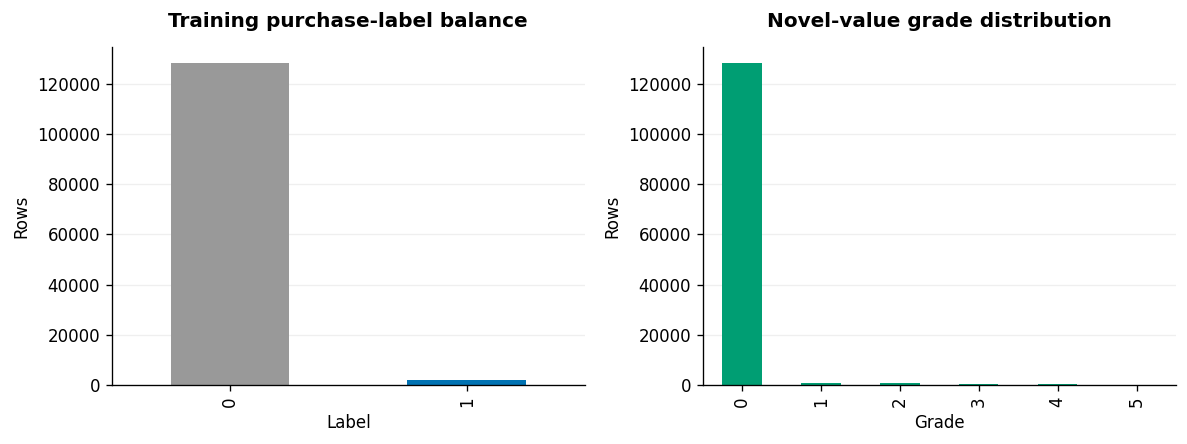

In [19]:
models = fit_rankers(
    X_train,
    y_purchase,
    y_value,
    y_novel_value,
    group_sizes,
)

propensity_ranker = models["purchase"]
value_ranker = models["value"]
novel_value_ranker = models["novel_value"]

print(
    f"Backend: {models['backend']} | rows={len(train_rows):,} "
    f"| positive novel purchases={int(y_purchase.sum()):,}"
)

# Diagnostic — training label balance and target-grade distribution
_training_diag = train_rows.select("label", "value_grade", "novel_value_grade").to_pandas()
if not _training_diag.empty:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    _training_diag["label"].value_counts().sort_index().plot.bar(ax=axes[0], color=["#999999", "#0072B2"])
    axes[0].set(title="Training purchase-label balance", xlabel="Label", ylabel="Rows")
    axes[0].grid(axis="y", alpha=0.2)
    _training_diag["novel_value_grade"].value_counts().sort_index().plot.bar(ax=axes[1], color="#009E73")
    axes[1].set(title="Novel-value grade distribution", xlabel="Grade", ylabel="Rows")
    axes[1].grid(axis="y", alpha=0.2)
    plt.tight_layout(); plt.show()


### Register every active model

The registry holds the estimator, score column, plain-language description and plot color. It includes the three baselines and main learned models, plus the actually fitted challengers. If an optional model does not run, it is not shown as a result.

In [20]:
# The model registry is the single source for scoring, metrics and plots.
MODEL_REGISTRY = {}
PALETTE = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00",
           "#56B4E9", "#6F4E7C", "#7A6A19", "#555555", "#332288", "#44AA99", "#AA4499"]

def register_model(name, score_col, description, estimator=None, prediction="score", family="Learned", is_slate=False):
    assert name not in MODEL_REGISTRY, f"Duplicate model: {name}"
    MODEL_REGISTRY[name] = dict(score_col=score_col, description=description,
        estimator=estimator, prediction=prediction, family=family, is_slate=is_slate,
        color=PALETTE[len(MODEL_REGISTRY) % len(PALETTE)])

register_model("Popular products", "popularity_score", "A simple starting point: products and categories bought often.", family="Baseline")
register_model("Basket complements", "complement_baseline", "Products in categories that often appear with the previous basket; doubles the score for new categories.", family="Baseline")
register_model("Similar shoppers", "peer_discovery_baseline", "Products supported by similar households, mixed with under-explored categories.", family="Baseline")
register_model("Purchase relevance", "propensity_raw", "Learns which first-time products are most relevant.", propensity_ranker, "binary")
register_model("Purchase value", "value_raw", "Learns a ranking that favors higher-value observed purchases.", value_ranker)
register_model("New-category value", "novel_value_raw", "Adds extra relevance to valuable purchases in a category new to the shopper.", novel_value_ranker, "ordinal")

challengers = {}
if len(np.unique(y_purchase)) > 1:
    challengers["Linear model"] = make_pipeline(StandardScaler(),
        LogisticRegression(max_iter=600, class_weight="balanced", random_state=SEED))
    challengers["Boosted trees"] = HistGradientBoostingClassifier(
        max_iter=130, learning_rate=0.065, max_leaf_nodes=23,
        min_samples_leaf=70, l2_regularization=2.0, random_state=SEED)
    challengers["Randomized trees"] = ExtraTreesClassifier(
        n_estimators=100, max_depth=16, min_samples_leaf=30,
        max_features=0.8, class_weight="balanced", n_jobs=4, random_state=SEED)
    for name, estimator in challengers.items():
        estimator.fit(X_train, y_purchase)
        register_model(name, {"Linear model":"linear_raw", "Boosted trees":"gbdt_raw",
                       "Randomized trees":"extra_trees_raw"}[name],
            {"Linear model":"An interpretable weighted combination of shopping signals.",
             "Boosted trees":"Learns combinations of signals, correcting earlier mistakes.",
             "Randomized trees":"Averages many randomized decision trees to capture different shopping patterns."}[name],
            estimator, "binary")

if HAS_CATBOOST and RUN_CATBOOST_CHALLENGER and len(np.unique(y_purchase)) > 1:
    estimator = CatBoostRanker(loss_function="YetiRank", iterations=220, depth=6,
        learning_rate=0.05, random_seed=SEED, verbose=False,
        allow_writing_files=False, thread_count=4)
    estimator.fit(X_train, y_purchase, group_id=np.repeat(np.arange(len(group_sizes)), group_sizes))
    challengers["CatBoost challenger"] = estimator
    register_model("CatBoost challenger", "catboost_challenger_raw",
                   "An alternative algorithm that learns product order within a basket.", estimator)

model_catalog = pd.DataFrame([{"Model":name, "Role":spec["family"],
    "How it works":spec["description"], "Implementation":type(spec["estimator"]).__name__
    if spec["estimator"] is not None else "Fixed rule"}
    for name, spec in MODEL_REGISTRY.items()])
show(model_catalog, "Models that actually ran", max_rows=50)
display(Markdown(f"Main backend: `{models['backend']}`. Labels describe each model's role, "
                 "not an assumed library. All active models automatically enter the visual report."))


**Models that actually ran**

,Model,Role,How it works,Implementation
0,Popular products,Baseline,A simple starting point: products and categories bought often.,Fixed rule
1,Basket complements,Baseline,Products in categories that often appear with the previous basket; doubles the score for new categories.,Fixed rule
2,Similar shoppers,Baseline,"Products supported by similar households, mixed with under-explored categories.",Fixed rule
3,Purchase relevance,Learned,Learns which first-time products are most relevant.,LGBMRanker
4,Purchase value,Learned,Learns a ranking that favors higher-value observed purchases.,LGBMRanker
5,New-category value,Learned,Adds extra relevance to valuable purchases in a category new to the shopper.,LGBMRanker
6,Linear model,Learned,An interpretable weighted combination of shopping signals.,Pipeline
7,Boosted trees,Learned,"Learns combinations of signals, correcting earlier mistakes.",HistGradientBoostingClassifier
8,Randomized trees,Learned,Averages many randomized decision trees to capture different shopping patterns.,ExtraTreesClassifier


Main backend: `LightGBM LambdaMART`. Labels describe each model's role, not an assumed library. All active models automatically enter the visual report.

## 6. Validate and select

**Question:** how should relevance, purchase value and discovery be balanced?

Candidate scores are computed for validation first. Three learned scores and complement evidence are converted to within-basket percentiles; equal raw scores receive equal percentiles. Product ID only breaks final ranking ties.

The final slate is a greedy diversity-aware list, with a category cap and penalties for same-category/brand repetition. A cap can produce shorter lists; evaluation uses the items actually returned.

In [21]:
def predict_estimator(estimator, X, prediction="score"):
    if len(X) == 0:
        return np.empty(0, dtype=float)
    if prediction in {"binary", "ordinal"} and hasattr(estimator, "predict_proba"):
        probabilities = estimator.predict_proba(X)
        classes = np.asarray(estimator.classes_)
        if prediction == "ordinal":
            return np.asarray(probabilities @ classes.astype(float), dtype=float)
        positive = np.flatnonzero(classes == 1)
        return probabilities[:, positive[0]] if len(positive) else np.zeros(len(X))
    return np.asarray(estimator.predict(X), dtype=float).reshape(-1)

def add_basket_percentile(df, score_col, out_col):
    return df.with_columns(
        pl.when(pl.col(score_col).max().over("target_basket_id") > pl.col(score_col).min().over("target_basket_id"))
        .then(1 - (pl.col(score_col).rank(method="average", descending=True).over("target_basket_id") - 1)
              / (pl.len().over("target_basket_id") - 1).clip(lower_bound=1))
        .otherwise(0.5).alias(out_col)
    )

def score_pool(pool):
    scored = pool.with_columns(
        (
            0.65 / (10 + pl.col("sku_pop_rank").fill_null(999))
            + 0.35 / (10 + pl.col("global_category_rank").fill_null(999))
        ).alias("popularity_score"),
        (
            pl.col("complement_score").fill_null(0)
            * (1 + pl.col("new_category_flag").fill_null(0))
        ).alias("complement_baseline"),
        (
            0.6 * pl.col("peer_score").fill_null(0)
            + 0.4 * pl.col("unexpectedness").fill_null(0)
        ).alias("peer_discovery_baseline"),
    )

    X_scored = feature_matrix(scored)
    for name, spec in MODEL_REGISTRY.items():
        if spec["estimator"] is not None:
            predictions = predict_estimator(spec["estimator"], X_scored, spec["prediction"])
            assert len(predictions) == scored.height and np.isfinite(predictions).all(), name
            scored = scored.with_columns(pl.Series(spec["score_col"], predictions))

    for source_col, pct_col in [
        ("propensity_raw", "propensity_pct"),
        ("value_raw", "value_pct"),
        ("novel_value_raw", "novel_value_pct"),
        ("complement_score", "complement_pct"),
    ]:
        scored = add_basket_percentile(scored, source_col, pct_col)

    return scored

valid_scored_base = score_pool(valid_pool)

def add_blend_score(df, blend):
    wp, wv, wnv, wc, we = blend
    return df.with_columns(
        (
            wp * pl.col("propensity_pct")
            + wv * pl.col("value_pct")
            + wnv * pl.col("novel_value_pct")
            + wc * pl.col("complement_pct")
            + we * pl.col("unexpectedness")
        ).alias("blend_score")
    )

def mmr_rerank(df, score_col="blend_score", k=10, pool_k=MMR_POOL_K):
    pool = (
        df.sort(
            "target_basket_id",
            score_col,
            "product_id",
            descending=[False, True, False],
        )
        .with_columns(
            pl.col("product_id").cum_count().over("target_basket_id").alias("_raw_rank")
        )
        .filter(pl.col("_raw_rank") <= pool_k)
    )

    selected_rows = []

    for basket_id, grp in pool.group_by("target_basket_id", maintain_order=True):
        rows = grp.to_dicts()
        chosen = []
        category_counts = {}
        remaining = rows.copy()

        while remaining and len(chosen) < k:
            best = None
            best_utility = -np.inf

            for row in remaining:
                cat = row.get("category_id")
                if category_counts.get(cat, 0) >= MAX_PER_CATEGORY:
                    continue

                redundancy = 0.0
                for prev in chosen:
                    same_cat = float(cat == prev.get("category_id"))
                    same_brand = float(row.get("brand") == prev.get("brand"))
                    redundancy = max(redundancy, 0.85 * same_cat + 0.15 * same_brand)

                utility = float(row.get(score_col, 0.0) or 0.0) - 0.18 * redundancy
                if not np.isfinite(utility):
                    utility = -np.inf

                if utility > best_utility:
                    best_utility = utility
                    best = row

            if best is None:
                break

            best = dict(best)
            best["final_mmr_score"] = float(best_utility)
            best["slate_rank"] = len(chosen) + 1
            chosen.append(best)

            cat = best.get("category_id")
            category_counts[cat] = category_counts.get(cat, 0) + 1

            remaining = [
                r for r in remaining
                if r["product_id"] != best["product_id"]
            ]

        selected_rows.extend(chosen)

    # Include generated fields explicitly; input-only schemas discard them.
    output_schema = dict(pool.schema)
    output_schema.update({
        "final_mmr_score": pl.Float64,
        "slate_rank": pl.Int64,
    })
    if not selected_rows:
        return pl.DataFrame(schema=output_schema)
    return pl.from_dicts(selected_rows, schema=output_schema, strict=True)

display(Markdown(
    "**Scoring note:** `propensity_pct`, `value_pct`, `novel_value_pct`, and `complement_pct` "
    "are within-basket ranking transforms. They are intentionally not described as probabilities."
))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with fea

**Scoring note:** `propensity_pct`, `value_pct`, `novel_value_pct`, and `complement_pct` are within-basket ranking transforms. They are intentionally not described as probabilities.

### How to read performance

| Display label | Technical metric | What it means |
|---|---|---|
| First-time products recovered | Recall@K | Matched first-time products / all observed first-time products, including retrieval misses |
| Baskets with a match | Basket hit rate@K | Baskets with at least one match / baskets with an opportunity in that segment |
| Observed purchase value recovered | Recorded-sales capture@K | Nonnegative recorded sales for matched products / nonnegative sales for all truth products |
| Ordering quality | Value-weighted nDCG@K | Quality of placing relevant, higher-value purchases near the top; 0–1 index |
| Precision on returned recommendations | Precision@K | Matched products / actually returned recommendations, including shorter lists |

For example, recovering 8 of 40 first-time products means 20% product recovery. It does **not** mean 20% sales lift.

Recall and sales capture are pooled across products; basket hit rate uses opportunity baskets. nDCG averages across **all sampled contexts**, assigning zero when a context has no positive value relevance in the segment. Its relevance is `log(1 + nonnegative recorded sales)`, not the discrete grades used for training. These denominators intentionally differ. Segments overlap, and segment-specific precision uses the full recommendation count as its denominator.

Scores and within-basket percentiles are ranking aids, not calibrated purchase probabilities. No chart interprets them as conversion forecasts.

In [22]:
def target_truth(contexts):
    target_items = (
        items
        .select(
            pl.col("basket_id").alias("target_basket_id"),
            "product_id",
            "category_id",
            pl.col("sales_value").clip(lower_bound=0).alias("truth_sales"),
        )
    )

    return (
        contexts.select("target_basket_id", "household_key", "target_day")
        .join(target_items, on="target_basket_id", how="inner")
        .join(first_item_day, on=["household_key", "product_id"], how="inner")
        .join(first_cat_day, on=["household_key", "category_id"], how="inner")
        .filter(pl.col("first_item_day") == pl.col("target_day"))
        .with_columns(
            (pl.col("first_cat_day") == pl.col("target_day")).alias("new_category")
        )
        .select(
            "target_basket_id",
            "product_id",
            "truth_sales",
            "new_category",
        )
    )

def ranked_pool(df, score_col):
    return (
        df.sort(
            "target_basket_id",
            score_col,
            "product_id",
            descending=[False, True, False],
        )
        .with_columns(
            pl.col("product_id").cum_count().over("target_basket_id").alias("rank")
        )
    )

def ranked_slate(slate):
    return slate.select(
        [c for c in ["target_basket_id", "product_id", "slate_rank"] if c in slate.columns]
    ).rename({"slate_rank": "rank"})

def segment_truth(truth):
    return {
        "all novel SKUs": truth,
        "new category": truth.filter(pl.col("new_category")),
        "familiar category": truth.filter(~pl.col("new_category")),
        "high-value novel SKU": truth.filter(
            pl.col("truth_sales") >= high_value_threshold
        ),
    }

train_truth = target_truth(train_ctx)

positive_truth_sales = train_truth.filter(
    pl.col("truth_sales") > 0
)["truth_sales"]

high_value_threshold = (
    float(positive_truth_sales.quantile(0.75))
    if positive_truth_sales.len()
    else 0.0
)

def ndcg_at_k(contexts, truth, ranked, k):
    top = ranked.filter(pl.col("rank") <= k)
    hit = truth.join(
        top.select("target_basket_id", "product_id", "rank"),
        on=["target_basket_id", "product_id"],
        how="inner",
    )

    # Relevance = log(1 + recorded sales), which avoids one extremely large basket
    # dominating the metric.
    hit = hit.with_columns(
        pl.col("truth_sales").log1p().alias("relevance")
    )

    dcg = (
        hit.with_columns(
            (
                pl.col("relevance")
                / (pl.col("rank").cast(pl.Float64) + 1).log(base=2)
            ).alias("gain")
        )
        .group_by("target_basket_id")
        .agg(pl.col("gain").sum().alias("dcg"))
    )

    ideal = (
        truth.with_columns(
            pl.col("truth_sales").log1p().alias("relevance")
        )
        .sort(
            "target_basket_id",
            "relevance",
            descending=[False, True],
        )
        .with_columns(
            pl.col("product_id").cum_count().over("target_basket_id").alias("ideal_rank")
        )
        .filter(pl.col("ideal_rank") <= k)
        .with_columns(
            (
                pl.col("relevance")
                / (pl.col("ideal_rank").cast(pl.Float64) + 1).log(base=2)
            ).alias("ideal_gain")
        )
        .group_by("target_basket_id")
        .agg(pl.col("ideal_gain").sum().alias("idcg"))
    )

    per_basket = (
        contexts.select("target_basket_id")
        .join(dcg, on="target_basket_id", how="left")
        .join(ideal, on="target_basket_id", how="left")
        .with_columns(
            pl.col("dcg").fill_null(0),
            pl.col("idcg").fill_null(0),
        )
        .with_columns(
            pl.when(pl.col("idcg") > 0)
            .then(pl.col("dcg") / pl.col("idcg"))
            .otherwise(0.0)
            .alias("ndcg")
        )
    )

    return float(per_basket["ndcg"].mean()) if per_basket.height else 0.0

def metric_table(contexts, scored_or_slate, model_name, score_col=None, split_name="Validation", is_slate=False):
    truth = target_truth(contexts)

    if is_slate:
        ranked = ranked_slate(scored_or_slate)
    else:
        ranked = ranked_pool(scored_or_slate, score_col)

    rows = []

    for k in TOP_K:
        top = ranked.filter(pl.col("rank") <= k)

        for segment, seg_truth in segment_truth(truth).items():
            hit_seg = seg_truth.join(
                top.select("target_basket_id", "product_id", "rank"),
                on=["target_basket_id", "product_id"],
                how="inner",
            )

            target_products = seg_truth.height
            hits = hit_seg.height
            baskets_with_opportunity = seg_truth["target_basket_id"].n_unique()

            denom_sales = float(seg_truth["truth_sales"].sum())
            hit_sales = float(hit_seg["truth_sales"].sum())

            actual_recs = top.height
            hit_rate = (
                hit_seg["target_basket_id"].n_unique()
                / max(baskets_with_opportunity, 1)
            )

            precision = hits / max(actual_recs, 1)

            rows.append({
                "split": split_name,
                "model": model_name,
                "segment": segment,
                "k": k,
                "target_products": target_products,
                "hits": hits,
                "recall": hits / max(target_products, 1),
                "basket_hit_rate": hit_rate,
                "precision_on_returned": precision,
                "ndcg": ndcg_at_k(contexts, seg_truth, top, k),
                "recorded_sales_capture": (
                    hit_sales / denom_sales if denom_sales else 0.0
                ),
            })

    return pl.DataFrame(rows)

def retrieval_funnel(contexts, pool):
    truth = target_truth(contexts)
    retrieved = pool.select("target_basket_id", "product_id").unique()

    base = (
        truth.join(
            retrieved.with_columns(pl.lit(1).alias("retrieved")),
            on=["target_basket_id", "product_id"],
            how="left",
        )
        .with_columns(pl.col("retrieved").fill_null(0))
        .with_columns(
            pl.when(pl.col("new_category"))
            .then(pl.lit("new category"))
            .otherwise(pl.lit("familiar category"))
            .alias("segment")
        )
    )

    return (
        base.group_by("segment")
        .agg(
            pl.len().alias("observed_novel_products"),
            pl.col("retrieved").sum().alias("retrieved_products"),
            pl.col("target_basket_id").n_unique().alias("baskets_with_opportunity"),
        )
        .with_columns(
            (
                pl.col("retrieved_products")
                / pl.col("observed_novel_products").clip(lower_bound=1)
            ).alias("candidate_product_recall"),
        )
        .sort("segment")
    )

def recommendation_diversity_metrics(slate, catalog_size, k=10):
    if slate.height == 0:
        return pl.DataFrame({
            "new_category_rate": [0.0],
            "mean_unique_categories_per_basket": [0.0],
            "catalog_coverage": [0.0],
        })

    top = slate.filter(pl.col("slate_rank") <= k)
    per_basket = top.group_by("target_basket_id").agg(
        pl.col("new_category_flag").mean().alias("new_category_rate"),
        pl.col("category_id").n_unique().alias("unique_categories"),
    )

    return pl.DataFrame({
        "new_category_rate": [float(per_basket["new_category_rate"].mean())],
        "mean_unique_categories_per_basket": [float(per_basket["unique_categories"].mean())],
        "catalog_coverage": [top["product_id"].n_unique() / max(catalog_size, 1)],
    })


### Compare all scoring approaches

These are rankings before diversity controls. Every registered approach is included on the same future baskets and candidate pool. Validation—not the held-out test—is the place to examine tradeoffs.

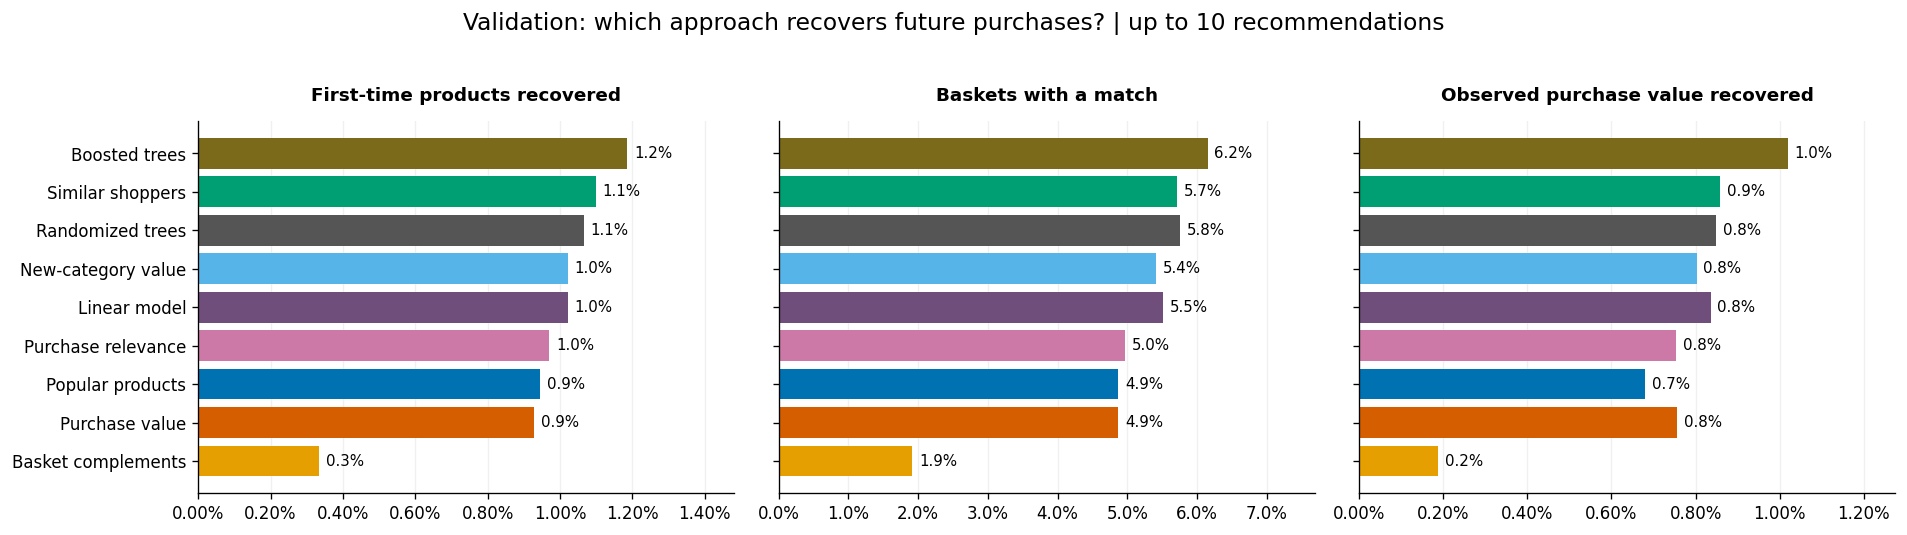

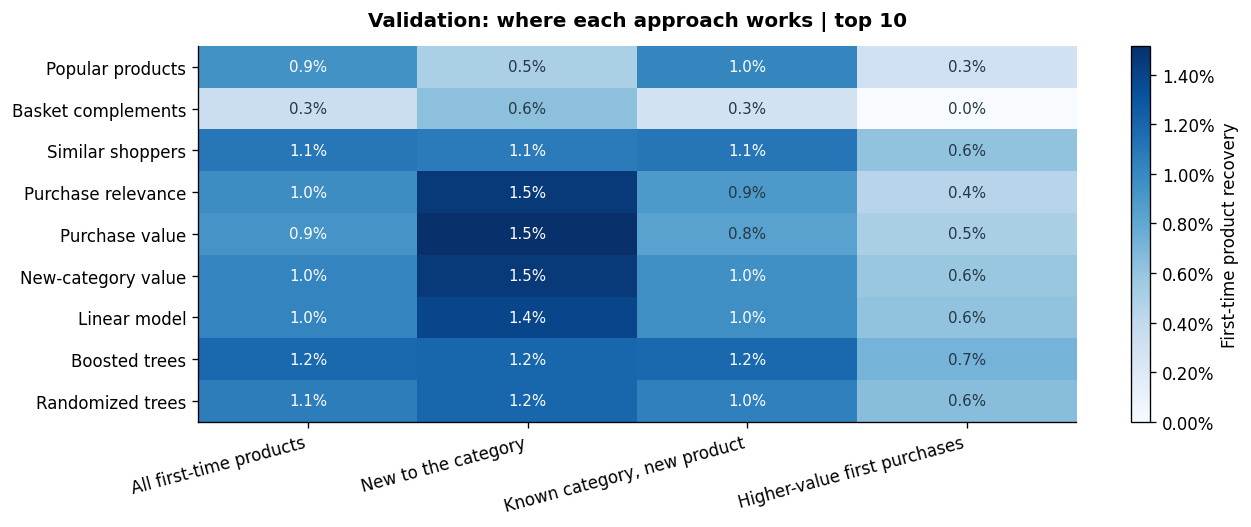

**Validation detail: top 10 recommendations**

,split,model,segment,k,target_products,hits,recall,basket_hit_rate,precision_on_returned,ndcg,recorded_sales_capture
0,Validation,Popular products,all novel SKUs,10,11641,110,0.94%,4.87%,0.44%,0.005510,0.68%
1,Validation,Basket complements,all novel SKUs,10,11641,39,0.34%,1.92%,0.16%,0.001905,0.19%
2,Validation,Similar shoppers,all novel SKUs,10,11641,128,1.10%,5.71%,0.51%,0.006672,0.86%
3,Validation,Purchase relevance,all novel SKUs,10,11641,113,0.97%,4.97%,0.45%,0.005967,0.75%
4,Validation,Purchase value,all novel SKUs,10,11641,108,0.93%,4.87%,0.43%,0.005481,0.76%
5,Validation,New-category value,all novel SKUs,10,11641,119,1.02%,5.41%,0.48%,0.006668,0.80%
6,Validation,Linear model,all novel SKUs,10,11641,119,1.02%,5.51%,0.48%,0.005852,0.84%
7,Validation,Boosted trees,all novel SKUs,10,11641,138,1.19%,6.15%,0.55%,0.007519,1.02%
8,Validation,Randomized trees,all novel SKUs,10,11641,124,1.07%,5.76%,0.50%,0.006315,0.85%


In [23]:
validation_models = {name:spec["score_col"] for name, spec in MODEL_REGISTRY.items()}
validation_raw_metrics = pl.concat([
    metric_table(valid_ctx, valid_scored_base, name, col, "Validation")
    for name, col in validation_models.items()], how="vertical")
assert set(validation_raw_metrics["model"].unique()) == set(MODEL_REGISTRY)
plot_model_scoreboard(validation_raw_metrics, "Validation: which approach recovers future purchases?")
plot_segment_heatmap(validation_raw_metrics, "Validation: where each approach works")
show(validation_raw_metrics.filter((pl.col("segment") == "all novel SKUs") & (pl.col("k") == 10)),
     "Validation detail: top 10 recommendations", pct_cols=("recall", "basket_hit_rate", "precision_on_returned", "recorded_sales_capture"), max_rows=50)


### Select the business tradeoff

The blend search maximizes `0.65 × all first-purchase value recovery + 0.35 × new-category value recovery`, subject to a minimum new-category recommendation share. These are observational value-recovery objectives, not margin or causal lift.

Only this family of main-model blends is tuned here; challenger comparisons are benchmarks and do not automatically replace a blend component. The exploration constraint can make all blends infeasible, in which case the notebook stops rather than silently relaxing the requirement. Any policy change requires a fresh validation run.

In [24]:
blend_rows = []
truth_valid = target_truth(valid_ctx)

total_sales = float(truth_valid["truth_sales"].sum())
novel_truth = truth_valid.filter(pl.col("new_category"))
novel_truth_sales = float(novel_truth["truth_sales"].sum())

for blend in BLENDS:
    label = (
        f"P{blend[0]:.2f}_V{blend[1]:.2f}_NV{blend[2]:.2f}_"
        f"C{blend[3]:.2f}_E{blend[4]:.2f}"
    )

    trial = add_blend_score(valid_scored_base, blend)
    trial_slate = mmr_rerank(trial, "blend_score", k=20)
    top10 = trial_slate.filter(pl.col("slate_rank") <= 10)

    hit = truth_valid.join(
        top10.select("target_basket_id", "product_id"),
        on=["target_basket_id", "product_id"],
        how="inner",
    )

    rec_new_category_rate = (
        float(top10["new_category_flag"].mean())
        if top10.height
        else 0.0
    )

    novel_hits = hit.join(
        novel_truth.select("target_basket_id", "product_id"),
        on=["target_basket_id", "product_id"],
        how="inner",
    )

    novel_value_capture = (
        float(novel_hits["truth_sales"].sum())
        / max(novel_truth_sales, 1e-9)
        if novel_truth.height
        else 0.0
    )

    recorded_sales_capture = (
        float(hit["truth_sales"].sum()) / total_sales
        if total_sales
        else 0.0
    )

    # Primary validation utility = value capture + novel-value capture.
    # The exploration constraint prevents a degenerate value/popularity blend.
    selection_utility = (
        0.65 * recorded_sales_capture
        + 0.35 * novel_value_capture
    )

    if rec_new_category_rate < MIN_NEW_CATEGORY_RECO_RATE:
        selection_utility = -np.inf

    blend_rows.append({
        "blend": label,
        "propensity_weight": blend[0],
        "value_weight": blend[1],
        "novel_value_weight": blend[2],
        "complement_weight": blend[3],
        "exploration_weight": blend[4],
        "new_category_reco_rate": rec_new_category_rate,
        "recorded_sales_capture_at_10": recorded_sales_capture,
        "novel_category_sales_capture_at_10": novel_value_capture,
        "selection_utility": selection_utility,
    })

blend_table = pl.DataFrame(blend_rows).sort(
    "selection_utility",
    descending=True,
)

show(
    blend_table,
    "Validation-only blend search (MMR included)",
    pct_cols=(
        "new_category_reco_rate",
        "recorded_sales_capture_at_10",
        "novel_category_sales_capture_at_10",
    ),
)

selected_candidate = blend_table.filter(
    pl.col("selection_utility").is_finite()
)

assert selected_candidate.height > 0, (
    "No validation blend satisfied the exploration constraint. "
    "Lower MIN_NEW_CATEGORY_RECO_RATE slightly rather than silently "
    "selecting a popularity-only blend."
)

# Select by column name so adding or reordering report columns cannot
# silently change the chosen weights.
selected = selected_candidate.row(0, named=True)

SELECTED_BLEND = (
    float(selected["propensity_weight"]),
    float(selected["value_weight"]),
    float(selected["novel_value_weight"]),
    float(selected["complement_weight"]),
    float(selected["exploration_weight"]),
)

display(Markdown(
    f"**Selected validation blend:** "
    f"propensity={SELECTED_BLEND[0]:.2f}, "
    f"value={SELECTED_BLEND[1]:.2f}, "
    f"novel-value={SELECTED_BLEND[2]:.2f}, "
    f"complement={SELECTED_BLEND[3]:.2f}, "
    f"exploration={SELECTED_BLEND[4]:.2f}. "
    "The final test is frozen from this point onward."
))
validation_scored = add_blend_score(valid_scored_base, SELECTED_BLEND)
validation_slate = mmr_rerank(validation_scored, "blend_score", k=max(TOP_K))


**Validation-only blend search (MMR included)**

,blend,propensity_weight,value_weight,novel_value_weight,complement_weight,exploration_weight,new_category_reco_rate,recorded_sales_capture_at_10,novel_category_sales_capture_at_10,selection_utility
0,P0.40_V0.25_NV0.15_C0.10_E0.10,0.400000,0.250000,0.150000,0.100000,0.100000,42.12%,0.64%,0.96%,0.007504
1,P0.45_V0.30_NV0.10_C0.10_E0.05,0.450000,0.300000,0.100000,0.100000,0.050000,31.35%,0.72%,0.79%,0.007427
2,P0.45_V0.25_NV0.15_C0.10_E0.05,0.450000,0.250000,0.150000,0.100000,0.050000,31.14%,0.68%,0.75%,0.007004
3,P0.50_V0.25_NV0.10_C0.10_E0.05,0.500000,0.250000,0.100000,0.100000,0.050000,31.23%,0.64%,0.76%,0.006855
4,P0.55_V0.20_NV0.10_C0.10_E0.05,0.550000,0.200000,0.100000,0.100000,0.050000,31.16%,0.65%,0.73%,0.006755
5,P0.40_V0.20_NV0.15_C0.15_E0.10,0.400000,0.200000,0.150000,0.150000,0.100000,35.54%,0.61%,0.78%,0.006671


**Selected validation blend:** propensity=0.40, value=0.25, novel-value=0.15, complement=0.10, exploration=0.10. The final test is frozen from this point onward.

### Make the selected tradeoff visible

The frontier shows feasible blends, the exploration threshold and the validation-selected operating point. The category-mix chart shows how the same workflow changes candidate composition when it forms a final list.

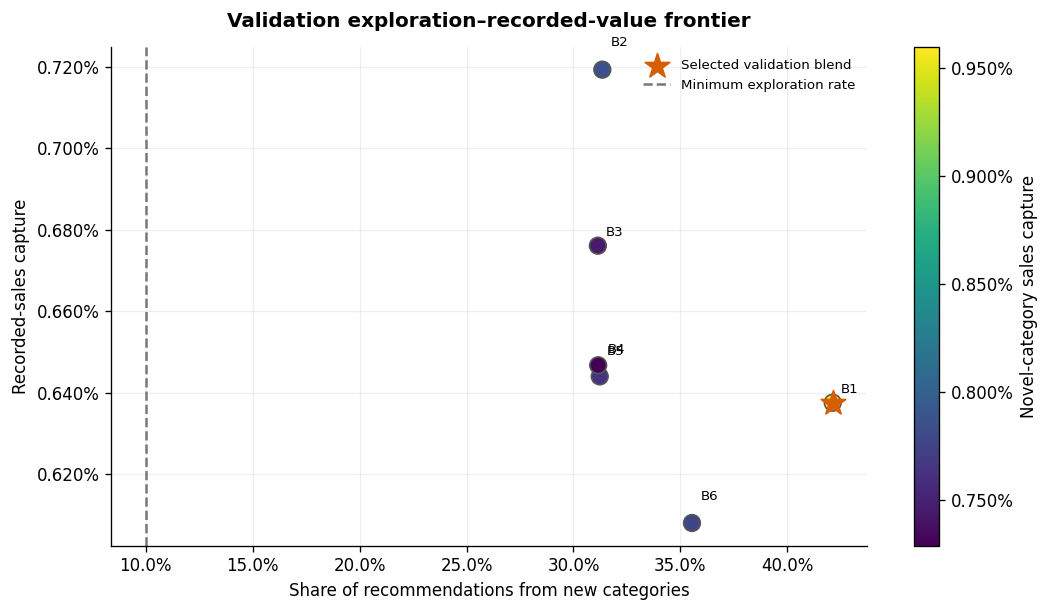

**Frontier blend key**

,blend,recommended_new_category_rate,recorded_sales_capture,novel_category_sales_capture_at_10,selection_utility,point
0,P0.40_V0.25_NV0.15_C0.10_E0.10,42.12%,0.64%,0.96%,0.007504,B1
1,P0.45_V0.30_NV0.10_C0.10_E0.05,31.35%,0.72%,0.79%,0.007427,B2
2,P0.45_V0.25_NV0.15_C0.10_E0.05,31.14%,0.68%,0.75%,0.007004,B3
3,P0.50_V0.25_NV0.10_C0.10_E0.05,31.23%,0.64%,0.76%,0.006855,B4
4,P0.55_V0.20_NV0.10_C0.10_E0.05,31.16%,0.65%,0.73%,0.006755,B5
5,P0.40_V0.20_NV0.15_C0.15_E0.10,35.54%,0.61%,0.78%,0.006671,B6


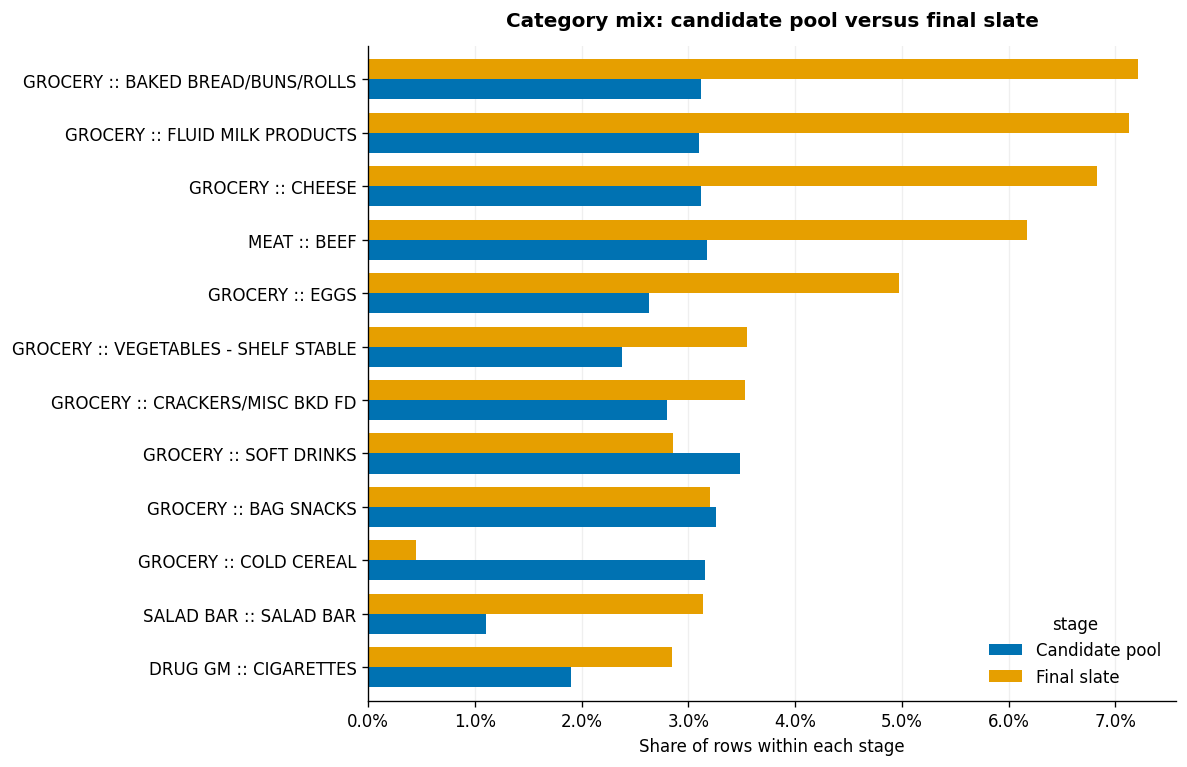

In [25]:
# Reuse cell 16's validation results; the first 10 greedy MMR selections
# are unchanged whether the function is asked for a slate of 10 or 20.
frontier = blend_table.select(
    "blend",
    pl.col("new_category_reco_rate").alias("recommended_new_category_rate"),
    pl.col("recorded_sales_capture_at_10").alias("recorded_sales_capture"),
    "novel_category_sales_capture_at_10",
    "selection_utility",
).to_pandas()

fig, ax = plt.subplots(figsize=(9, 5.2))
feasible = np.isfinite(frontier["selection_utility"].to_numpy())
points = ax.scatter(
    frontier["recommended_new_category_rate"], frontier["recorded_sales_capture"],
    c=frontier["novel_category_sales_capture_at_10"], cmap="viridis",
    s=np.where(feasible, 100, 45), edgecolors="#555555",
)
for index, row in frontier.iterrows():
    ax.annotate(f"B{index + 1}",
                (row["recommended_new_category_rate"], row["recorded_sales_capture"]),
                xytext=(5, 6 + 8 * (index % 2)), textcoords="offset points", fontsize=8)
chosen = frontier[frontier["blend"] == selected.get("blend", "")] if isinstance(selected, dict) else frontier.iloc[0:0]
ax.scatter(chosen["recommended_new_category_rate"], chosen["recorded_sales_capture"],
           s=240, marker="*", color="#D55E00", label="Selected validation blend", zorder=5)
ax.axvline(MIN_NEW_CATEGORY_RECO_RATE, color="#777777", linestyle="--",
           label="Minimum exploration rate")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
fig.colorbar(points, ax=ax, label="Novel-category sales capture", format=PercentFormatter(1))
ax.set(title="Validation exploration–recorded-value frontier",
       xlabel="Share of recommendations from new categories", ylabel="Recorded-sales capture")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
show(frontier.assign(point=[f"B{i + 1}" for i in range(len(frontier))]),
     "Frontier blend key",
     pct_cols=("recommended_new_category_rate", "recorded_sales_capture",
               "novel_category_sales_capture_at_10"))

# Compare equal-denominator category shares rather than raw row counts.
category_mix_frames = []
for label, frame in [
    ("Candidate pool", valid_retrieved),
    ("Final slate", validation_slate.filter(pl.col("slate_rank") <= 10)),
]:
    counts = frame.group_by("category_id").len().to_pandas()
    counts["share"] = counts["len"] / max(frame.height, 1)
    counts["stage"] = label
    category_mix_frames.append(counts)

mix = pd.concat(category_mix_frames, ignore_index=True)
if not mix.empty:
    comparison_categories = (
        mix.groupby("category_id")["share"].max().nlargest(12).index
    )
    mix_wide = mix.pivot(index="category_id", columns="stage", values="share")
    mix_wide = mix_wide.reindex(comparison_categories).fillna(0).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 6.5))
    mix_wide.plot.barh(ax=ax, width=0.75)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.set(title="Category mix: candidate pool versus final slate",
           xlabel="Share of rows within each stage", ylabel="")
    ax.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    plt.show()


### Diagnose the candidate ceiling

Separate products never retrieved from products lost later in ranking or slate construction. These validation diagnostics help decide whether to improve candidate generation or scoring.

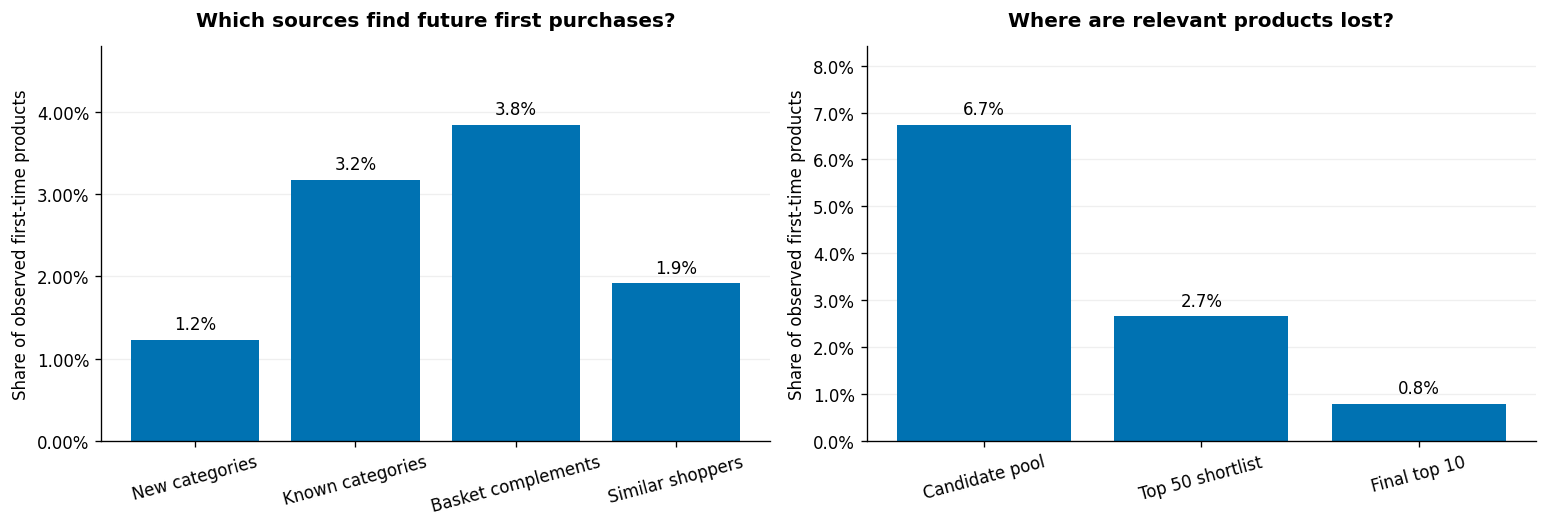

**Validation retrieval ceiling by category exposure**

,segment,observed_novel_products,retrieved_products,baskets_with_opportunity,candidate_product_recall
0,familiar category,10057,628,1914,6.24%
1,new category,1584,156,765,9.85%


In [26]:
# Candidate-generation failures and ranking failures need different fixes.
truth_valid = target_truth(valid_ctx)
key_columns = ["target_basket_id", "product_id"]
channel_names = {"channel_discovery":"New categories", "channel_familiar":"Known categories",
                 "channel_complement":"Basket complements", "channel_peer":"Similar shoppers"}
channel_hits = truth_valid.join(valid_retrieved.select(key_columns + list(channel_names)),
                               on=key_columns, how="left")
channel_values = [float(channel_hits[c].fill_null(0).sum())/max(truth_valid.height, 1) for c in channel_names]
shortlist = ranked_pool(validation_scored, "blend_score").filter(pl.col("rank") <= MMR_POOL_K)
stages = [valid_retrieved, shortlist, validation_slate.filter(pl.col("slate_rank") <= 10)]
stage_values = [truth_valid.join(frame.select(key_columns).unique(), on=key_columns, how="semi").height
                /max(truth_valid.height, 1) for frame in stages]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, labels, values, title in [
    (axes[0], list(channel_names.values()), channel_values, "Which sources find future first purchases?"),
    (axes[1], ["Candidate pool", f"Top {MMR_POOL_K} shortlist", "Final top 10"], stage_values, "Where are relevant products lost?")]:
    bars = ax.bar(labels, values, color="#0072B2")
    ax.bar_label(bars, labels=[f"{v:.1%}" for v in values], padding=4)
    ax.set_ylim(0, max(max(values)*1.25, 0.01)); ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set(title=title, ylabel="Share of observed first-time products")
    ax.tick_params(axis="x", labelrotation=15); ax.grid(axis="y", alpha=0.2)
plt.tight_layout(); plt.show()
explain("Retrieval sets the ceiling: a model cannot recommend a product missing from its candidate pool. "
        "Source bars overlap and must not be added. The right-hand bars show survival through the selected workflow.")

candidate_volume = valid_ctx.select("target_basket_id").join(
    valid_retrieved.group_by("target_basket_id").len(), on="target_basket_id", how="left"
).with_columns(pl.col("len").fill_null(0))
show(retrieval_funnel(valid_ctx, valid_retrieved), "Validation retrieval ceiling by category exposure",
     pct_cols=("candidate_product_recall",))
explain(f"Validation baskets with no candidates: {candidate_volume.filter(pl.col('len') == 0).height:,} "
        f"of {valid_ctx.height:,}. Median candidates: {candidate_volume['len'].median():.0f}.")


## 7. Held-out business report

**Question:** does the frozen workflow recover future first-time purchases?

The blend weights are now frozen. Score the test pool once, evaluate every active scoring approach, and include both the combined score and its diversified slate. These two entries form a controlled before/after comparison of the diversity stage—not two independently trained models.

The compact scoreboard answers “how much?”, the small-multiple curves answer “what if the list gets longer?”, and the heatmap answers “for which opportunities?”. Every active model appears in all three views.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with fea

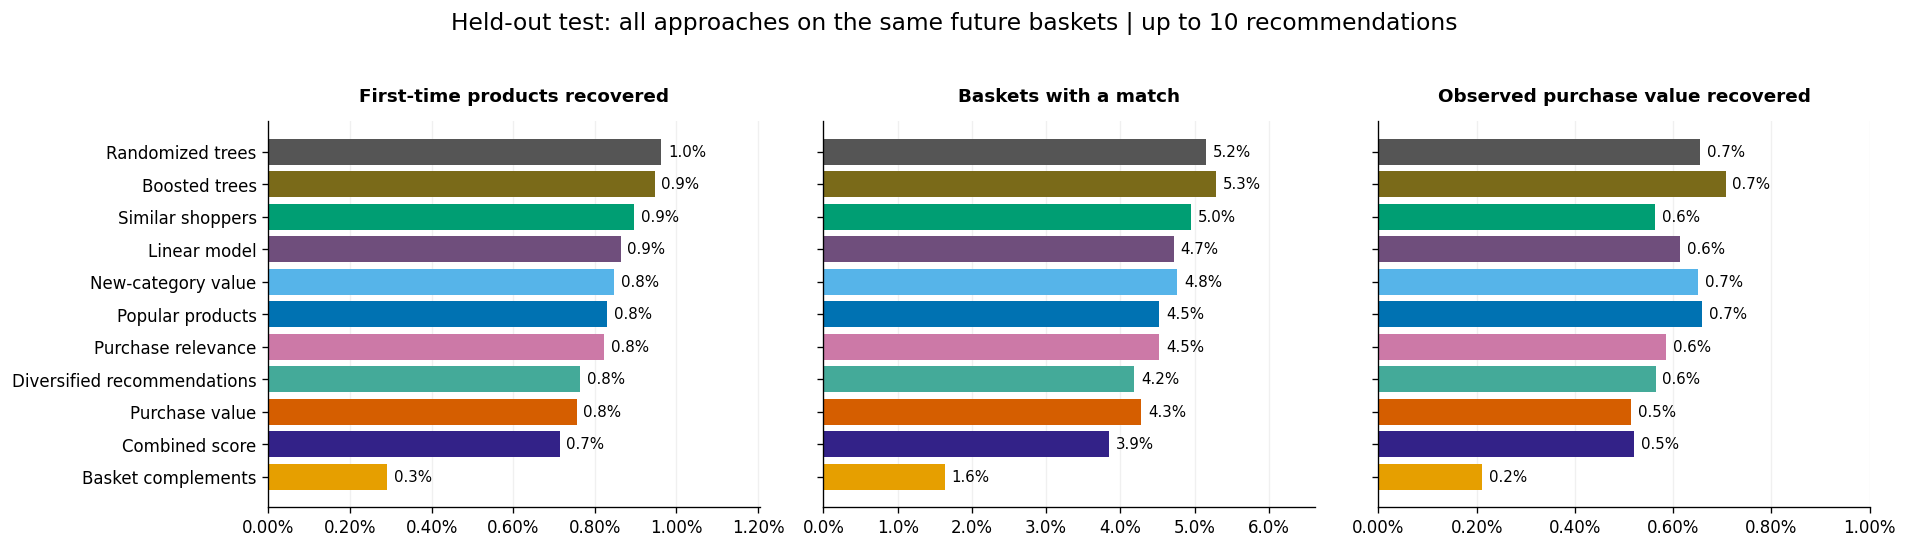

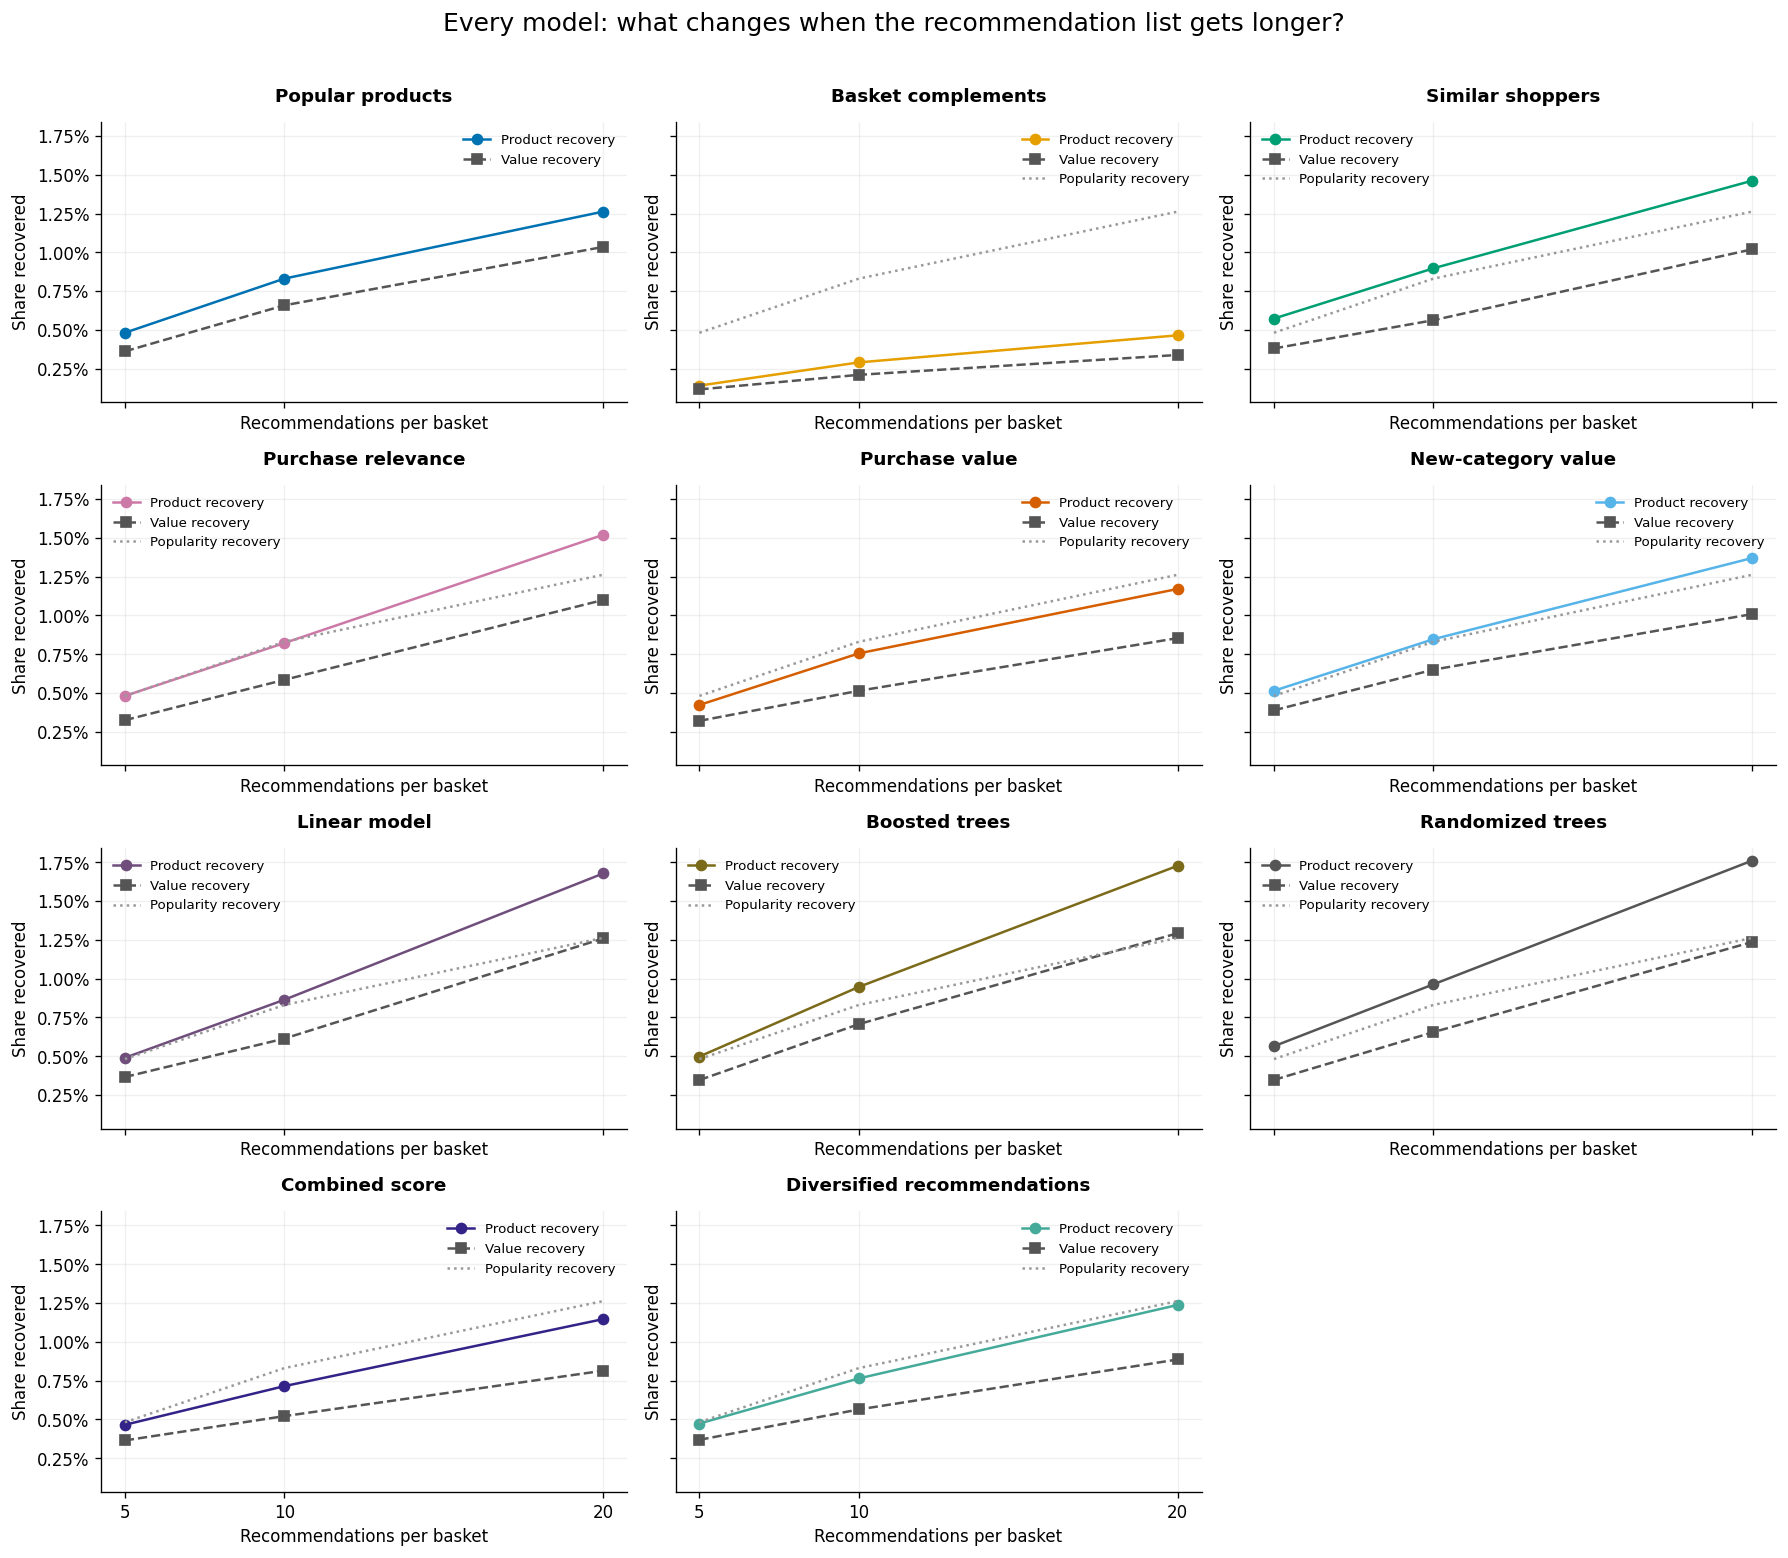

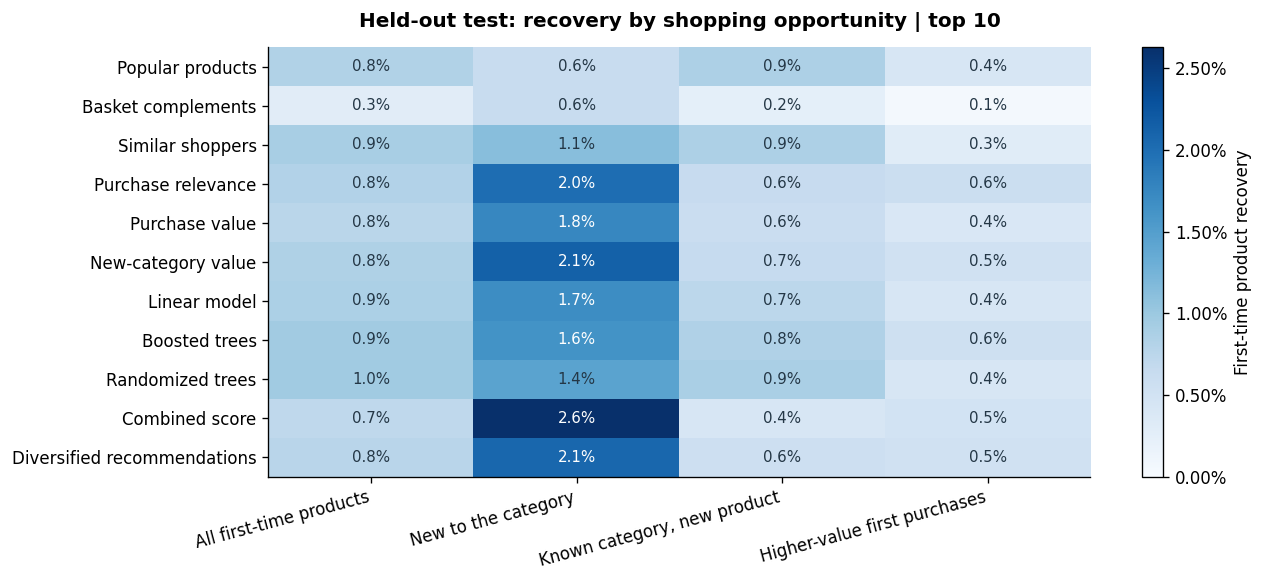

**Held-out detail: top 10 recommendations**

,split,model,segment,k,target_products,hits,recall,basket_hit_rate,precision_on_returned,ndcg,recorded_sales_capture
0,Held-out test,Popular products,all novel SKUs,10,12040,100,0.83%,4.53%,0.40%,0.005588,0.66%
1,Held-out test,Basket complements,all novel SKUs,10,12040,35,0.29%,1.64%,0.14%,0.001203,0.21%
2,Held-out test,Similar shoppers,all novel SKUs,10,12040,108,0.90%,4.96%,0.43%,0.007619,0.56%
3,Held-out test,Purchase relevance,all novel SKUs,10,12040,99,0.82%,4.53%,0.40%,0.005153,0.59%
4,Held-out test,Purchase value,all novel SKUs,10,12040,91,0.76%,4.29%,0.36%,0.005014,0.51%
5,Held-out test,New-category value,all novel SKUs,10,12040,102,0.85%,4.77%,0.41%,0.005457,0.65%
6,Held-out test,Linear model,all novel SKUs,10,12040,104,0.86%,4.72%,0.42%,0.004938,0.61%
7,Held-out test,Boosted trees,all novel SKUs,10,12040,114,0.95%,5.30%,0.46%,0.005413,0.71%
8,Held-out test,Randomized trees,all novel SKUs,10,12040,116,0.96%,5.15%,0.46%,0.005730,0.66%
9,Held-out test,Combined score,all novel SKUs,10,12040,86,0.71%,3.85%,0.34%,0.004684,0.52%


In [27]:
# No test scoring takes place until validation choices have been frozen.
validation_scored = add_blend_score(valid_scored_base, SELECTED_BLEND)
test_scored_base = score_pool(test_pool)
test_scored = add_blend_score(test_scored_base, SELECTED_BLEND)
validation_slate = mmr_rerank(validation_scored, "blend_score", k=max(TOP_K))
test_slate = mmr_rerank(test_scored, "blend_score", k=max(TOP_K))
register_model("Combined score", "blend_score", "The validation-selected weighted score, before diversity controls.", family="Combined")
register_model("Diversified recommendations", None, "The same combined score with category limits and a repetition penalty.", family="Final slate", is_slate=True)

validation_final_reports = [metric_table(valid_ctx, validation_scored, "Combined score", "blend_score"),
    metric_table(valid_ctx, validation_slate, "Diversified recommendations", is_slate=True)]
validation_metrics_all = pl.concat([validation_raw_metrics] + validation_final_reports, how="vertical")
test_metrics_all = pl.concat([
    metric_table(test_ctx, test_slate if spec["is_slate"] else test_scored,
                 name, spec["score_col"], "Held-out test", is_slate=spec["is_slate"])
    for name, spec in MODEL_REGISTRY.items()], how="vertical")
assert set(test_metrics_all["model"].unique()) == set(MODEL_REGISTRY)
plot_model_scoreboard(test_metrics_all, "Held-out test: all approaches on the same future baskets")
plot_model_curves(test_metrics_all)
plot_segment_heatmap(test_metrics_all, "Held-out test: recovery by shopping opportunity")
show(test_metrics_all.filter((pl.col("segment") == "all novel SKUs") & (pl.col("k") == 10)),
     "Held-out detail: top 10 recommendations", pct_cols=("recall", "basket_hit_rate", "precision_on_returned", "recorded_sales_capture"), max_rows=50)


### Final workflow scorecards

These cards report the validation-selected slate, not whichever model happens to lead the test leaderboard. The difference from popularity is descriptive, not a significance test or causal lift estimate.

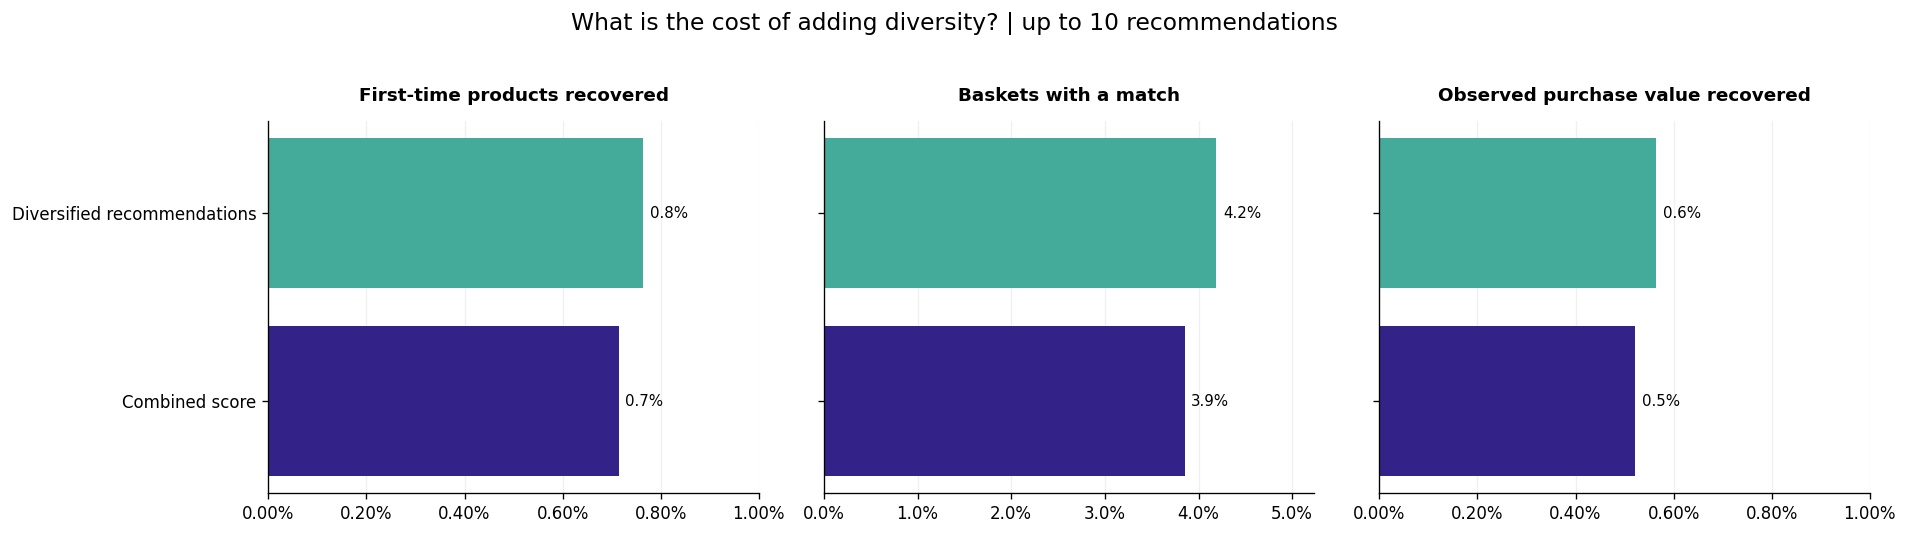

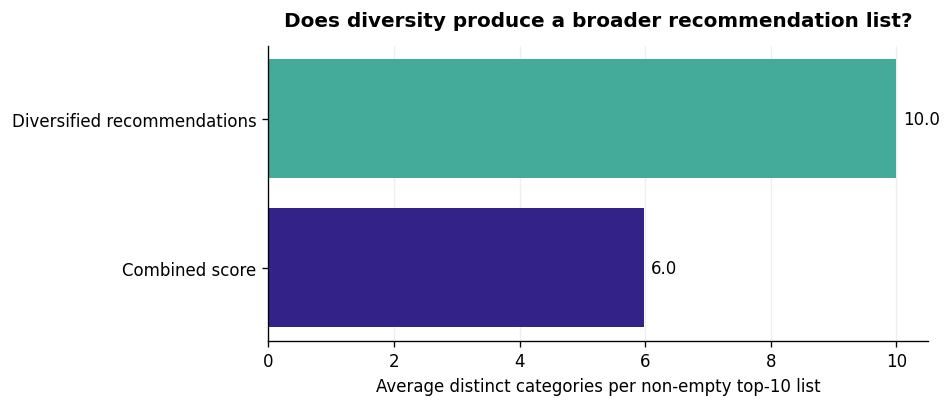

In [28]:
top10 = test_metrics_all.filter((pl.col("segment") == "all novel SKUs") & (pl.col("k") == 10))
final = top10.filter(pl.col("model") == "Diversified recommendations").row(0, named=True)
baseline = top10.filter(pl.col("model") == "Popular products").row(0, named=True)
diversity = recommendation_diversity_metrics(test_slate, snap_test["sku"].height, k=10).row(0, named=True)
kpi_cards([("First-time products recovered", f"{final['recall']:.1%}",
            f"{(final['recall'] - baseline['recall'])*100:+.1f} percentage points vs popularity"),
           ("Baskets with a match", f"{final['basket_hit_rate']:.1%}", "Among baskets with first-time purchases"),
           ("Observed value recovered", f"{final['recorded_sales_capture']:.1%}", "Historical value, not incremental revenue"),
           ("New-category recommendations", f"{diversity['new_category_rate']:.1%}", "Mean share per non-empty slate")])
explain(f"The validation-selected diversified slate recovered {final['hits']:,} of {final['target_products']:,} "
        f"observed first-time products across {test_ctx.height:,} held-out baskets. "
        "It is the preselected workflow, not necessarily the best test model; do not select a new winner using this test.")

ablation = top10.filter(pl.col("model").is_in(["Combined score", "Diversified recommendations"]))
plot_model_scoreboard(ablation, "What is the cost of adding diversity?")
mix_rows = []
for name, frame in [("Combined score", ranked_pool(test_scored, "blend_score").filter(pl.col("rank") <= 10)),
                    ("Diversified recommendations", test_slate.filter(pl.col("slate_rank") <= 10))]:
    per = frame.group_by("target_basket_id").agg(pl.col("category_id").n_unique().alias("categories"))
    mix_rows.append({"model":name, "average_categories":float(per["categories"].mean()) if per.height else 0})
fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh([r["model"] for r in mix_rows], [r["average_categories"] for r in mix_rows],
               color=[model_color(r["model"]) for r in mix_rows])
ax.bar_label(bars, fmt="%.1f", padding=4)
ax.set(title="Does diversity produce a broader recommendation list?", xlabel="Average distinct categories per non-empty top-10 list")
ax.grid(axis="x", alpha=0.2); plt.tight_layout(); plt.show()
explain("The two approaches use identical blend weights and candidates. Only the diversity stage differs. "
        "The category cap can return fewer than ten items; the coverage checks below report this explicitly.")


### How stable are the estimates?

Household-cluster bootstrap intervals preserve the dependence among a shopper's repeated baskets. They describe the final slate's offline sampling uncertainty; they do not compare models statistically or prove incremental sales.

**Final slate: 95% household-bootstrap intervals**

,metric,estimate,ci_low_95,ci_high_95
0,First-time product recovery,0.76%,0.61%,0.94%
1,Observed value recovery,0.56%,0.41%,0.72%


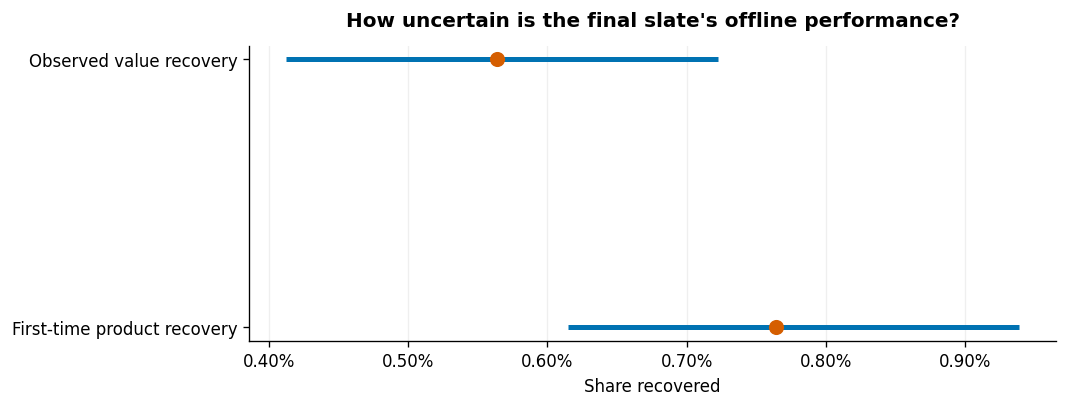

In [29]:
# Resample households so repeated visits from the same shopper stay together.
def household_bootstrap(contexts, slate, k=10, n_boot=400):
    truth = target_truth(contexts)
    top = slate.filter(pl.col("slate_rank") <= k)
    totals = truth.group_by("target_basket_id").agg(pl.len().alias("n_truth"),
        pl.col("truth_sales").sum().alias("truth_sales"))
    matches = truth.join(top.select("target_basket_id", "product_id"),
        on=["target_basket_id", "product_id"], how="inner").group_by("target_basket_id").agg(
        pl.len().alias("hits"), pl.col("truth_sales").sum().alias("hit_sales"))
    b = contexts.select("target_basket_id", "household_key").join(totals,
        on="target_basket_id", how="left").join(matches, on="target_basket_id", how="left")
    b = b.with_columns(pl.col(c).fill_null(0) for c in ["n_truth", "truth_sales", "hits", "hit_sales"])
    households = b.group_by("household_key").agg(
        pl.col(c).sum() for c in ["n_truth", "truth_sales", "hits", "hit_sales"])
    arrays = households.select("n_truth", "truth_sales", "hits", "hit_sales").to_numpy().astype(float)
    if len(arrays) < 2 or arrays[:, 0].sum() == 0:
        explain("Too few households or first-purchase observations for uncertainty estimation.")
        return pd.DataFrame(columns=["metric", "estimate", "ci_low_95", "ci_high_95"])
    rng = np.random.default_rng(SEED)
    samples = np.empty((n_boot, 2))
    for run in range(n_boot):
        total = arrays[rng.integers(0, len(arrays), len(arrays))].sum(axis=0)
        samples[run] = [total[2]/max(total[0], 1), total[3]/max(total[1], 1e-9)]
    total = arrays.sum(axis=0)
    return pd.DataFrame({"metric":["First-time product recovery", "Observed value recovery"],
        "estimate":[total[2]/max(total[0], 1), total[3]/max(total[1], 1e-9)],
        "ci_low_95":np.quantile(samples, 0.025, axis=0),
        "ci_high_95":np.quantile(samples, 0.975, axis=0)})

bootstrap_test = household_bootstrap(test_ctx, test_slate)
show(bootstrap_test, "Final slate: 95% household-bootstrap intervals",
     pct_cols=("estimate", "ci_low_95", "ci_high_95"))
if not bootstrap_test.empty:
    fig, ax = plt.subplots(figsize=(9, 3.5))
    y = np.arange(len(bootstrap_test))
    ax.hlines(y, bootstrap_test["ci_low_95"], bootstrap_test["ci_high_95"], linewidth=3, color="#0072B2")
    ax.scatter(bootstrap_test["estimate"], y, s=65, color="#D55E00", zorder=3)
    ax.set_yticks(y, bootstrap_test["metric"])
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.set(title="How uncertain is the final slate's offline performance?", xlabel="Share recovered")
    ax.grid(axis="x", alpha=0.2); plt.tight_layout(); plt.show()
    explain("The point is the observed test result; the line is a 95% percentile interval. "
            "Resampling keeps all visits from one household together. These intervals describe "
            "sampling uncertainty for the final slate, not causal lift or evidence that it beats another model.")


### Where did opportunities fail?

Each observed first-time product is assigned to exactly one outcome: a top-10 match, a retrieval miss or a ranking/slate miss. Counts include truth products that never became candidates.

**Held-out failure stage by novelty segment**

,failure_stage,new_category,truth_products,truth_sales
0,ranking/slate miss,False,609,1584.430000
1,ranking/slate miss,True,144,343.700000
2,retrieval miss,False,9776,29138.900000
3,retrieval miss,True,1419,5680.450000
4,top-10 hit,False,59,144.190000
5,top-10 hit,True,33,64.310000


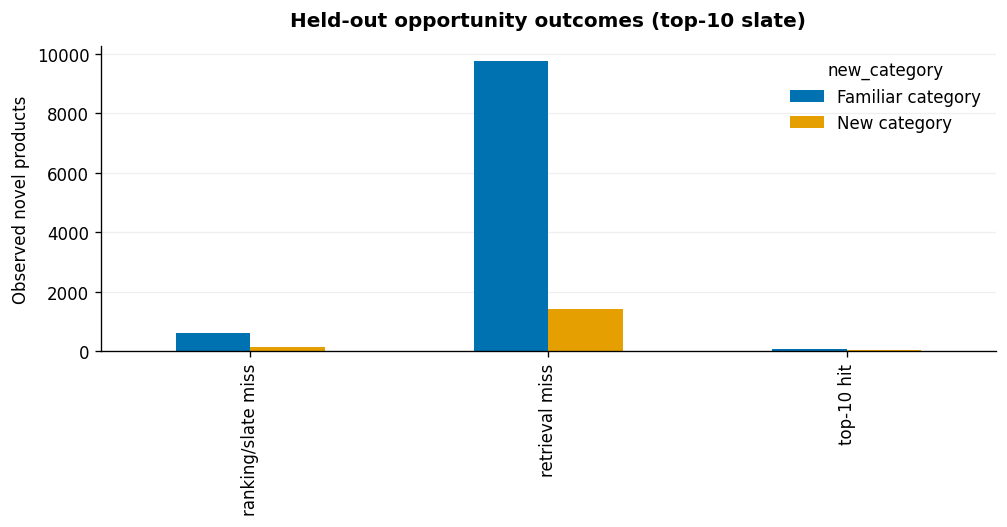

**Interpretation rule:** if retrieval misses dominate, invest in retrieval expansion; if ranking misses dominate after adequate candidate recall, invest in ranking features/modeling. This prevents over-tuning a ranker to compensate for missing candidates.

In [30]:
truth_test = target_truth(test_ctx)
retrieved_test = test_retrieved.select("target_basket_id", "product_id").unique()

failure = (
    truth_test
    .join(
        retrieved_test.with_columns(pl.lit(1).alias("retrieved")),
        on=["target_basket_id", "product_id"],
        how="left",
    )
    .join(
        test_slate.filter(pl.col("slate_rank") <= 10)
        .select("target_basket_id", "product_id").unique()
        .with_columns(pl.lit(1).alias("recommended")),
        on=["target_basket_id", "product_id"],
        how="left",
    )
    .with_columns(
        pl.col("retrieved").fill_null(0),
        pl.col("recommended").fill_null(0),
    )
    .with_columns(
        pl.when(pl.col("recommended") == 1)
        .then(pl.lit("top-10 hit"))
        .when(pl.col("retrieved") == 0)
        .then(pl.lit("retrieval miss"))
        .otherwise(pl.lit("ranking/slate miss"))
        .alias("failure_stage")
    )
)

failure_summary = (
    failure.group_by("failure_stage", "new_category")
    .agg(
        pl.len().alias("truth_products"),
        pl.col("truth_sales").sum().alias("truth_sales"),
    )
    .sort("failure_stage", "new_category")
)

show(failure_summary, "Held-out failure stage by novelty segment")

fig, ax = plt.subplots(figsize=(8.5, 4.5))
pivot = (
    failure_summary.to_pandas()
    .assign(new_category=lambda d: d["new_category"].map({True: "New category", False: "Familiar category"}))
    .pivot(index="failure_stage", columns="new_category", values="truth_products")
    .fillna(0)
)
pivot.plot(kind="bar", ax=ax)
ax.set_title("Held-out opportunity outcomes (top-10 slate)")
ax.set_ylabel("Observed novel products")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

display(Markdown(
    "**Interpretation rule:** if retrieval misses dominate, invest in retrieval expansion; "
    "if ranking misses dominate after adequate candidate recall, invest in ranking features/modeling. "
    "This prevents over-tuning a ranker to compensate for missing candidates."
))


## 8. Explain the recommendations

**Question:** what signals influence the models, and why did this product appear?

Score-group diagnostics cover every scoring model, including baselines and the combined score. Model-specific signal charts are available when the estimator exposes importance or coefficients. The diversified slate has no separate candidate score; its behavior is explained by the diversity ablation and local penalty-aware list.

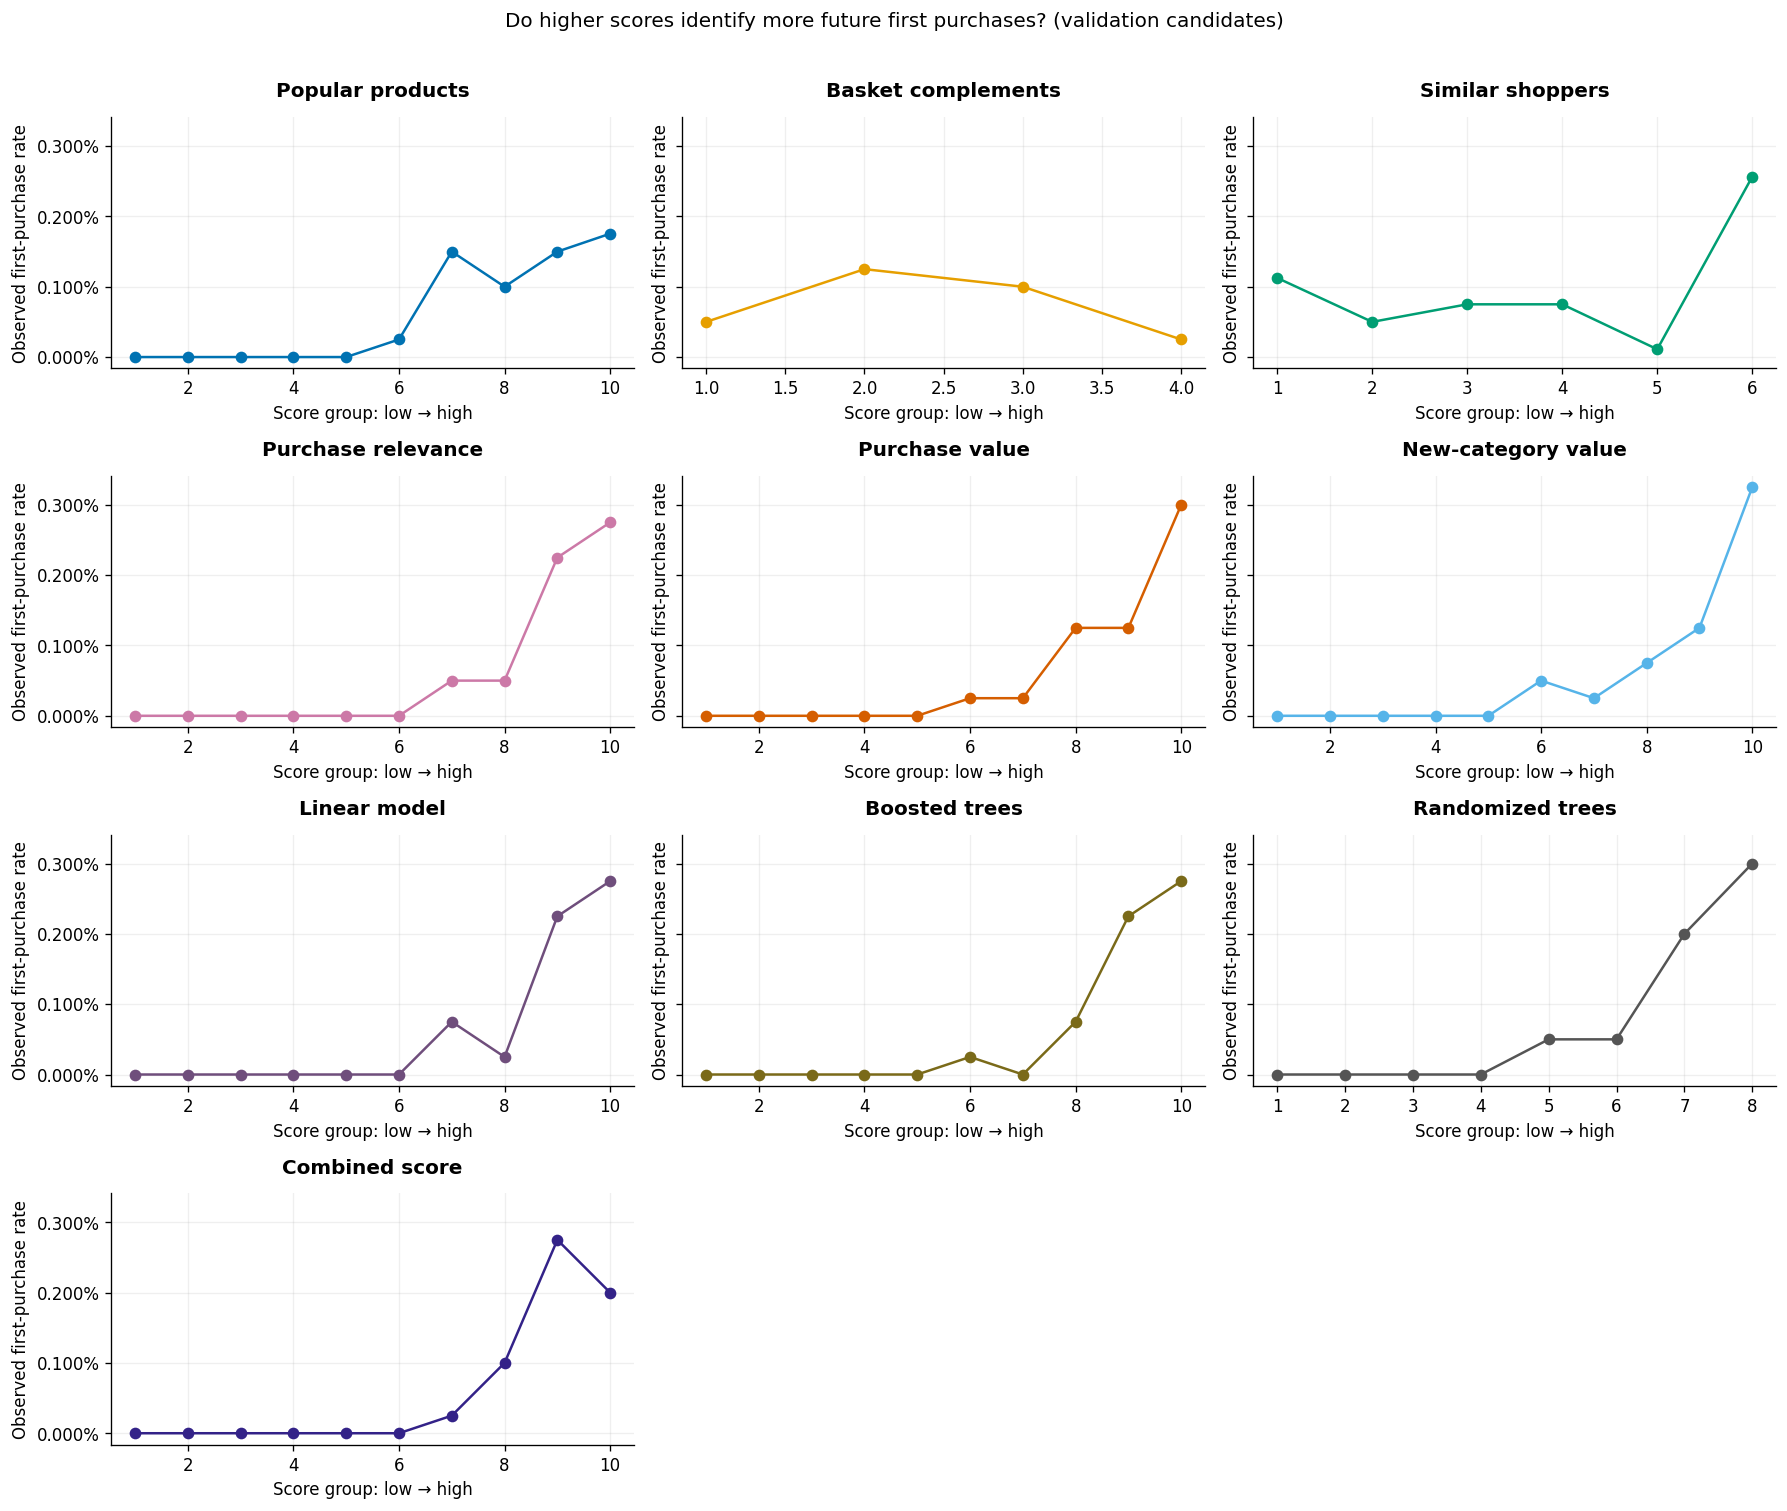

In [31]:
scored_specs = {n:s for n,s in MODEL_REGISTRY.items() if not s["is_slate"]}
sample = valid_scored_base.sample(n=min(40000, valid_scored_base.height), seed=SEED)
sample = add_blend_score(sample, SELECTED_BLEND).to_pandas()
if len(sample) >= 20:
    names = list(scored_specs)
    rows = math.ceil(len(names)/3)
    fig, axes = plt.subplots(rows, 3, figsize=(15, 3.2*rows), squeeze=False, sharey=True)
    for ax, name in zip(axes.flat, names):
        column = scored_specs[name]["score_col"]
        data = sample[[column, "label"]].copy()
        groups = pd.qcut(data[column], q=10, labels=False, duplicates="drop")
        if groups.notna().sum() == 0:
            ax.text(0.5, 0.5, "All scores are equal", transform=ax.transAxes, ha="center")
        else:
            data["group"] = groups + 1
            observed = data.groupby("group")["label"].mean()
            ax.plot(observed.index, observed.values, "o-", color=model_color(name))
        ax.set(title=name, xlabel="Score group: low → high", ylabel="Observed first-purchase rate")
        ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.grid(alpha=0.2)
    for ax in list(axes.flat)[len(names):]:
        ax.set_visible(False)
    fig.suptitle("Do higher scores identify more future first purchases? (validation candidates)")
    fig.tight_layout(rect=(0,0,1,0.97)); plt.show()
    explain("A rising curve indicates useful ordering, not probability calibration. "
            "These are full validation candidates, not the sampled training negatives. "
            "Tied scores stay together, so some models have fewer than ten groups. "
            "The diversified slate is a selection rule, not a separate candidate-scoring model.")


### Global signals and local blend

Feature importance is model-specific, not comparable across algorithms. The local decomposition below shows the exact weighted components of the combined score **before** the diversity penalty. Optional SHAP focuses on the purchase-relevance LightGBM model only.

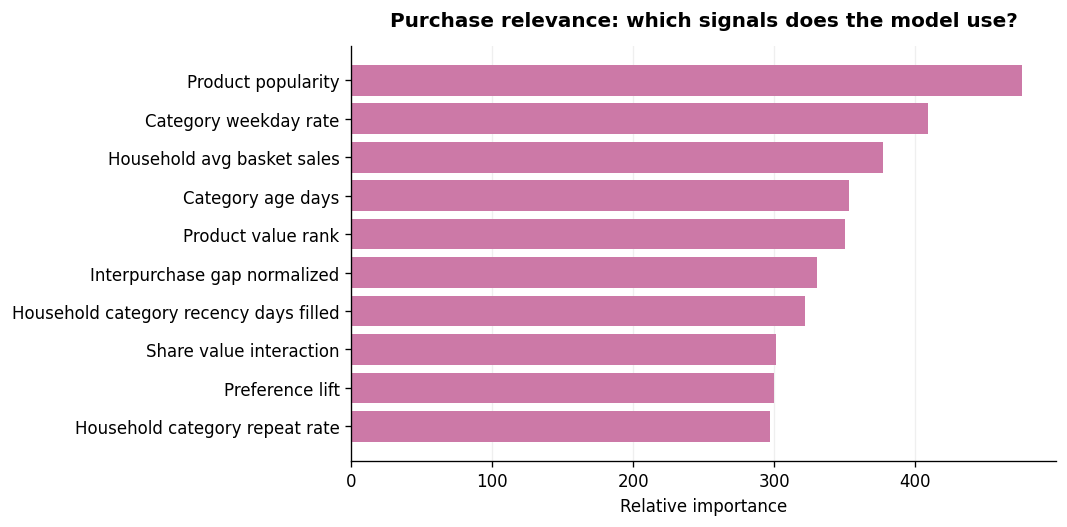

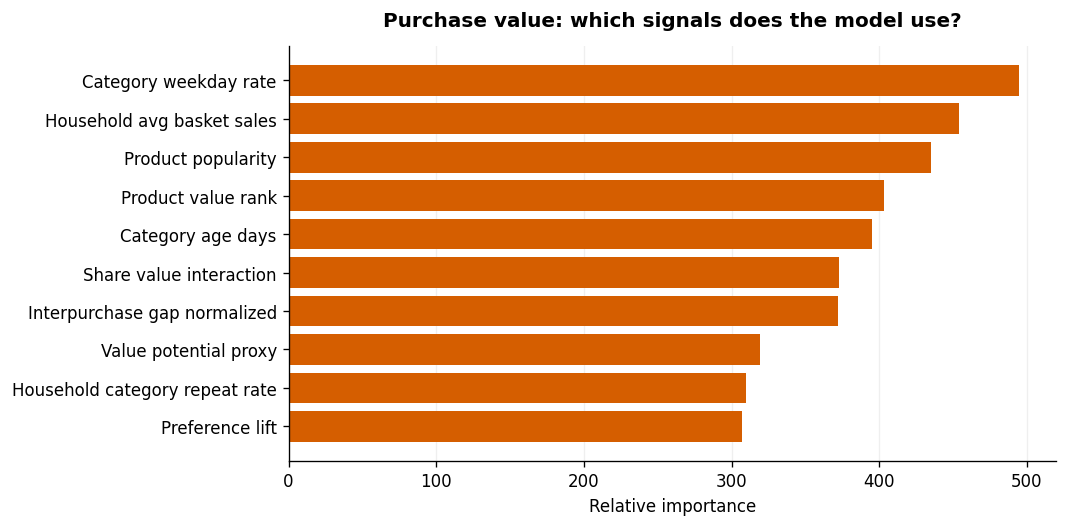

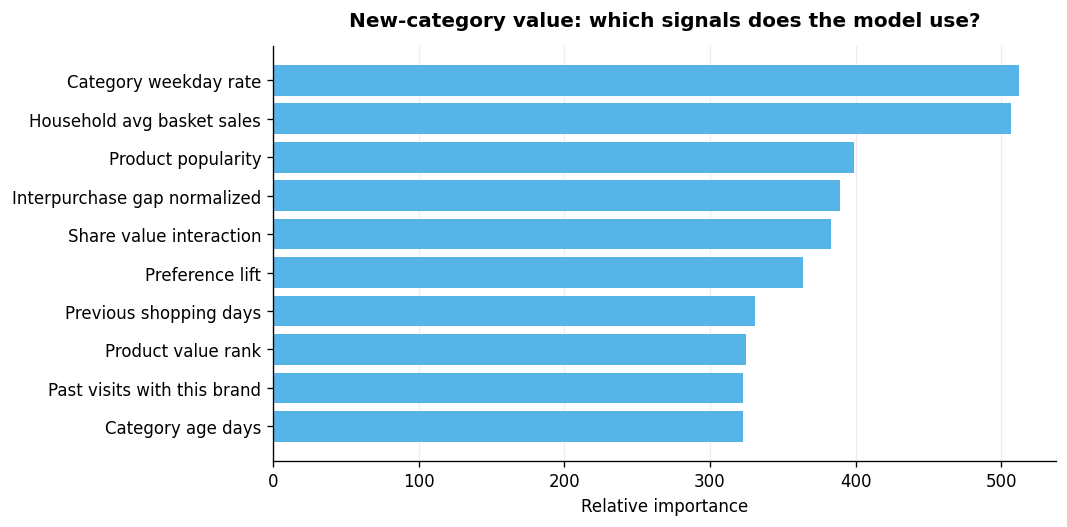

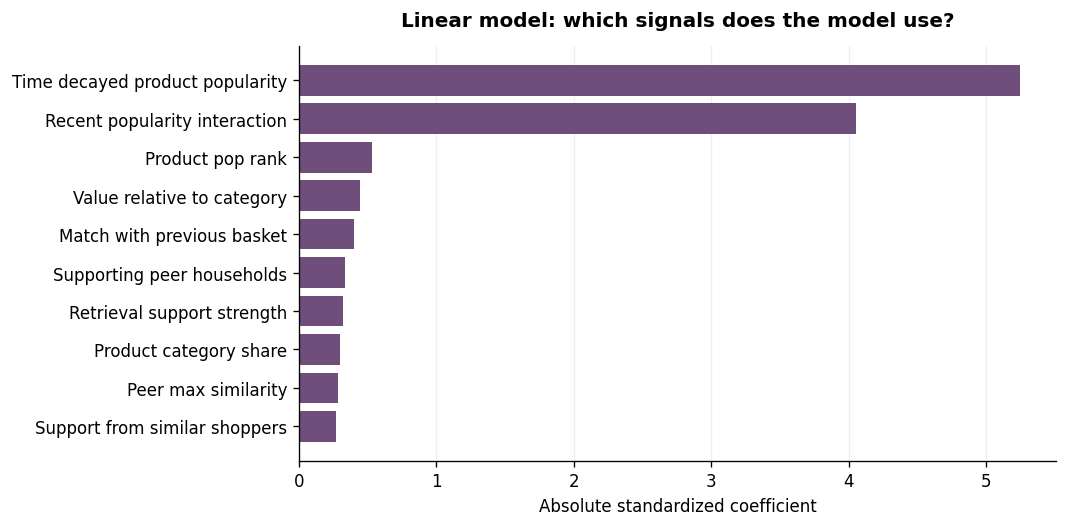

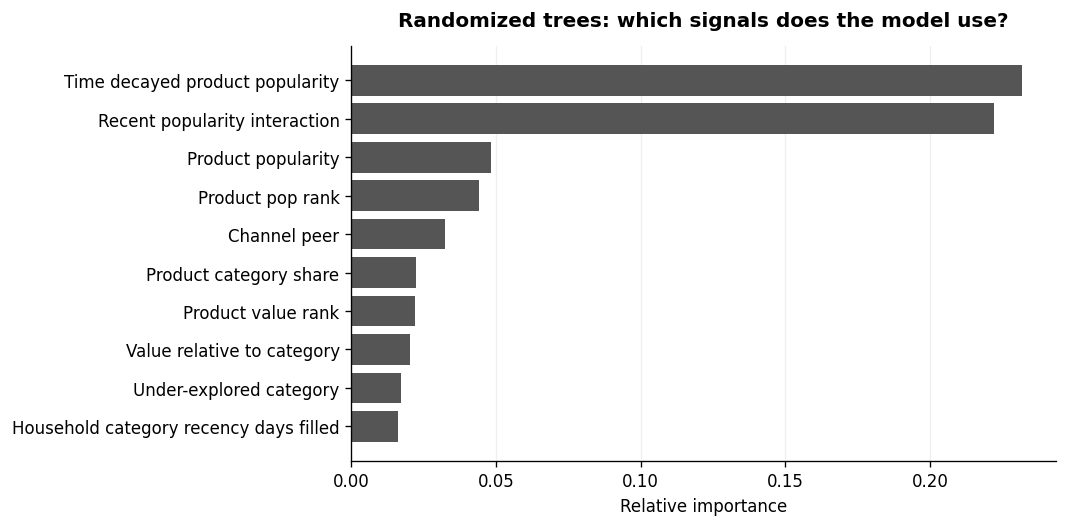

Optional SHAP is disabled, unavailable, or unsupported for the active backend. Set RECO_RUN_SHAP=1 before setup to enable it with LightGBM. The local blend decomposition below is always available.

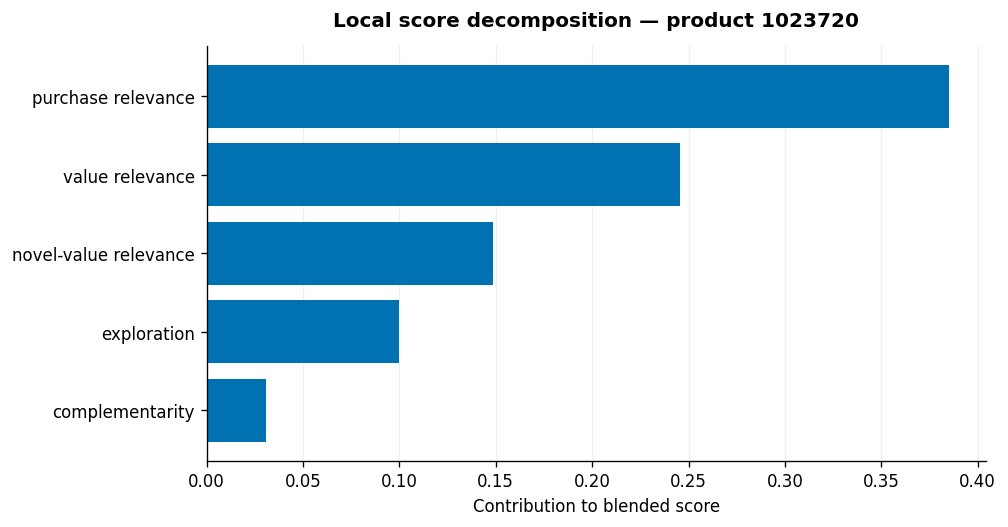

**Local recommendation evidence**

,field,value
0,product_id,1023720
1,category,PRODUCE :: STONE FRUIT
2,brand,NATIONAL
3,new_category,1
4,propensity_pct,0.962343
5,value_pct,0.983264
6,novel_value_pct,0.991632
7,complement_pct,0.309623
8,unexpectedness,1.000000
9,relative_unit_value,0.993677


In [32]:
def feature_label(name):
    labels = {"sku_baskets":"Product popularity", "new_category_flag":"Category new to shopper",
        "peer_score":"Support from similar shoppers", "complement_score":"Match with previous basket",
        "unexpectedness":"Under-explored category", "relative_unit_value":"Value relative to category",
        "history_baskets":"Previous shopping days", "days_since_previous":"Days since previous visit",
        "hh_category_baskets":"Past visits in this category", "hh_brand_baskets":"Past visits with this brand"}
    return labels.get(name, name.replace("hh_", "Household ").replace("sku_", "Product ").replace("_", " ").capitalize())

for name, spec in MODEL_REGISTRY.items():
    estimator = spec["estimator"]
    if estimator is None:
        continue
    importance_values = None
    label = "Relative importance"
    if getattr(estimator, "feature_importances_", None) is not None:
        importance_values = np.asarray(estimator.feature_importances_, dtype=float)
    elif HAS_CATBOOST and isinstance(estimator, CatBoostRanker):
        # YetiRank importance requires the original grouped training Pool.
        from catboost import Pool
        importance_values = estimator.get_feature_importance(Pool(X_train, y_purchase,
            group_id=np.repeat(np.arange(len(group_sizes)), group_sizes)), type="PredictionValuesChange")
    elif hasattr(estimator, "named_steps"):
        linear = estimator.steps[-1][1]
        if hasattr(linear, "coef_"):
            importance_values = np.abs(linear.coef_[0])
            label = "Absolute standardized coefficient"
    if importance_values is None:
        explain(f"{name}: built-in feature importance is not exposed by this estimator. "
                "Its performance, segments and score-ordering diagnostics still appear above.")
        continue
    importance = pd.DataFrame({"feature":[feature_label(f) for f in FEATURES], "importance":importance_values})
    top = importance.nlargest(10, "importance").sort_values("importance")
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.barh(top["feature"], top["importance"], color=model_color(name))
    ax.set(title=f"{name}: which signals does the model use?", xlabel=label)
    ax.grid(axis="x", alpha=0.2); plt.tight_layout(); plt.show()
explain("Importance describes the fitted model, not why a shopper purchased or the effect of a recommendation. "
        "Importance scales differ by algorithm and should not be compared across models.")

if RUN_SHAP and HAS_SHAP and HAS_LIGHTGBM and isinstance(propensity_ranker, LGBMRanker):
    explain_sample = (
        valid_scored_base
        .sample(n=min(1500, valid_scored_base.height), seed=SEED)
        .select(FEATURES)
        .to_pandas()
        .astype("float32")
    )

    explainer = shap.TreeExplainer(propensity_ranker)
    shap_values = explainer(explain_sample)

    values = (
        shap_values.values
        if hasattr(shap_values, "values")
        else shap_values
    )

    shap.summary_plot(
        values,
        explain_sample,
        max_display=20,
        show=False,
    )
    plt.title("SHAP — purchase-ranker contribution to score")
    plt.tight_layout()
    plt.show()
else:
    display(Markdown(
        "Optional SHAP is disabled, unavailable, or unsupported for the active backend. "
        "Set RECO_RUN_SHAP=1 before setup to enable it with LightGBM. "
        "The local blend decomposition below is always available."
    ))

# Local decomposition on the frozen validation slate.
demo = (
    validation_slate
    .filter(pl.col("slate_rank") <= 10)
    .sort("target_basket_id", "slate_rank")
    .head(1)
)

if demo.height:
    r = demo.to_dicts()[0]
    blend = SELECTED_BLEND

    contributions = pd.DataFrame({
        "component": [
            "purchase relevance",
            "value relevance",
            "novel-value relevance",
            "complementarity",
            "exploration",
        ],
        "weighted_contribution": [
            blend[0] * float(r.get("propensity_pct", 0)),
            blend[1] * float(r.get("value_pct", 0)),
            blend[2] * float(r.get("novel_value_pct", 0)),
            blend[3] * float(r.get("complement_pct", 0)),
            blend[4] * float(r.get("unexpectedness", 0)),
        ],
    }).sort_values("weighted_contribution")

    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    ax.barh(
        contributions["component"],
        contributions["weighted_contribution"],
    )
    ax.set_title(f"Local score decomposition — product {r['product_id']}")
    ax.set_xlabel("Contribution to blended score")
    ax.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    plt.show()

    show(
        pd.DataFrame({
            "field": [
                "product_id",
                "category",
                "brand",
                "new_category",
                "propensity_pct",
                "value_pct",
                "novel_value_pct",
                "complement_pct",
                "unexpectedness",
                "relative_unit_value",
                "supporting_peer_households",
                "n_supporting_anchors",
                "n_retrieval_channels",
            ],
            "value": [
                r.get("product_id"),
                r.get("category_id"),
                r.get("brand"),
                r.get("new_category_flag"),
                r.get("propensity_pct"),
                r.get("value_pct"),
                r.get("novel_value_pct"),
                r.get("complement_pct"),
                r.get("unexpectedness"),
                r.get("relative_unit_value"),
                r.get("supporting_peer_households"),
                r.get("n_supporting_anchors"),
                r.get("n_retrieval_channels"),
            ],
        }),
        "Local recommendation evidence",
    )


### One shopper's recommendation list

A fixed-seed context illustrates the full diversified slate. Product labels, category status and deterministic reason codes provide evidence in everyday language. The selected example is not optimized to show a successful hit.

**Example held-out recommendation slate — context 42009121956**

,slate_rank,product_id,department,commodity_desc,brand,category_id,new_category_flag,relative_unit_value,complement_score,peer_score,unexpectedness,n_retrieval_channels,final_mmr_score,reason
0,1,6533765,KIOSK-GAS,FUEL,PRIVATE,KIOSK-GAS :: FUEL,1,1.461568,0.000000,0.000000,1.000000,2,0.928151,new category for household; under-indexed category
1,2,981521,GROCERY,BLEACH,NATIONAL,GROCERY :: BLEACH,1,0.616589,0.000000,0.000000,1.000000,2,0.905252,new category for household; under-indexed category
2,3,849843,GROCERY,BAKED BREAD/BUNS/ROLLS,PRIVATE,GROCERY :: BAKED BREAD/BUNS/ROLLS,0,0.539598,28.401189,8.187065,0.318855,4,0.881461,complements the previous basket; supported by similar households
3,4,866227,PASTRY,BREAKFAST SWEETS,NATIONAL,PASTRY :: BREAKFAST SWEETS,0,0.162811,0.000000,7.730199,0.814711,1,0.877895,supported by similar households; under-indexed category
4,5,938700,GROCERY,VEGETABLES - SHELF STABLE,PRIVATE,GROCERY :: VEGETABLES - SHELF STABLE,0,0.629229,14.632253,0.000000,0.340534,2,0.870236,complements the previous basket
5,6,844179,MEAT,BEEF,NATIONAL,MEAT :: BEEF,0,0.753259,18.868533,7.832344,0.325376,3,0.869823,complements the previous basket; supported by similar households
6,7,1002558,GROCERY,CHEESE,PRIVATE,GROCERY :: CHEESE,0,0.668365,25.688333,0.000000,0.324314,3,0.867511,complements the previous basket
7,8,1075368,DRUG GM,CIGARETTES,NATIONAL,DRUG GM :: CIGARETTES,1,0.945508,0.000000,0.000000,1.000000,2,0.848945,new category for household; under-indexed category
8,9,861272,GROCERY,EGGS,PRIVATE,GROCERY :: EGGS,0,0.417761,15.496656,0.000000,0.335030,2,0.842532,complements the previous basket
9,10,8203834,SEAFOOD,SEAFOOD-FRESH,NATIONAL,SEAFOOD :: SEAFOOD-FRESH,1,1.195260,0.000000,0.000000,1.000000,2,0.839702,new category for household; under-indexed category


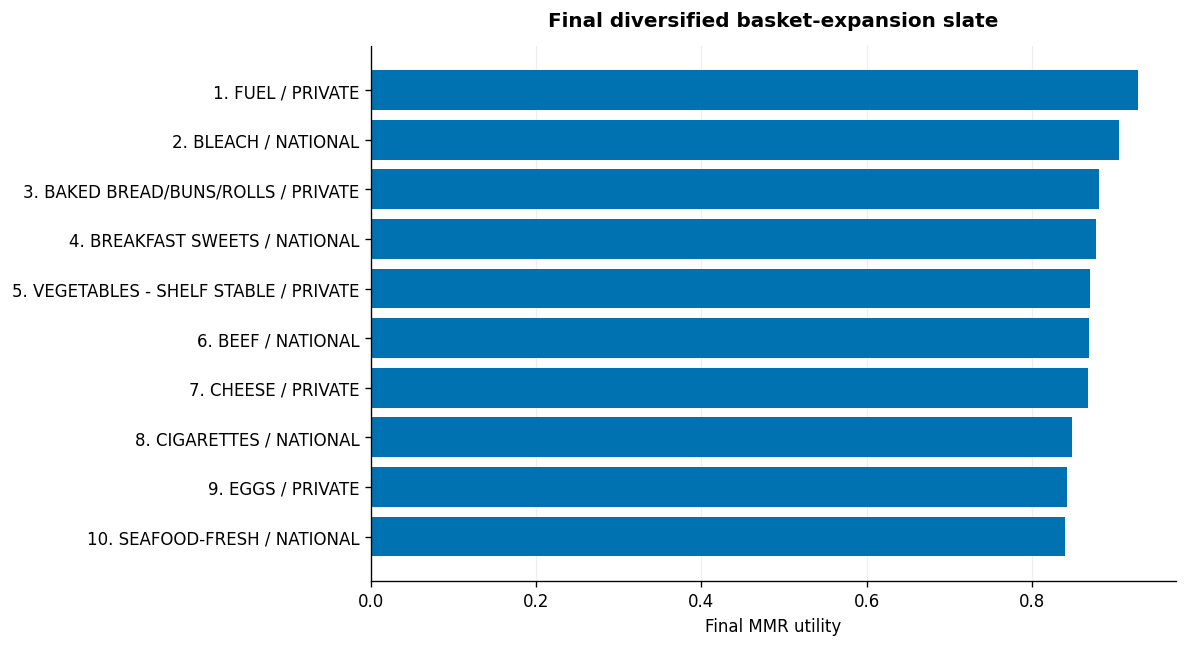

In [33]:
def reason_text(row):
    reasons = []

    if row.get("new_category_flag", 0) == 1:
        reasons.append("new category for household")

    if float(row.get("complement_score", 0) or 0) > 0.05:
        reasons.append("complements the previous basket")

    if float(row.get("peer_score", 0) or 0) > 0.05:
        reasons.append("supported by similar households")

    if float(row.get("unexpectedness", 0) or 0) > 0.45:
        reasons.append("under-indexed category")

    if float(row.get("relative_unit_value", 1.0) or 1.0) > 1.20:
        reasons.append("above-category-median value")

    if not reasons:
        reasons.append("strong combined relevance/value score")

    return "; ".join(reasons[:2])

if test_slate.height == 0:
    display(Markdown("No held-out slate is available for a recommendation example."))
else:
    demo_id = int(
        test_slate["target_basket_id"].unique().sort().sample(n=1, seed=SEED).item()
    )

    demo_slate = (
        test_slate
        .filter(
            (pl.col("target_basket_id") == demo_id)
            & (pl.col("slate_rank") <= 10)
        )
        .sort("slate_rank")
        .with_columns(
            pl.struct([
                "new_category_flag",
                "complement_score",
                "peer_score",
                "unexpectedness",
                "relative_unit_value",
            ]).map_elements(
                reason_text,
                return_dtype=pl.String,
            ).alias("reason")
        )
    )

    show(
        demo_slate.select(
            "slate_rank",
            "product_id",
            "department",
            "commodity_desc",
            "brand",
            "category_id",
            "new_category_flag",
            "relative_unit_value",
            "complement_score",
            "peer_score",
            "unexpectedness",
            "n_retrieval_channels",
            "final_mmr_score",
            "reason",
        ),
        f"Example held-out recommendation slate — context {demo_id}",
    )

    fig, ax = plt.subplots(figsize=(10, 5.5))
    labels = [
        f"{int(r['slate_rank'])}. {r['commodity_desc']} / {r['brand']}"
        for r in demo_slate.to_dicts()
    ]
    vals = demo_slate["final_mmr_score"].to_list()
    ax.barh(labels[::-1], vals[::-1])
    ax.set_title("Final diversified basket-expansion slate")
    ax.set_xlabel("Final MMR utility")
    ax.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    plt.show()
    explain("This example is selected with a fixed seed, not because it performed well. "
            "Reason codes describe observed supporting signals; they are not causal explanations. "
            "Final utility includes diversity penalties and is not a purchase probability.")


## 9. Coverage and deployment safeguards

**Question:** is the run complete, coherent and ready for an experiment?

Assertions check unique candidates, exclusion of earlier purchases, consistent novelty flags, finite scores, valid metric ranges, slate category limits, and model-to-metric coverage. Zero and short recommendation lists are reported rather than hidden.

In [34]:
# These checks run after scoring and evaluation, without changing model selection.
for split_name, ctx, pool in [("train", train_ctx, train_pool), ("validation", valid_ctx, valid_pool), ("test", test_ctx, test_pool)]:
    keys = ["target_basket_id", "product_id"]
    assert pool.select(keys).unique().height == pool.height, f"Duplicate {split_name} candidates"
    historical_repeats = pool.select("target_basket_id", "household_key", "target_day", "product_id").join(
        first_item_day, on=["household_key", "product_id"], how="left").filter(pl.col("first_item_day") < pl.col("target_day"))
    assert historical_repeats.height == 0, f"Previously purchased products leaked into {split_name}"
    assert pool.filter((pl.col("new_category_flag") + pl.col("familiar_category_flag")) != 1).height == 0

assert not set(FEATURES) & {"label", "target_recorded_sales", "target_log_sales", "novel_value_label", "value_grade", "novel_value_grade"}
for name, spec in MODEL_REGISTRY.items():
    if not spec["is_slate"]:
        assert spec["score_col"] in test_scored.columns, f"Missing score for {name}"
        assert np.isfinite(test_scored[spec["score_col"]].to_numpy()).all()
    assert test_metrics_all.filter(pl.col("model") == name).height == len(TOP_K)*4
assert test_slate.select("target_basket_id", "product_id").unique().height == test_slate.height
assert test_slate.group_by("target_basket_id", "category_id").len().filter(pl.col("len") > MAX_PER_CATEGORY).height == 0
for metric in ["recall", "basket_hit_rate", "precision_on_returned", "ndcg", "recorded_sales_capture"]:
    values = test_metrics_all[metric].to_numpy()
    assert np.isfinite(values).all() and (values >= -1e-8).all() and (values <= 1+1e-8).all(), metric

returned = test_ctx.select("target_basket_id").join(
    test_slate.filter(pl.col("slate_rank") <= 10).group_by("target_basket_id").len(),
    on="target_basket_id", how="left").with_columns(pl.col("len").fill_null(0))
show(pl.DataFrame({"Check":["Active models in every test chart", "Baskets returning zero recommendations",
                           "Baskets returning fewer than ten", "Mean recommendations returned"],
                   "Value":[str(len(MODEL_REGISTRY)), str(returned.filter(pl.col("len") == 0).height),
                            str(returned.filter(pl.col("len") < 10).height), f"{returned['len'].mean():.2f}"]}),
     "Workflow and plot coverage checks")
explain("All workflow assertions passed for this run. Scoreboard, small-multiple curves and "
        "segment heatmaps use the same registry, so optional models cannot disappear from the plots.")


**Workflow and plot coverage checks**

,Check,Value
0,Active models in every test chart,11
1,Baskets returning zero recommendations,0
2,Baskets returning fewer than ten,0
3,Mean recommendations returned,10.00


### Production experiment boundary

### What this notebook establishes

It provides a structured offline test of:

- candidate recall;
- first-time SKU recovery;
- graded ranking quality;
- observed recorded-sales capture;
- exploration rate;
- category diversity;
- catalog coverage;
- uncertainty around held-out basket metrics.

### What it does not establish

A future purchase is not evidence that a recommendation caused the purchase. A shopper could have bought the item anyway.

### Production measurement

For a genuine basket-expansion program, log the **exact recommendation exposure** and randomize treatment.

At minimum log:

- household/context;
- timestamp;
- candidate set and rank;
- product/category/brand;
- price and promotion;
- stock/availability;
- treatment assignment;
- subsequent purchases;
- revenue and margin.

Then measure incremental:

**units, revenue, gross margin, basket size, category expansion, and attach rate.**

Once randomized exposure exists, uplift / causal ranking can replace observational value capture as the primary business objective.

### Assumptions and remaining work

- Product availability, live prices and promotions are not modeled. Add timestamped availability before serving recommendations.
- Historical novelty is observed-day novelty, with no within-day visit order and no pre-dataset lifetime history.
- Global snapshots are frozen within windows. Compare a more frequent refresh schedule using a new validation design, not by retuning on the current test.
- Sampled negatives and positive-basket-only training introduce selection bias. Use representative exposures and a separate calibration slice before interpreting scores as probabilities.
- The blend search does not tune every possible challenger combination. If a challenger becomes a blend component, retune on validation and reserve a fresh final test.
- Household bootstrap intervals do not account for every temporal shock; compare time-block robustness separately if operational conditions shift.
- Test results are descriptive. A randomized household-level treatment/control experiment is needed to measure incremental units, revenue or margin.

### Extending the notebook

To add a scoring model, fit it using `X_train` and the training-only targets, then call `register_model` **before scoring**. Supply a unique name, score column and description. Use `prediction="binary"` for a classifier or `prediction="ordinal"` for a grade classifier. The shared scoring, comparison and visual functions include it automatically.

Do not register a roadmap model unless it actually produces predictions. Sequence, embedding and causal models remain future extensions rather than decorative entries in the results.